# Aprendizaje Automático I

## Trabajo Práctico: Predicción de precios de casas

### Facultad de Ciencias Exactas, Ingeniería y Agrimensura (FCEIA) - Universidad Nacional de Rosario (UNR)

**Integrantes:** Gimbatti, Longo, Paredes

---

### Contenidos

1. Configuración del entorno
2. Carga e inspección estructural del dataset
3. Gestión de datos: nulos, duplicados y consistencia
4. División train / test
5. Imputación de los registros incompletos
6. Análisis descriptivo
7. Pruebas de normalidad
8. Correlaciones y colinealidad
9. Detección de outliers
10. Control de coherencia lógica
11. Efecto de la eliminación sobre el análisis exploratorio
12. Transformación logarítmica de variables asimétricas
13. Escalado robusto
14. Regresión lineal múltiple
15. Gradiente descendente
16. Métodos de regularización
17. Comparación de los modelos de la consigna 4
18. Optimización de hiperparámetros
19. Comparación final y elección del modelo
20. Conclusiones

---

## 1. Configuración del entorno

Importamos las librerías necesarias y fijamos una semilla (`RANDOM_STATE`) para que todos los resultados del notebook sean reproducibles.

In [1211]:
# CatBoost no forma parte del stack estándar, así que se instala explícitamente
!pip install -q catboost


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1212]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler
from sklearn.impute import KNNImputer
from catboost import CatBoostClassifier
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.pipeline import make_pipeline
from sklearn.metrics import root_mean_squared_error
from sklearn.linear_model import RidgeCV, LassoCV, ElasticNetCV
from sklearn import metrics

import warnings
warnings.filterwarnings('ignore')

# Semilla fija para que los resultados sean reproducibles
RANDOM_STATE = 42

# Contador para referenciar a los gráficos
N_FIG = 1

---

## 2. Carga e inspección estructural del dataset

El dataset `house-prices-tp.csv` contiene información de viviendas de Boston:

| Variable | Tipo | Descripción |
|----------|------|-------------|
| `CRIM` | Continua | Tasa de criminalidad per cápita por ciudad |
| `ZN` | Continua | Proporción de terreno residencial zonificado para lotes de más de 25.000 pies² |
| `INDUS` | Continua | Proporción de acres de negocios no minoristas por ciudad |
| `CHAS` | Cualitativa dicotómica | 1 si el tramo limita con el río Charles, 0 si no |
| `NOX` | Continua | Concentración de óxidos de nitrógeno (partes por 10 millones) |
| `RM` | Continua | Número promedio de habitaciones por vivienda |
| `AGE` | Continua | Proporción de viviendas ocupadas por sus propietarios construidas antes de 1940 |
| `DIS` | Continua | Distancia ponderada a cinco centros de empleo de Boston |
| `RAD` | Discreta | Índice de accesibilidad a las autopistas radiales |
| `TAX` | Continua | Tasa de impuesto a la propiedad por cada USD 10.000 |
| `PTRATIO` | Continua | Proporción alumno-maestro por ciudad |
| `B` | Continua | $1000(B_k - 0.63)^2$, donde $B_k$ es la proporción de población negra por ciudad |
| `LSTAT` | Continua | % de población de menor estatus socioeconómico |
| `MEDV` | Continua | Valor mediano de las viviendas, en miles de USD |

In [1213]:
# Carga del dataset
df = pd.read_csv("house-prices-tp.csv")

print(f'Dimensiones del dataset: {df.shape[0]} filas x {df.shape[1]} columnas')
df.head()

Dimensiones del dataset: 556 filas x 14 columnas


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.07151,0.0,4.49,0.0,0.449,6.121,56.8,3.7476,3.0,247.0,18.5,395.15,8.44,22.2
1,0.08265,0.0,13.92,0.0,0.437,6.127,18.4,5.5027,4.0,289.0,16.0,396.90,8.58,23.9
2,0.12816,12.5,6.07,0.0,0.409,5.885,33.0,6.4980,4.0,345.0,18.9,396.90,8.79,20.9
3,0.08873,21.0,5.64,0.0,0.439,5.963,45.7,6.8147,4.0,243.0,16.8,395.56,13.45,19.7
4,0.11432,0.0,8.56,0.0,0.520,6.781,71.3,2.8561,5.0,384.0,20.9,395.58,7.67,26.5


In [1214]:
# Vista de una muestra aleatoria de registros
display(df.sample(5, random_state=RANDOM_STATE))

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
457,0.10574,0.0,27.74,0.0,0.609,5.983,98.8,1.8681,4.0,711.0,20.1,390.11,18.07,13.6
167,9.59571,0.0,18.10,0.0,0.693,6.404,100.0,1.6390,24.0,666.0,20.2,376.11,20.31,12.1
55,2.81838,0.0,18.10,0.0,0.532,5.762,40.3,4.0983,24.0,666.0,20.2,392.92,10.42,21.8
245,0.09849,0.0,25.65,0.0,0.581,5.879,95.8,2.0063,2.0,188.0,19.1,379.38,17.58,18.8
70,0.02187,60.0,2.93,0.0,0.401,6.800,9.9,6.2196,1.0,265.0,15.6,393.37,5.03,31.1


In [1215]:
# Paneo general: tipos de datos y valores no nulos
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 556 entries, 0 to 555
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     533 non-null    float64
 1   ZN       534 non-null    float64
 2   INDUS    541 non-null    float64
 3   CHAS     533 non-null    float64
 4   NOX      532 non-null    float64
 5   RM       535 non-null    float64
 6   AGE      532 non-null    float64
 7   DIS      541 non-null    float64
 8   RAD      528 non-null    float64
 9   TAX      538 non-null    float64
 10  PTRATIO  528 non-null    float64
 11  B        534 non-null    float64
 12  LSTAT    534 non-null    float64
 13  MEDV     535 non-null    float64
dtypes: float64(14)
memory usage: 60.9 KB


In [1216]:
# Separación de variables por tipo
cols_numericas = df.select_dtypes(include=[np.number]).columns.tolist()
cols_categoricas = df.select_dtypes(include=['category', 'object']).columns.tolist()

print(f'Variables numéricas ({len(cols_numericas)}): {cols_numericas}')
print(f'Variables categóricas ({len(cols_categoricas)}): {cols_categoricas}')

Variables numéricas (14): ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV']
Variables categóricas (0): []


Las 14 columnas son numéricas (`float64`), así que no hace falta codificar variables categóricas. Hay que tener en cuenta que dos de ellas, aunque numéricas, no son continuas: `CHAS` es una variable binaria (dummy) y `RAD` es un índice que solo toma valores enteros.

---

## 3. Gestión de datos: nulos, duplicados y consistencia

### 3.1 Patrones de datos faltantes


Identificar el patrón es importante para decidir si conviene eliminar los registros o imputarlos.

In [1217]:
# Reporte de valores nulos por columna
nulos = df.isnull().sum()
pct_nulos = (nulos / len(df)) * 100

reporte_nulos = pd.DataFrame({
    'Nulos': nulos,
    'Porcentaje (%)': pct_nulos.round(2),
    'Tipo': df.dtypes
})

print('Reporte de Valores Nulos:')
print('=' * 50)
print(reporte_nulos)
print(f'\nTotal de celdas con nulos: {nulos.sum()} ({nulos.sum() / df.size * 100:.2f}% del dataset)')

Reporte de Valores Nulos:
         Nulos  Porcentaje (%)     Tipo
CRIM        23            4.14  float64
ZN          22            3.96  float64
INDUS       15            2.70  float64
CHAS        23            4.14  float64
NOX         24            4.32  float64
RM          21            3.78  float64
AGE         24            4.32  float64
DIS         15            2.70  float64
RAD         28            5.04  float64
TAX         18            3.24  float64
PTRATIO     28            5.04  float64
B           22            3.96  float64
LSTAT       22            3.96  float64
MEDV        21            3.78  float64

Total de celdas con nulos: 306 (3.93% del dataset)


Encontramos entre 15 y 28 observaciones con valores faltantes en cada una de las características, incluida la variable objetivo `MEDV` (21 faltantes). En total falta el 3,93% de las celdas.

Que falten datos en las 14 columnas, en cantidades parecidas, es poco habitual en datos reales: normalmente los faltantes tienen una causa y se concentran en algunas variables. Para entender mejor el patrón, contamos cuántos nulos tiene cada registro.

### 3.2 Distribución de los nulos por registro

In [1218]:
# Cantidad de registros según cuántos valores nulos tienen
# (índice = cantidad de nulos en el registro, valor = cantidad de registros)
display(df.isna().sum(axis=1).value_counts().sort_index())

0     506
1       5
2       3
3      11
4       3
5       3
6       2
7       5
8       4
9       4
10      1
11      3
12      2
13      3
14      1
Name: count, dtype: int64

**Observación:** 506 registros están completos, y los 306 valores faltantes se concentran en solo 50 registros, que tienen entre 1 y 14 nulos cada uno.

Si los faltantes fueran aleatorios (MCAR), con un 3,93% de celdas faltantes esperaríamos muchos registros con 1 solo nulo y prácticamente ninguno con 7 o más. Observamos lo contrario: solo 5 registros con 1 nulo y 23 registros con 7 o más. Los faltantes no son aleatorios: se concentran en un grupo particular de registros.

### 3.3 Registros duplicados

In [1219]:
# Analizamos duplicados
n_duplicados = df.duplicated().sum()
print(f'Registros duplicados: {n_duplicados} ({n_duplicados / len(df) * 100:.2f}%)')

Registros duplicados: 0 (0.00%)


Llegamos a la conclusión de que no hay observaciones duplicadas en el conjunto de datos.

### 3.4 Consistencia de la variable RAD

`RAD` es un índice de accesibilidad a las autopistas radiales: es un código asignado por categoría, así que solo puede tomar valores enteros. Un valor como 2,4 no tiene sentido. Verificamos si esto se cumple.

In [1220]:
# Analizamos los valores únicos de la variable RAD con su frecuencia absoluta
print("Cantidad de valores únicos de RAD:")
display(df["RAD"].nunique())
print("Frecuencia de valores de RAD:")
display(df["RAD"].value_counts())

Cantidad de valores únicos de RAD:


31

Frecuencia de valores de RAD:


RAD
24.000000    132
5.000000     115
4.000000     110
3.000000      38
6.000000      26
8.000000      24
2.000000      24
1.000000      20
7.000000      17
10.554892      1
14.638330      1
17.000150      1
6.850123       1
22.069511      1
1.307128       1
17.164570      1
10.168701      1
21.900776      1
15.239579      1
4.811748       1
19.266891      1
3.056548       1
23.510213      1
17.110181      1
18.177503      1
2.402424       1
4.528569       1
2.573615       1
22.328313      1
14.195528      1
20.416908      1
Name: count, dtype: int64

In [1221]:
# Los valores reales son únicamente números enteros, ya que lógicamente no existen autopistas
# con números con coma. Comparamos los valores de RAD en registros completos y en registros con nulos
sucias = df.isna().any(axis=1)
print('RAD en registros completos:', sorted(df.loc[~sucias, 'RAD'].unique()))
print()
print('RAD en registros con nulos:', sorted(df.loc[sucias, 'RAD'].dropna().round(2).unique()))

RAD en registros completos: [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(7.0), np.float64(8.0), np.float64(24.0)]

RAD en registros con nulos: [np.float64(1.31), np.float64(2.4), np.float64(2.57), np.float64(3.06), np.float64(4.53), np.float64(4.81), np.float64(6.85), np.float64(10.17), np.float64(10.55), np.float64(14.2), np.float64(14.64), np.float64(15.24), np.float64(17.0), np.float64(17.11), np.float64(17.16), np.float64(18.18), np.float64(19.27), np.float64(20.42), np.float64(21.9), np.float64(22.07), np.float64(22.33), np.float64(23.51)]


In [1222]:
# Verificamos dónde aparecen los valores de RAD no enteros
rad_no_entero = df["RAD"].notna() & (df["RAD"] % 1 != 0)
print(f"Valores de RAD no enteros: {rad_no_entero.sum()}")
print(f"  en registros completos: {(rad_no_entero & ~sucias).sum()}")
print(f"  en registros con nulos: {(rad_no_entero & sucias).sum()}")

Valores de RAD no enteros: 22
  en registros completos: 0
  en registros con nulos: 22


**Observación:** en los registros completos, `RAD` toma únicamente los valores {1, 2, 3, 4, 5, 6, 7, 8, 24}. El salto de 8 a 24 confirma que es un código por categorías y no una medición continua. Los 22 valores no enteros (por ejemplo 2,40 o 17,16) aparecen todos en registros con nulos.

**Decisión.** Tratamos `RAD` como una variable categórica y, en consecuencia, los valores no enteros quedan fuera de su dominio. Un valor fuera del dominio no aporta información: no corresponde a ninguna categoría real. Por eso lo convertimos en un valor faltante, de modo que más adelante pueda imputarse como cualquier otro dato ausente, en lugar de arrastrar un valor inválido.

In [1223]:
# Los valores de RAD fuera de dominio se tratan como datos faltantes
rad_invalido = df["RAD"].notna() & (df["RAD"] % 1 != 0)
print(f'Valores de RAD fuera de dominio, convertidos a NaN: {rad_invalido.sum()}')

df.loc[rad_invalido, "RAD"] = np.nan

print(f'Valores de RAD tras la corrección: {sorted(df["RAD"].dropna().unique())}')
print(f'Valores faltantes de RAD: {df["RAD"].isna().sum()}')

Valores de RAD fuera de dominio, convertidos a NaN: 22
Valores de RAD tras la corrección: [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(7.0), np.float64(8.0), np.float64(24.0)]
Valores faltantes de RAD: 50


### 3.5 Censura de la variable objetivo (MEDV)

In [1224]:
# Observamos un truncamiento de MEDV en 50, al observar los valores más frecuentes
display(df['MEDV'].value_counts().head())
print(f"Máximo de MEDV: {df['MEDV'].max()}")

MEDV
50.0    16
25.0     8
21.7     7
22.0     7
23.1     7
Name: count, dtype: int64

Máximo de MEDV: 50.0


**Observación:** 16 registros tienen `MEDV` exactamente igual a 50 (USD 50.000), el valor máximo, con una frecuencia muy superior a la de cualquier otro valor. Esto se debe a que los creadores del dataset truncaron la variable: las viviendas que valían USD 50.000 o más se registraron como 50.

Por eso esperamos que el modelo tienda a subestimar los precios de las casas más caras. Aun así, decidimos conservar estos registros: eliminarlos nos dejaría con un rango más acotado y con menos información sobre cómo predecir precios altos.

### 3.6 Criterios de eliminación de registros

No todos los registros con valores faltantes son igualmente recuperables. Aplicamos dos criterios estándar de calidad de datos:

**1. Registros sin valor de `MEDV` (21 registros).** Sin variable objetivo, un registro no sirve para entrenar (no hay error que calcular) ni para evaluar (no hay valor real contra el cual comparar la predicción). Tampoco corresponde imputar el target: sería inventar la respuesta que el modelo debe aprender.

**2. Registros con 7 o más de las 13 features faltantes (23 registros).** Imputar la mitad o más de un registro implica que la mayor parte de la observación sería fabricada a partir de estadísticos del conjunto, lo que no aporta información nueva y acerca artificialmente el registro al caso promedio. El umbral de la mitad es un criterio de juicio, no una regla estadística; lo elegimos porque separa los registros donde predomina la información real de aquellos donde predominaría la imputada. Por lo tanto, nos quedamos con registros con entre 1 y 6 valores faltantes.

In [1225]:
# Aplicamos ambos criterios para la eliminación de registros
# Contamos cuántos registros eliminamos, cuántos quedan en total y cuántos tenemos que imputar 
features = [c for c in df.columns if c != 'MEDV']

sin_target = df['MEDV'].isna()
mitad_o_mas = df[features].isna().sum(axis=1) >= 7

print('Criterios de eliminación:')
print('=' * 60)
print(f'  1) Registros sin MEDV:                          {sin_target.sum()}')
print(f'  2) Registros con 7 o más de 13 features nulas:  {mitad_o_mas.sum()}')
print(f'     (cumplen ambos criterios a la vez:           {(sin_target & mitad_o_mas).sum()})')

df_limpio = df.loc[~(sin_target | mitad_o_mas)].copy()

print()
print(f'  Registros antes:      {len(df)}')
print(f'  Registros eliminados: {len(df) - len(df_limpio)}')
print(f'  Registros restantes:  {len(df_limpio)}')
print(f'  De ellos, con algún valor faltante a imputar: {df_limpio.isna().any(axis=1).sum()}')

Criterios de eliminación:
  1) Registros sin MEDV:                          21
  2) Registros con 7 o más de 13 features nulas:  23
     (cumplen ambos criterios a la vez:           16)

  Registros antes:      556
  Registros eliminados: 28
  Registros restantes:  528
  De ellos, con algún valor faltante a imputar: 22


In [1226]:
# Distribución de los valores faltantes que quedan por imputar
print('Valores faltantes por columna en el dataset resultante:')
print('=' * 55)
print(df_limpio.isna().sum()[df_limpio.isna().sum() > 0].to_string())
print()
print('Cantidad de faltantes por registro:')
print(df_limpio.isna().sum(axis=1).value_counts().sort_index().to_string())

Valores faltantes por columna en el dataset resultante:
CRIM        6
ZN          7
INDUS       1
CHAS        3
NOX         5
RM          3
AGE         7
DIS         2
RAD        22
TAX         5
PTRATIO     5
B           5
LSTAT       4

Cantidad de faltantes por registro:
0    506
1      1
2      5
3      7
4      4
5      3
6      2


---

## 4. División train / test

Dividimos el dataset en entrenamiento (80%) y prueba (20%) antes de imputar y antes de seguir con el análisis. Todos los procedimientos que aprenden algo de los datos (la imputación, el escalado, los modelos) se ajustan únicamente con el conjunto de entrenamiento. Si el imputador se ajustara con todos los datos, la información del test se filtraría al modelo (data leakage) y la evaluación final dejaría de ser una medición honesta sobre datos nunca vistos.

Los registros con valores faltantes se reparten entre los dos conjuntos como cualquier otro registro, y se imputan después de la división.

In [1227]:
# X: matriz de características (features) | y: variable objetivo (target)
X = df_limpio[features]
y = df_limpio['MEDV']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

print('Dimensiones de los conjuntos:')
print('=' * 55)
print(f'  X_train: {X_train.shape}   y_train: {y_train.shape}')
print(f'  X_test:  {X_test.shape}   y_test:  {y_test.shape}')
print()
print(f'  Registros con faltantes en train: {X_train.isna().any(axis=1).sum()}')
print(f'  Registros con faltantes en test:  {X_test.isna().any(axis=1).sum()}')

Dimensiones de los conjuntos:
  X_train: (422, 13)   y_train: (422,)
  X_test:  (106, 13)   y_test:  (106,)

  Registros con faltantes en train: 15
  Registros con faltantes en test:  7


---

## 5. Imputación de los registros incompletos

Quedan 22 registros con entre 1 y 6 valores faltantes. Para imputarlos hay que distinguir el tipo de cada variable, porque el método adecuado no es el mismo:

| Tipo | Variables | Método | Motivo |
|---|---|---|---|
| **Categóricas** | `CHAS`, `RAD` | CatBoost | `CHAS` es binaria y `RAD` es un índice con 9 categorías y un salto de 8 a 24. Un método numérico devolvería valores como 9,17, que no existen. |
| **Numéricas** | las 11 restantes | KNNImputer | Registros parecidos en las variables observadas tienden a tener valores parecidos en las faltantes. |

El orden importa: primero se imputan las numéricas, porque CatBoost necesita las features completas para predecir la categoría.

Los dos imputadores se ajustan solo con el conjunto de entrenamiento.

In [1228]:
CATEGORICAS = ['CHAS', 'RAD']
NUMERICAS = [c for c in features if c not in CATEGORICAS]

print('Valores faltantes por tipo de variable:')
print('=' * 55)
print(f'  Categóricas ({len(CATEGORICAS)}): {X_train[CATEGORICAS].isna().sum().sum()} en train, '
      f'{X_test[CATEGORICAS].isna().sum().sum()} en test')
print(f'  Numéricas   ({len(NUMERICAS)}): {X_train[NUMERICAS].isna().sum().sum()} en train, '
      f'{X_test[NUMERICAS].isna().sum().sum()} en test')

Valores faltantes por tipo de variable:
  Categóricas (2): 18 en train, 7 en test
  Numéricas   (11): 33 en train, 17 en test


### 5.1 Valores atípicos antes de imputar

Antes de imputar conviene ver cómo se distribuyen las variables de los 528 registros, porque de eso depende cómo se debe medir la distancia entre registros. El método KNN busca los vecinos más parecidos, y para eso necesita las variables llevadas a una escala común: sin ese paso, `TAX` (valores de cientos) dominaría sobre `NOX` (valores menores que 1).

La pregunta es con qué criterio escalar, y los boxplots la responden.

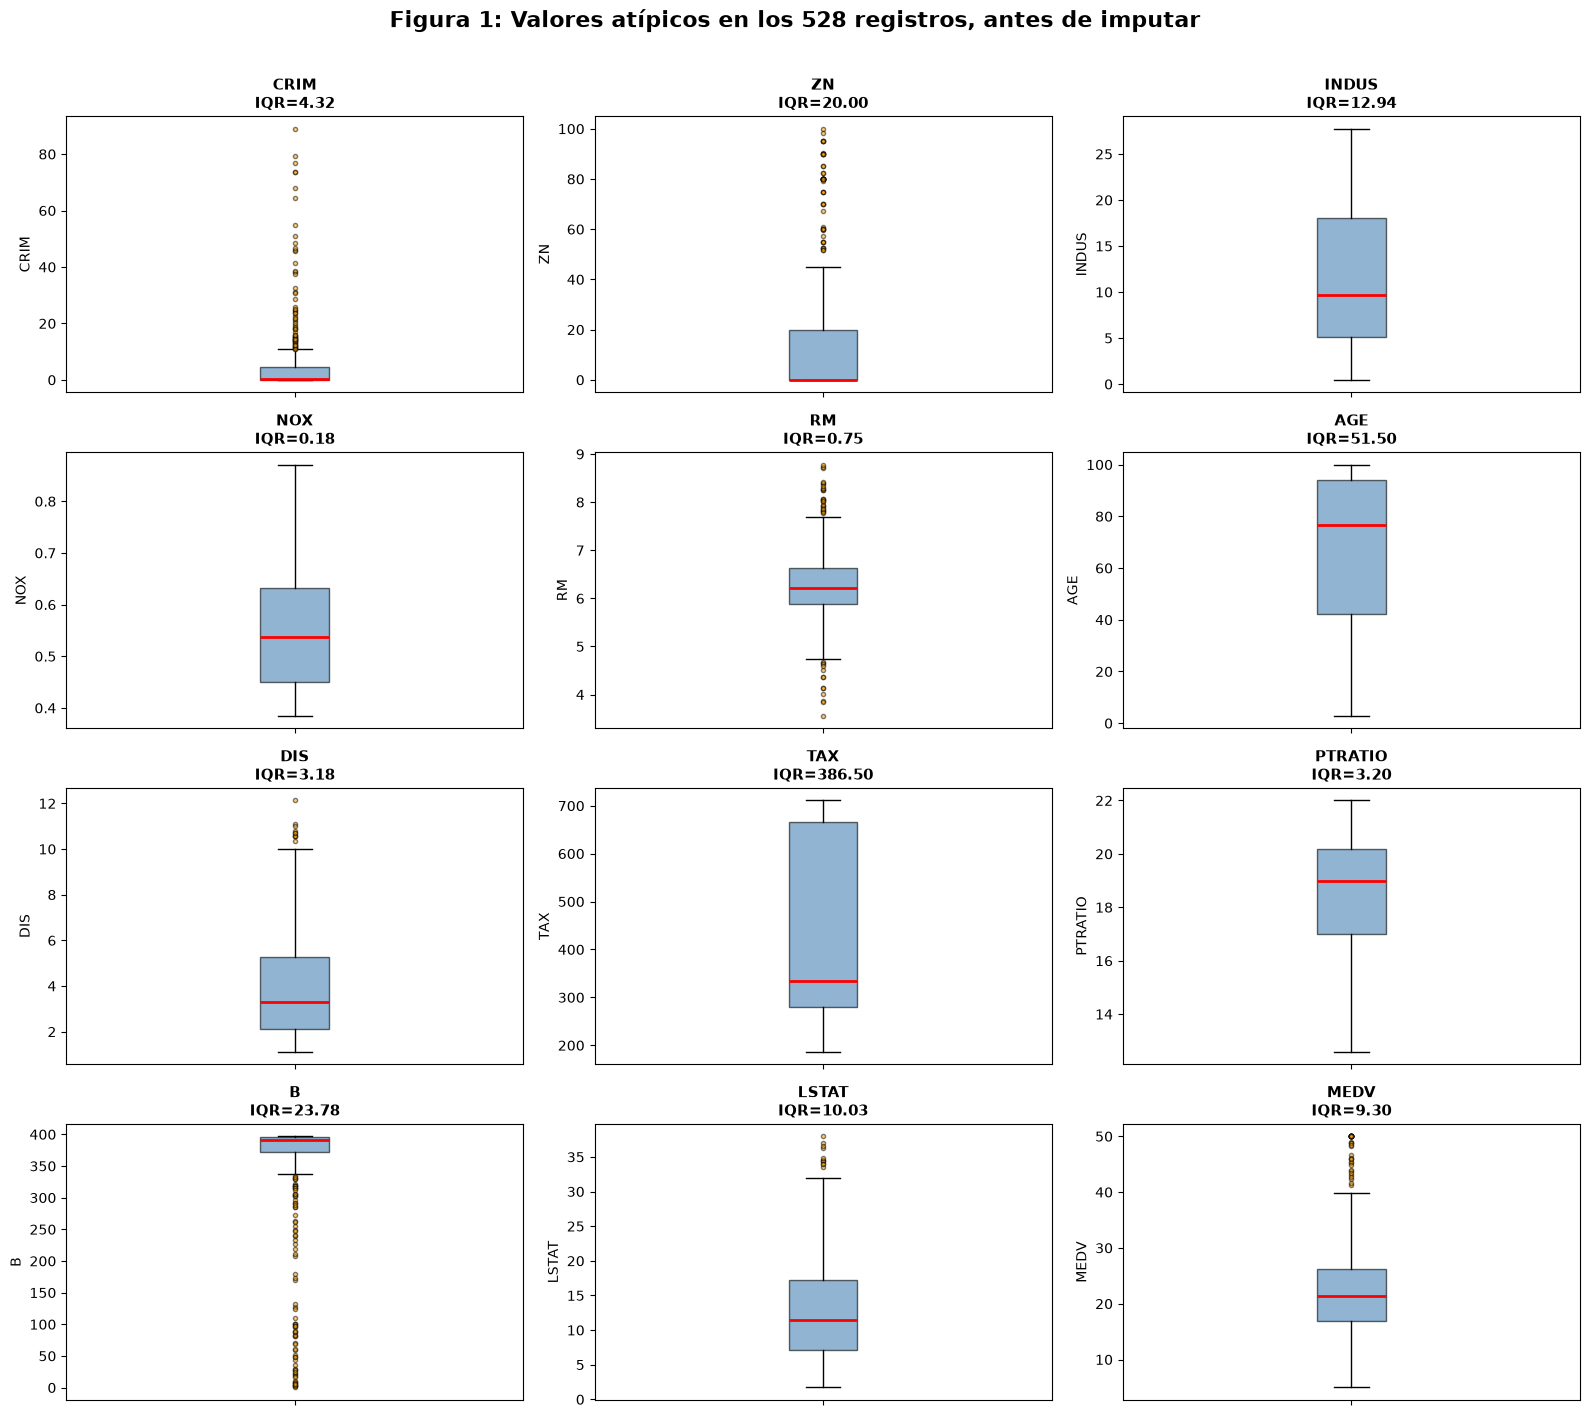

In [1229]:
# Variables continuas (se excluyen CHAS y RAD, que son discretas)
DISCRETAS = ['CHAS', 'RAD']
CONTINUAS = [c for c in cols_numericas if c not in DISCRETAS]

fig, axes = plt.subplots(4, 3, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(CONTINUAS):
    datos = df_limpio[col].dropna()          # los faltantes aún no se imputaron
    axes[i].boxplot(datos, vert=True, patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.6),
                    medianprops=dict(color='red', linewidth=2),
                    flierprops=dict(marker='o', markerfacecolor='orange', markersize=3, alpha=0.5))
    q1, q3 = datos.quantile(0.25), datos.quantile(0.75)
    axes[i].set_title(f'{col}\nIQR={q3 - q1:.2f}', fontweight='bold', fontsize=11)
    axes[i].set_ylabel(col)
    axes[i].tick_params(axis='x', labelbottom=False)

for j in range(len(CONTINUAS), len(axes)):
    axes[j].set_visible(False)

plt.suptitle(f'Figura {N_FIG}: Valores atípicos en los 528 registros, antes de imputar',
             fontsize=16, fontweight='bold', y=1.01)
N_FIG += 1
plt.tight_layout()
plt.show()

In [1230]:
# Cantidad de valores atípicos por el criterio IQR en cada variable continua
reporte = []
for col in CONTINUAS:
    datos = df_limpio[col].dropna()
    q1, q3 = datos.quantile(0.25), datos.quantile(0.75)
    iqr = q3 - q1
    outliers = ((datos < q1 - 1.5 * iqr) | (datos > q3 + 1.5 * iqr)).sum()
    reporte.append({'Variable': col, 'n': len(datos), 'Outliers IQR': outliers,
                    'Porcentaje (%)': round(100 * outliers / len(datos), 1),
                    'Media': datos.mean(), 'Mediana': datos.median()})

display(pd.DataFrame(reporte).set_index('Variable').round(2))

,n,Outliers IQR,Porcentaje (%),Media,Mediana
Variable,,,,,
CRIM,522,65,12.5,4.81,0.29
ZN,521,54,10.4,12.40,0.00
INDUS,527,0,0.0,11.22,9.69
NOX,523,0,0.0,0.56,0.54
RM,525,40,7.6,6.28,6.21
AGE,521,0,0.0,67.77,76.50
DIS,526,10,1.9,3.89,3.32
TAX,523,0,0.0,409.97,334.00
PTRATIO,523,0,0.0,18.44,19.00


**Qué muestran los boxplots.** Varias variables tienen una cantidad importante de valores fuera de los bigotes, en particular `CRIM`, `ZN` y `B`. En esas tres, además, la media y la mediana están muy separadas, que es la señal característica de una distribución asimétrica con cola larga.


`RobustScaler` usa en cambio la mediana y el rango intercuartílico, dos medidas que no dependen de los valores extremos:



Como decidimos conservar los outliers (son viviendas reales, según veremos en la sección 9), escalar con mediana e IQR es la opción coherente: los valores extremos siguen presentes, pero dejan de determinar la escala con la que se mide la distancia entre registros. Por eso usamos `RobustScaler` tanto acá, en el imputador, como más adelante en el escalado previo a los modelos (sección 13).

### 5.2 Elección del número de vecinos del KNNImputer

Para elegir $k$ usamos el método del notebook de imputación de la materia: introducir faltantes artificiales en registros completos, cuyos valores conocemos, imputarlos y comparar contra el valor verdadero. Como referencia (baseline) comparamos contra la imputación por mediana.

Para que la prueba sea realista, a cada registro le ocultamos valores siguiendo el mismo patrón de faltantes que tienen los registros incompletos reales. El error se mide en unidades de desvío estándar de cada variable, porque las escalas son muy distintas, y se repite con 10 semillas para que el resultado no dependa de qué valores se ocultaron al azar.

Aprovechamos el mismo experimento para comparar los dos escaladores y confirmar la elección de la sección anterior.

In [1231]:
# Patrones de faltantes reales, para reproducirlos en los registros completos
incompletos_train = X_train[X_train.isna().any(axis=1)]
patrones_nulos = incompletos_train[NUMERICAS].isna().values
completos_train = X_train[X_train.notna().all(axis=1)]

valores_k = [1, 3, 5, 7, 9, 11, 15, 21, 31]
escaladores = {'RobustScaler': RobustScaler, 'StandardScaler': StandardScaler}

errores = {'Mediana (baseline)': []}
for nombre_esc in escaladores:
    for k in valores_k:
        errores[f'k={k} ({nombre_esc})'] = []

for semilla in range(10):
    base = completos_train[NUMERICAS].copy()
    idx_ocultos = base.sample(frac=0.2, random_state=semilla).index
    rng = np.random.default_rng(semilla)

    mascara = pd.DataFrame(False, index=base.index, columns=NUMERICAS)
    mascara.loc[idx_ocultos] = patrones_nulos[rng.integers(0, len(patrones_nulos), len(idx_ocultos))]

    verdad = base.loc[idx_ocultos].copy()
    base[mascara] = np.nan
    referencia = base.drop(idx_ocultos)      # registros que quedaron completos
    desvio = referencia.std()

    def error_imputacion(imputado):
        # RMSE de los valores ocultados, en unidades de desvío estándar de cada variable
        diferencias = ((imputado - verdad) / desvio)[mascara.loc[idx_ocultos]]
        return np.sqrt(np.mean(diferencias.stack() ** 2))

    errores['Mediana (baseline)'].append(error_imputacion(base.loc[idx_ocultos].fillna(referencia.median())))

    for nombre_esc, Escalador in escaladores.items():
        escalador_eval = Escalador().fit(referencia)
        for k in valores_k:
            imputador = KNNImputer(n_neighbors=k).fit(escalador_eval.transform(referencia))
            reconstruido = pd.DataFrame(
                escalador_eval.inverse_transform(
                    imputador.transform(escalador_eval.transform(base.loc[idx_ocultos]))),
                columns=NUMERICAS, index=idx_ocultos)
            errores[f'k={k} ({nombre_esc})'].append(error_imputacion(reconstruido))

promedios = pd.Series({m: np.mean(v) for m, v in errores.items()})

# Tabla con una columna por escalador
resultados_imputacion = pd.DataFrame({
    esc: [promedios[f'k={k} ({esc})'] for k in valores_k] for esc in escaladores
}, index=[f'k={k}' for k in valores_k])
resultados_imputacion.loc['Mediana (baseline)'] = promedios['Mediana (baseline)']
display(resultados_imputacion.round(4))

K_VECINOS = valores_k[int(np.argmin([promedios[f'k={k} (RobustScaler)'] for k in valores_k]))]
print(f'Número de vecinos elegido: k = {K_VECINOS}')
print(f"Mejora sobre la imputación por mediana: "
      f"{100 * (1 - promedios[f'k={K_VECINOS} (RobustScaler)'] / promedios['Mediana (baseline)']):.0f}%")

,RobustScaler,StandardScaler
k=1,0.8034,0.8063
k=3,0.7075,0.6857
k=5,0.6850,0.6454
k=7,0.6765,0.6379
k=9,0.6642,0.6352
k=11,0.6629,0.6309
k=15,0.6588,0.6335
k=21,0.6667,0.6468
k=31,0.6873,0.6665
Mediana (baseline),1.0742,1.0742


Número de vecinos elegido: k = 15
Mejora sobre la imputación por mediana: 39%


**Elección de $k$.** El error de reconstrucción tiene forma de U: con pocos vecinos la imputación copia los valores de muy pocos registros y resulta ruidosa; con demasiados se parece a usar el promedio del dataset y pierde la información local. El mínimo está en $k = 15$, y a partir de ahí el error vuelve a subir, así que no es un valor de borde de la grilla.

Lo importante es la comparación contra el baseline: KNN reduce el error de imputación aproximadamente un 39% respecto de imputar por la mediana, que es lo que justifica usar un método basado en vecinos y no un estadístico fijo.

Sobre los escaladores, la tabla muestra que `StandardScaler` obtiene un error levemente menor que `RobustScaler` (alrededor de 0,63 contra 0,66). La diferencia es chica comparada con la mejora frente a la mediana (1,07), y optamos por `RobustScaler` por coherencia con la decisión de conservar los outliers: preferimos que unos pocos valores extremos no definan la escala con la que se miden las distancias. 

### 5.3 Imputación de las variables numéricas con KNN

KNN trabaja con distancias, así que las variables se escalan antes de buscar los vecinos, con el `RobustScaler` justificado en la sección 5.1.

Un detalle importante de implementación: el imputador devuelve la matriz completa, y al deshacer el escalado los valores que no estaban faltantes vuelven con un pequeño error de redondeo (un `ZN` que valía 0 puede volver como 1×10⁻¹⁷). Por eso escribimos el resultado únicamente en las celdas que estaban vacías, dejando intactos los valores originales.

In [1232]:
# Imputamos los valores faltantes con KNN con RobustScaler
escalador_knn = RobustScaler().fit(X_train[NUMERICAS])
imputador_knn = KNNImputer(n_neighbors=K_VECINOS).fit(escalador_knn.transform(X_train[NUMERICAS]))

def imputar_numericas(Z):
    reconstruido = pd.DataFrame(
        escalador_knn.inverse_transform(imputador_knn.transform(escalador_knn.transform(Z[NUMERICAS]))),
        columns=NUMERICAS, index=Z.index)
    salida = Z.copy()
    # Sólo se escriben las celdas que estaban vacías: los valores originales no se tocan
    salida[NUMERICAS] = Z[NUMERICAS].where(~Z[NUMERICAS].isna(), reconstruido)
    return salida

X_train = imputar_numericas(X_train)
X_test = imputar_numericas(X_test)

print('Valores faltantes tras la imputación numérica:')
print('=' * 55)
print(f'  Numéricas en train: {X_train[NUMERICAS].isna().sum().sum()} | test: {X_test[NUMERICAS].isna().sum().sum()}')
print(f'  Categóricas pendientes en train: {X_train[CATEGORICAS].isna().sum().sum()} | '
      f'test: {X_test[CATEGORICAS].isna().sum().sum()}')

Valores faltantes tras la imputación numérica:
  Numéricas en train: 0 | test: 0
  Categóricas pendientes en train: 18 | test: 7


### 5.4 Imputación de las variables categóricas con CatBoost

Para `CHAS` y `RAD` entrenamos un clasificador CatBoost que predice la categoría a partir de las 11 variables numéricas, siguiendo el notebook de imputación de la materia. CatBoost maneja variables categóricas de forma nativa mediante target statistics con ordered boosting, un esquema que evita el target leakage típico de las codificaciones ingenuas.

Cada clasificador se entrena solo con los registros de entrenamiento que tienen esa variable observada, y después predice los casos faltantes de train y de test.

In [1233]:
for categorica in CATEGORICAS:
    observados = X_train[categorica].notna()

    modelo_cat = CatBoostClassifier(iterations=300, learning_rate=0.05, depth=4,
                                    verbose=False, random_seed=RANDOM_STATE)
    modelo_cat.fit(X_train.loc[observados, NUMERICAS],
                   X_train.loc[observados, categorica].astype(int).astype(str))

    for nombre, conjunto in [('train', X_train), ('test', X_test)]:
        faltantes = conjunto[categorica].isna()
        if faltantes.any():
            prediccion = modelo_cat.predict(conjunto.loc[faltantes, NUMERICAS]).ravel()
            conjunto.loc[faltantes, categorica] = [int(p) for p in prediccion]
            print(f'{categorica} en {nombre}: {faltantes.sum()} valores imputados -> '
                  f'{sorted(pd.Series(prediccion).astype(int))}')

CHAS en train: 3 valores imputados -> [0, 0, 0]
RAD en train: 15 valores imputados -> [4, 4, 5, 5, 5, 6, 6, 24, 24, 24, 24, 24, 24, 24, 24]
RAD en test: 7 valores imputados -> [3, 5, 24, 24, 24, 24, 24]


In [1234]:
# Verificación de la imputación
print('Verificación del dataset imputado:')
print('=' * 55)
print(f'  Valores faltantes en train: {X_train.isna().sum().sum()}')
print(f'  Valores faltantes en test:  {X_test.isna().sum().sum()}')
print(f'  Valores de RAD:  {sorted(X_train["RAD"].unique())}')
print(f'  Valores de CHAS: {sorted(X_train["CHAS"].unique())}')

Verificación del dataset imputado:
  Valores faltantes en train: 0
  Valores faltantes en test:  0
  Valores de RAD:  [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(7.0), np.float64(8.0), np.float64(24.0)]
  Valores de CHAS: [np.float64(0.0), np.float64(1.0)]


**Observación.** El dataset queda completo y las dos variables categóricas conservan su dominio: `RAD` vuelve a tomar únicamente los 9 valores válidos y `CHAS` sigue siendo binaria. Eso es precisamente lo que no se lograría con un imputador numérico.

---

## 6. Análisis descriptivo

A partir de esta sección analizamos solo el conjunto de entrenamiento, para no tomar decisiones de modelado mirando el test.

### 6.1 Medidas de tendencia central, dispersión, sesgo y curtosis

In [1235]:
# DataFrame de entrenamiento con el target, para el análisis exploratorio
df_train = X_train.assign(MEDV=y_train)

desc = df_train.describe().T
desc['mediana'] = df_train.median()
desc['CV(%)'] = (desc['std'] / desc['mean']) * 100
desc['sesgo'] = df_train.skew()
desc['curtosis'] = df_train.kurtosis()

print('Estadísticos descriptivos completos (train):')
print('=' * 80)
desc[['mean', 'mediana', 'std', 'CV(%)', 'min', '25%', '50%', '75%', 'max', 'sesgo', 'curtosis']].round(3)

Estadísticos descriptivos completos (train):


,mean,mediana,std,CV(%),min,25%,50%,75%,max,sesgo,curtosis
CRIM,4.625,0.290,10.514,227.359,0.006,0.082,0.290,4.663,76.757,4.156,20.819
ZN,12.608,0.000,24.746,196.264,0.000,0.000,0.000,20.000,100.000,2.050,3.110
INDUS,11.373,9.900,6.983,61.397,0.460,5.145,9.900,18.100,27.740,0.250,-1.218
CHAS,0.071,0.000,0.257,361.908,0.000,0.000,0.000,0.000,1.000,3.350,9.267
NOX,0.560,0.538,0.118,21.099,0.385,0.453,0.538,0.641,0.871,0.666,-0.198
RM,6.312,6.214,0.769,12.186,3.561,5.877,6.214,6.682,8.780,0.400,1.277
AGE,67.984,76.186,28.399,41.773,6.000,42.450,76.186,94.100,100.000,-0.563,-1.019
DIS,3.860,3.346,2.187,56.674,1.169,2.100,3.346,5.227,12.126,1.083,0.763
RAD,9.813,5.000,8.907,90.767,1.000,4.000,5.000,24.000,24.000,0.918,-1.047
TAX,413.927,336.000,169.736,41.006,187.000,279.000,336.000,666.000,711.000,0.593,-1.251


In [1236]:
# Calculamos el sesgo y la curtosis de todas las características para interpretarlos
print('Interpretación del Sesgo y Curtosis:')
print('=' * 60)

for col in cols_numericas:
    sesgo = df_train[col].skew()
    curtosis = df_train[col].kurtosis()

    if abs(sesgo) < 0.5:
        tipo_sesgo = 'aproximadamente simétrica'
    elif sesgo > 0:
        tipo_sesgo = f'sesgo positivo ({"moderado" if sesgo < 1 else "alto"})'
    else:
        tipo_sesgo = f'sesgo negativo ({"moderado" if abs(sesgo) < 1 else "alto"})'

    if abs(curtosis) < 0.5:
        tipo_curtosis = 'mesocúrtica'
    elif curtosis > 0:
        tipo_curtosis = 'leptocúrtica (colas pesadas)'
    else:
        tipo_curtosis = 'platicúrtica (colas livianas)'

    print(f'  {col:>8s}: sesgo={sesgo:+.3f} [{tipo_sesgo}], '
          f'curtosis={curtosis:+.3f} [{tipo_curtosis}]')

Interpretación del Sesgo y Curtosis:
      CRIM: sesgo=+4.156 [sesgo positivo (alto)], curtosis=+20.819 [leptocúrtica (colas pesadas)]
        ZN: sesgo=+2.050 [sesgo positivo (alto)], curtosis=+3.110 [leptocúrtica (colas pesadas)]
     INDUS: sesgo=+0.250 [aproximadamente simétrica], curtosis=-1.218 [platicúrtica (colas livianas)]
      CHAS: sesgo=+3.350 [sesgo positivo (alto)], curtosis=+9.267 [leptocúrtica (colas pesadas)]
       NOX: sesgo=+0.666 [sesgo positivo (moderado)], curtosis=-0.198 [mesocúrtica]
        RM: sesgo=+0.400 [aproximadamente simétrica], curtosis=+1.277 [leptocúrtica (colas pesadas)]
       AGE: sesgo=-0.563 [sesgo negativo (moderado)], curtosis=-1.019 [platicúrtica (colas livianas)]
       DIS: sesgo=+1.083 [sesgo positivo (alto)], curtosis=+0.763 [leptocúrtica (colas pesadas)]
       RAD: sesgo=+0.918 [sesgo positivo (moderado)], curtosis=-1.047 [platicúrtica (colas livianas)]
       TAX: sesgo=+0.593 [sesgo positivo (moderado)], curtosis=-1.251 [platicúrtica

### 6.2 Distribuciones

Separamos las variables según su naturaleza, porque el gráfico adecuado no es el mismo:

- Las continuas se analizan con histogramas y estimación de densidad, marcando media y mediana para ver la asimetría.
- Las discretas (`CHAS`, que es binaria, y `RAD`, que es un índice con 9 categorías) se analizan con gráficos de conteo: un histograma sobre ellas sugeriría una continuidad que no existe.

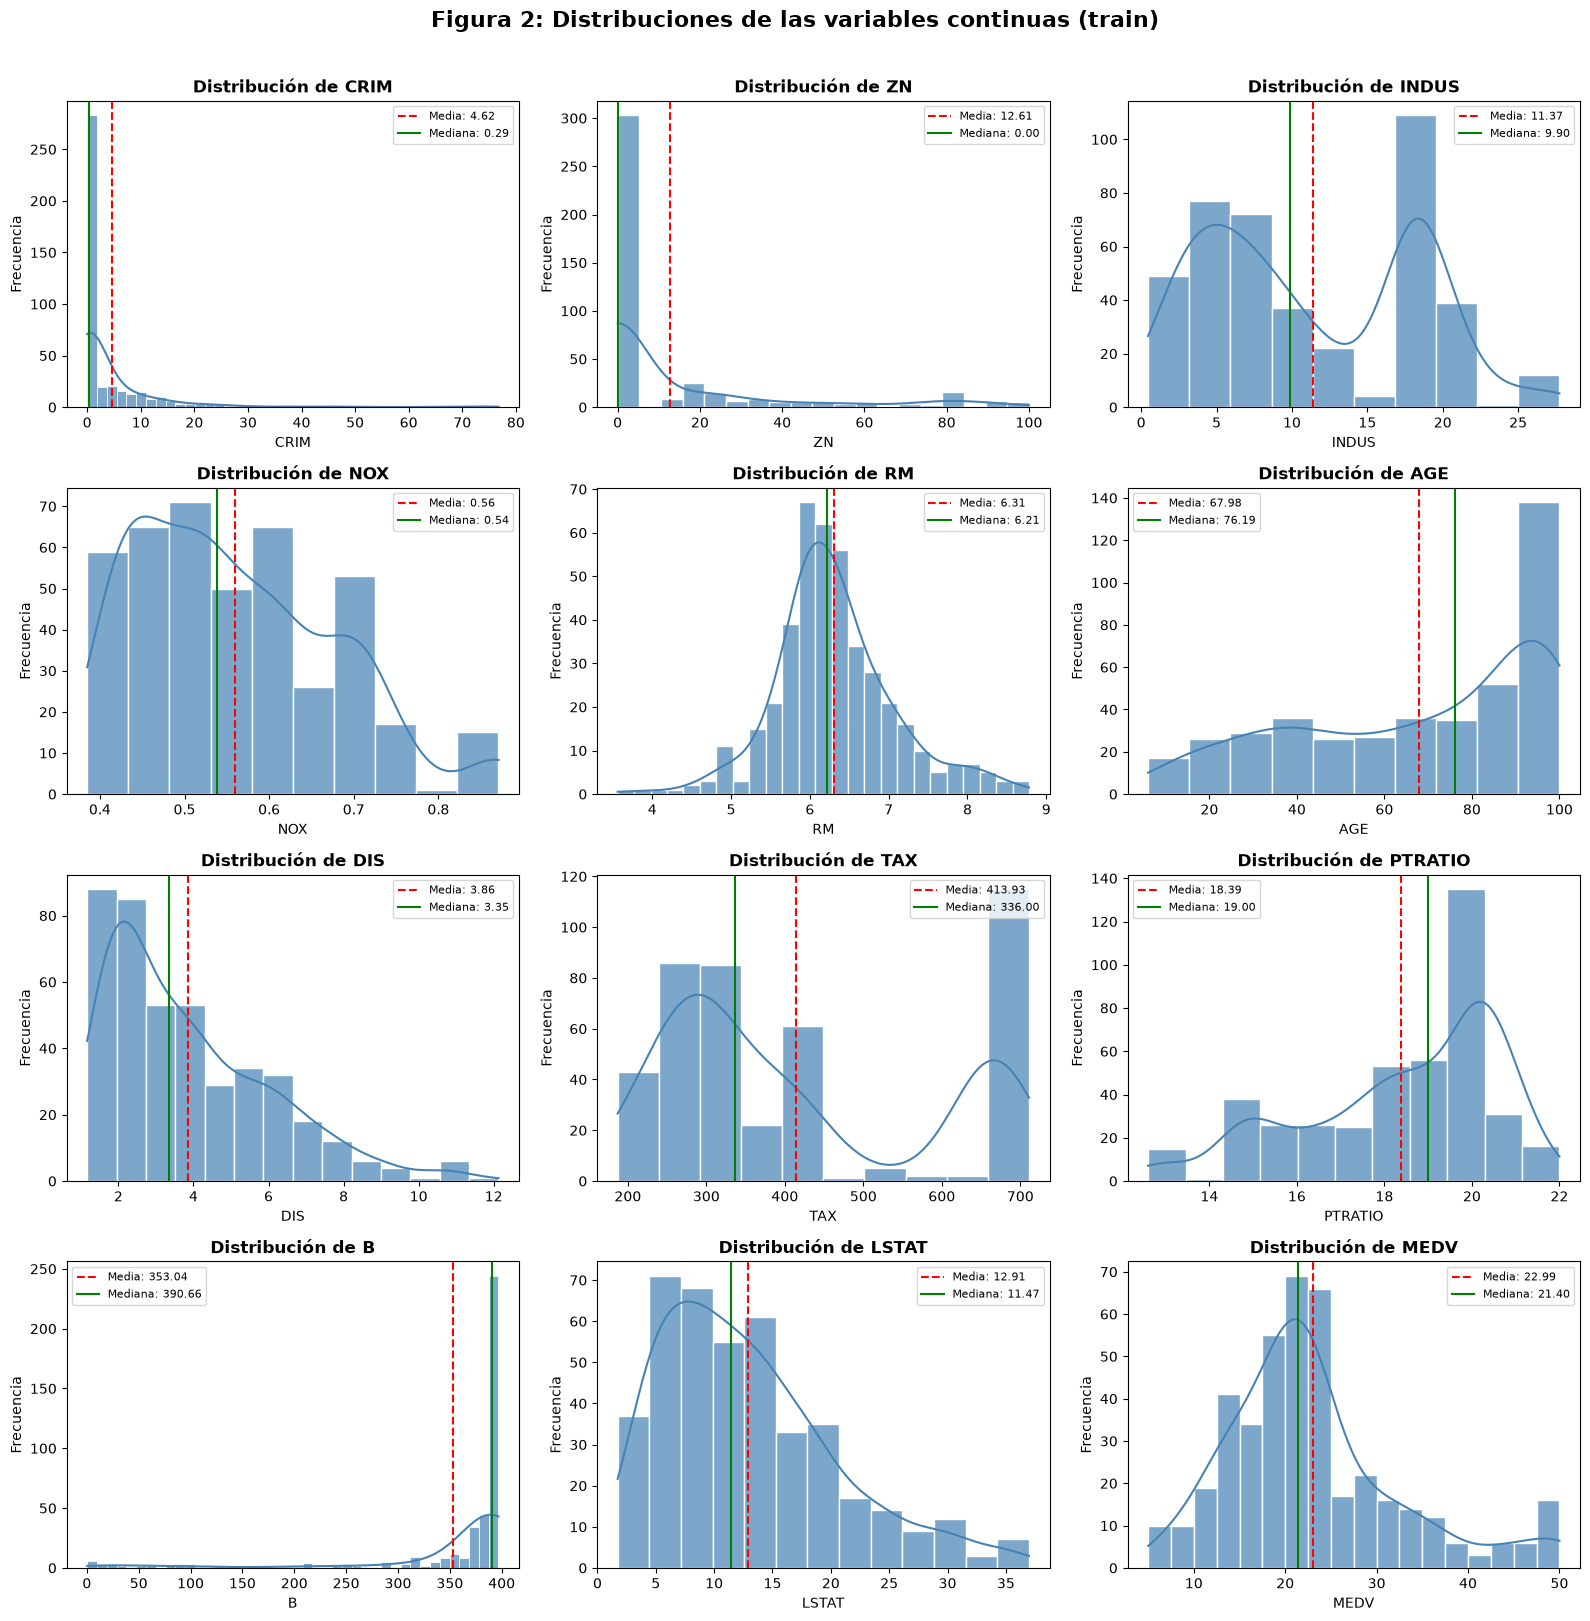

In [1237]:
# Histogramas y estimación de densidad (KDE) de las variables continuas, con media y mediana
fig, axes = plt.subplots(4, 3, figsize=(16, 16))
axes = axes.flatten()

for i, col in enumerate(CONTINUAS):
    ax = axes[i]
    sns.histplot(df_train[col], kde=True, ax=ax, color='steelblue', edgecolor='white', alpha=0.7)

    media = df_train[col].mean()
    mediana = df_train[col].median()
    ax.axvline(media, color='red', linestyle='--', linewidth=1.5, label=f'Media: {media:.2f}')
    ax.axvline(mediana, color='green', linestyle='-', linewidth=1.5, label=f'Mediana: {mediana:.2f}')

    ax.set_title(f'Distribución de {col}', fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Frecuencia')
    ax.legend(fontsize=8)

for j in range(len(CONTINUAS), len(axes)):
    axes[j].set_visible(False)

plt.suptitle(f'Figura {N_FIG}: Distribuciones de las variables continuas (train)',
             fontsize=16, fontweight='bold', y=1.01)
N_FIG += 1
plt.tight_layout()
plt.show()

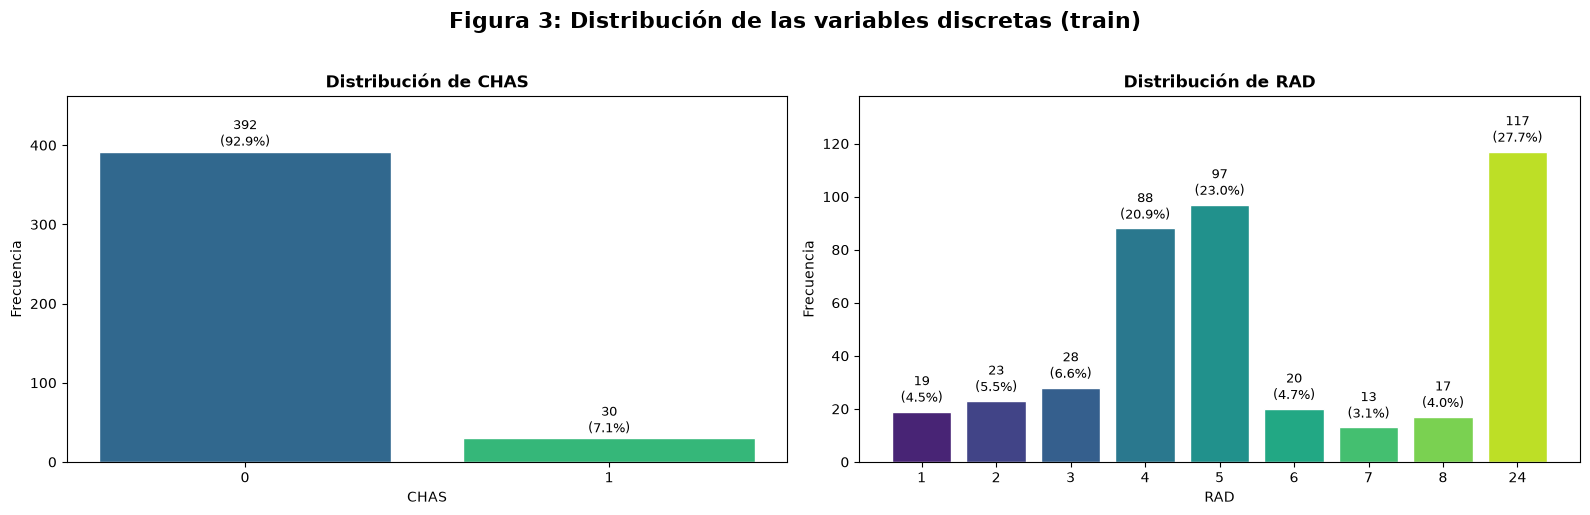

CHAS,0.0,1.0
CHAS,392,30


RAD,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,24.0
RAD,19,23,28,88,97,20,13,17,117


In [1238]:
# Gráficos de conteo de las variables discretas
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, col in zip(axes, DISCRETAS):
    conteo = df_train[col].value_counts().sort_index()
    barras = ax.bar(conteo.index.astype(int).astype(str), conteo.values,
                    color=sns.color_palette('viridis', len(conteo)), edgecolor='white')

    total = conteo.sum()
    for barra, valor in zip(barras, conteo.values):
        ax.text(barra.get_x() + barra.get_width() / 2, barra.get_height() + total * 0.005,
                f'{valor}\n({valor / total * 100:.1f}%)', ha='center', va='bottom', fontsize=9)

    ax.set_title(f'Distribución de {col}', fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Frecuencia')
    ax.set_ylim(0, conteo.max() * 1.18)

plt.suptitle(f'Figura {N_FIG}: Distribución de las variables discretas (train)',
             fontsize=16, fontweight='bold', y=1.02)
N_FIG += 1
plt.tight_layout()
plt.show()

display(pd.DataFrame({'CHAS': df_train['CHAS'].value_counts().sort_index()}).T)
display(pd.DataFrame({'RAD': df_train['RAD'].value_counts().sort_index()}).T)

**Observaciones.**

- En la figura 2 se observa que `CRIM`, `ZN` y `B` son las variables más asimétricas (`CRIM` con sesgo positivo alto, `B` con sesgo negativo alto). La mayoría de las zonas tiene criminalidad muy baja y unas pocas la tienen muy alta; en `B` ocurre al revés. En los tres casos la media y la mediana están claramente separadas
- `MEDV` tiene sesgo positivo, y en su histograma se ve la acumulación en 50.
- En la figura 3 se observa que `CHAS` está muy desbalanceada: sólo el 7% de las zonas limita con el río Charles. Por eso su sesgo y su curtosis no deben leerse como en una variable continua: cualquier valor 1 queda fuera de los bigotes de un boxplot sin que eso signifique que sea un valor atípico.
- Además, `RAD` muestra con claridad su naturaleza de índice categórico: nueve valores posibles, con el 24 como el más frecuente y un hueco total entre 8 y 24. Ese hueco es la razón por la que la tratamos como discreta y la imputamos con un clasificador.

---

## 7. Pruebas de normalidad

In [1239]:
# Pruebas para analizar la normalidad de las variables
ALPHA = 0.05

resultados_normalidad = []

for col in cols_numericas:
    datos = df_train[col]

    stat_dag, p_dag = stats.normaltest(datos)   
    stat_shap, p_shap = stats.shapiro(datos)    
    
    resultados_normalidad.append({
        'Variable': col,
        'Shapiro-p': p_shap,
        'DAgostino-p': p_dag,
        'Normal (alpha=0.05)': 'Si' if (p_shap > ALPHA and p_dag > ALPHA) else 'No'
    })

df_normalidad = pd.DataFrame(resultados_normalidad)
print('Resultados de Pruebas de Normalidad:')
print('=' * 80)
df_normalidad

Resultados de Pruebas de Normalidad:


,Variable,Shapiro-p,DAgostino-p,Normal (alpha=0.05)
0,CRIM,3.294537e-33,5.886818e-86,No
1,ZN,1.014959e-30,1.049271e-37,No
2,INDUS,3.027600e-15,1.490995e-64,No
3,CHAS,1.930389e-37,5.913354e-67,No
4,NOX,7.044545e-12,1.011570e-06,No
5,RM,4.036206e-08,6.340427e-06,No
6,AGE,1.832019e-16,5.041855e-25,No
7,DIS,3.909398e-16,7.157905e-15,No
8,RAD,2.910312e-27,1.785267e-33,No
9,TAX,4.095154e-21,4.824132e-86,No


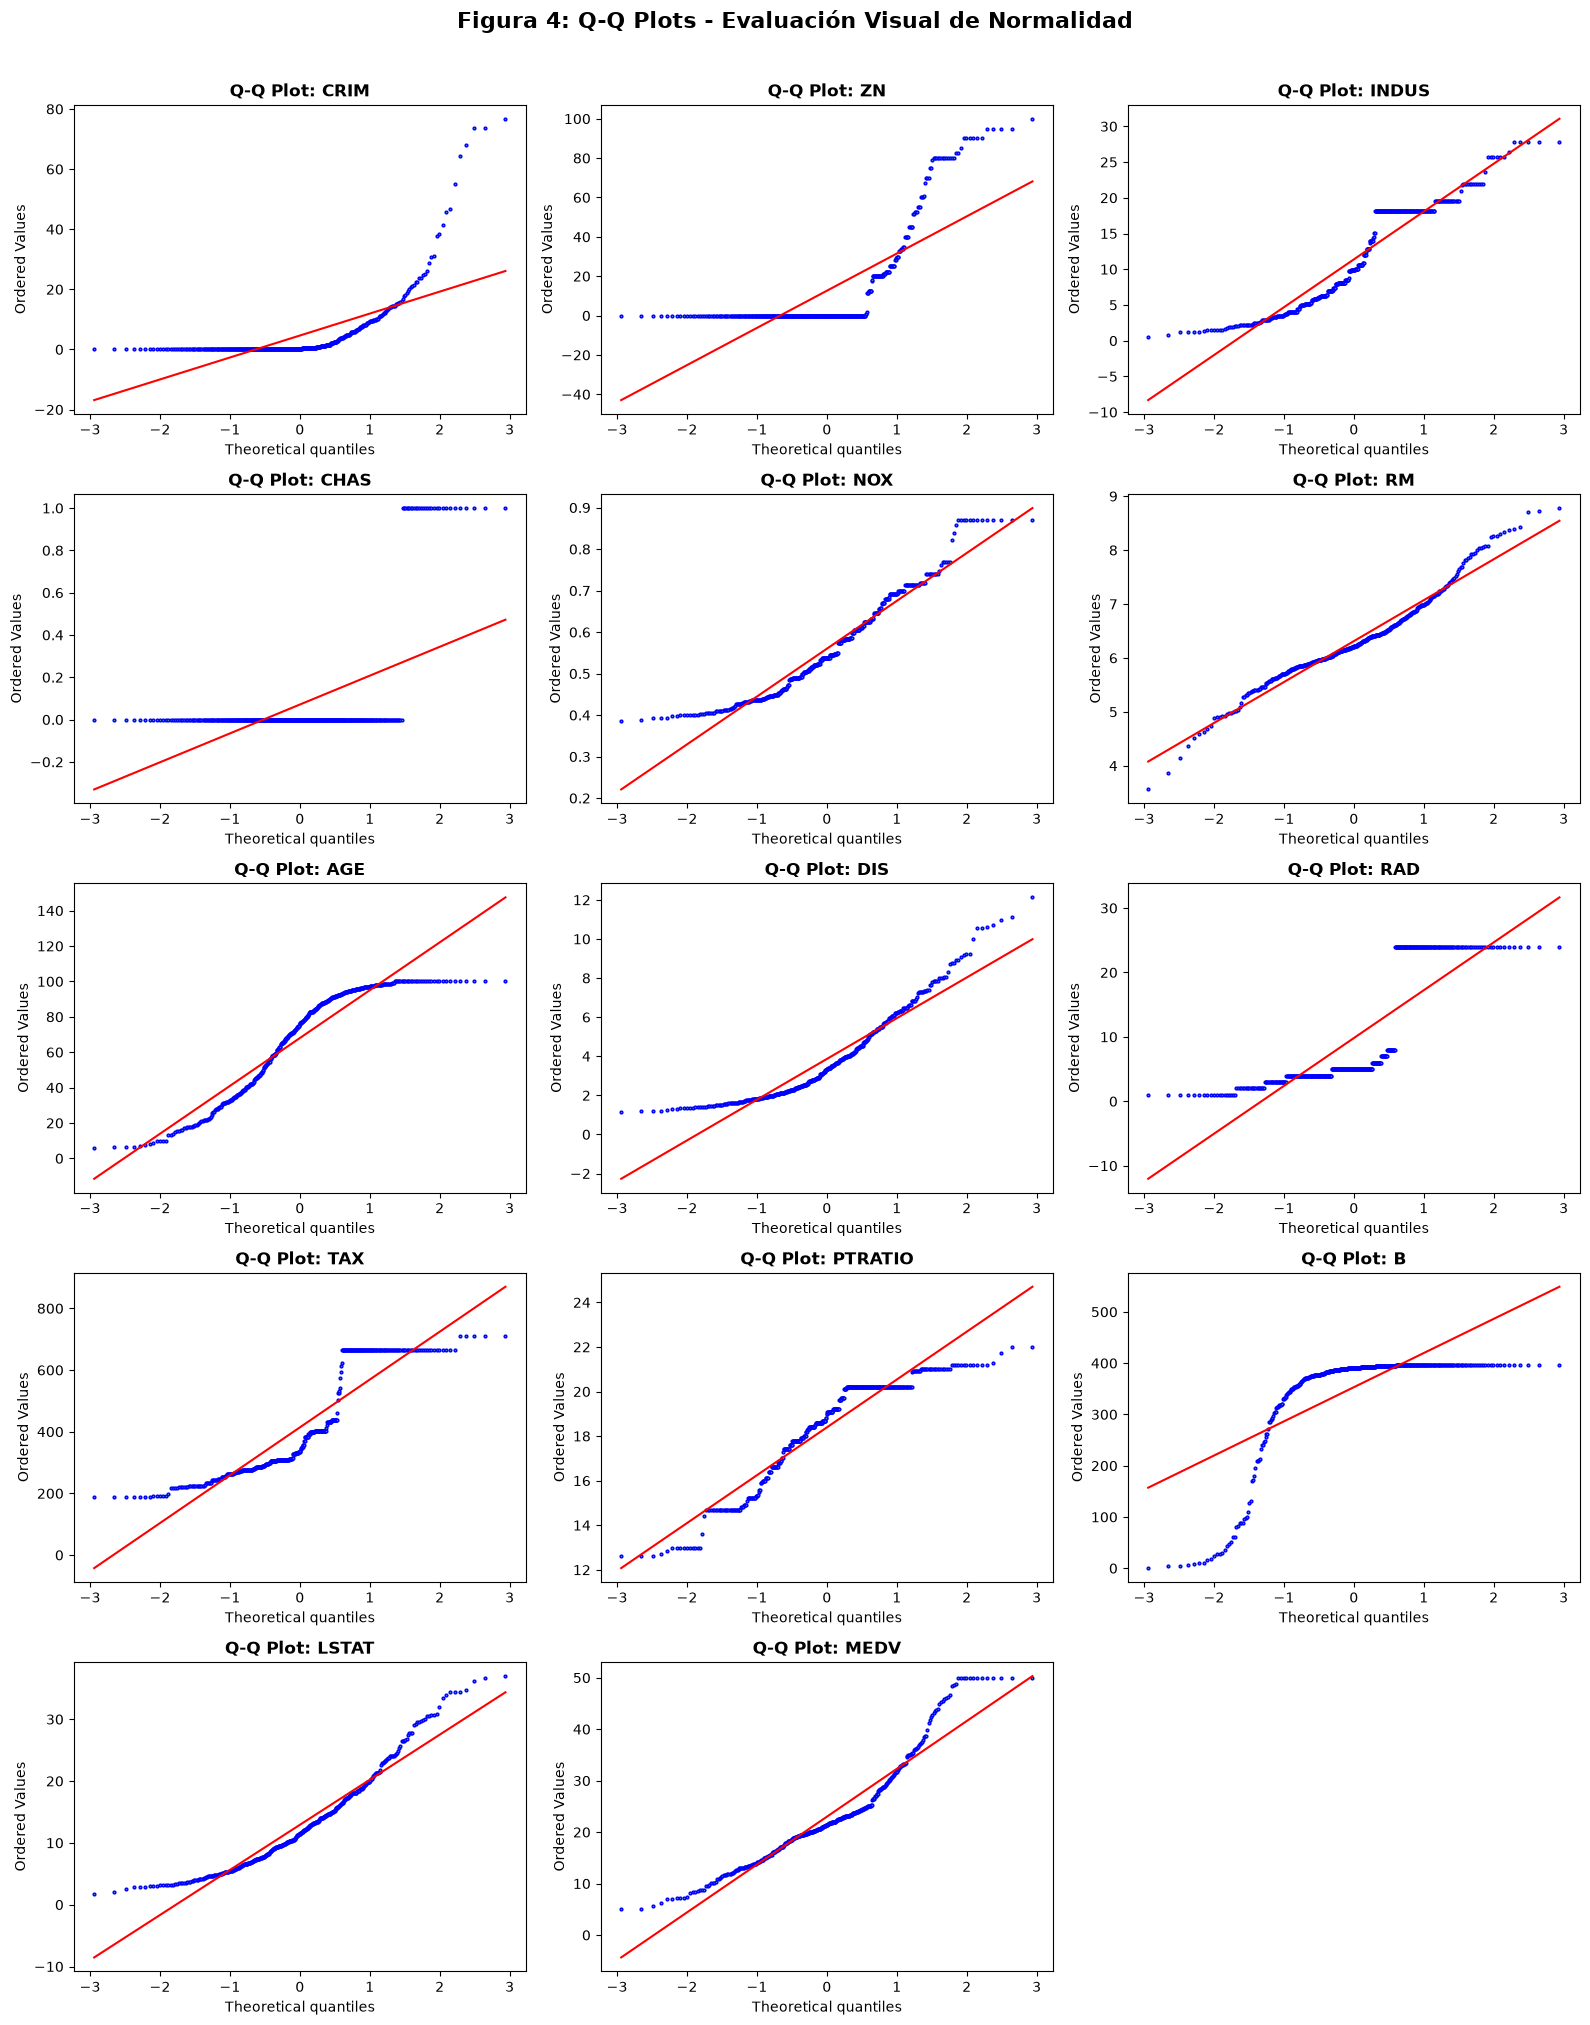

In [1240]:
# Q-Q plots: evaluación visual de normalidad
fig, axes = plt.subplots(5, 3, figsize=(16, 20))
axes = axes.flatten()

for i, col in enumerate(cols_numericas):
    ax = axes[i]
    stats.probplot(df_train[col], dist='norm', plot=ax)
    ax.set_title(f'Q-Q Plot: {col}', fontweight='bold')
    ax.get_lines()[0].set_markerfacecolor('steelblue')
    ax.get_lines()[0].set_markersize(2)
    ax.get_lines()[1].set_color('red')

for j in range(len(cols_numericas), len(axes)):
    axes[j].set_visible(False)

plt.suptitle(f'Figura {N_FIG}: Q-Q Plots - Evaluación Visual de Normalidad', fontsize=16, fontweight='bold', y=1.01)
N_FIG += 1
plt.tight_layout()
plt.show()

**Observación:** Ninguna variable supera los tests de normalidad, esto también se puede ver reflejado en la figura 4, algo esperable en datos reales. Esto no impide usar regresión lineal: el modelo no requiere que las features sean normales. El supuesto de normalidad de la regresión lineal se refiere a los residuos del modelo, y lo vamos a revisar cuando entrenemos los modelos.

---

## 8. Correlaciones y colinealidad

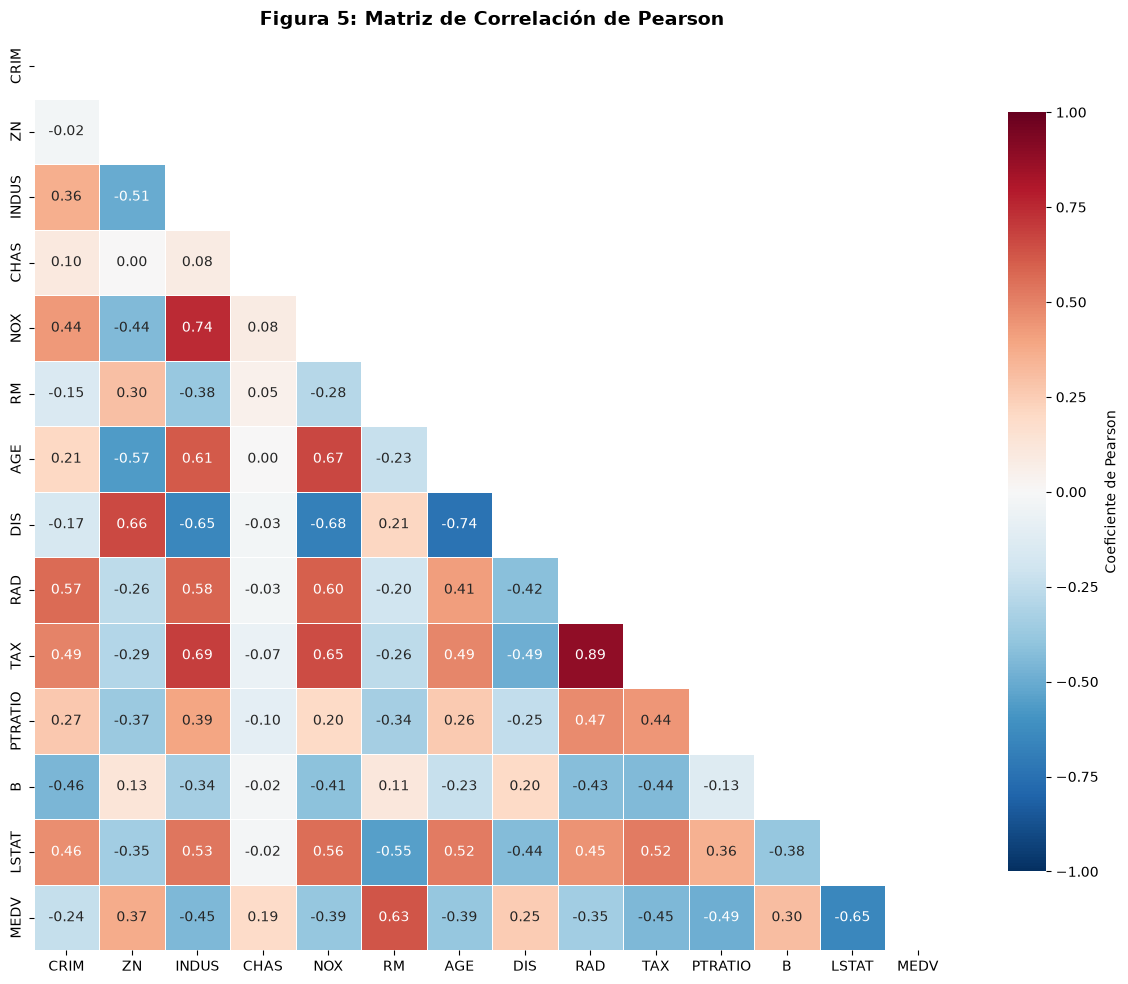

In [1241]:
# Matriz de correlación de Pearson
corr_pearson = df_train.corr(method='pearson')

mask = np.triu(np.ones_like(corr_pearson, dtype=bool))

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr_pearson, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.8, 'label': 'Coeficiente de Pearson'})
ax.set_title(f'Figura {N_FIG}: Matriz de Correlación de Pearson', fontsize=14, fontweight='bold')
N_FIG += 1
plt.tight_layout()
plt.show()

In [1242]:
# Correlación de cada feature con el target, ordenada por intensidad
corr_target = corr_pearson['MEDV'].drop('MEDV')
corr_target.reindex(corr_target.abs().sort_values(ascending=False).index).round(3)

LSTAT     -0.653
RM         0.626
PTRATIO   -0.487
TAX       -0.449
INDUS     -0.446
AGE       -0.390
NOX       -0.389
ZN         0.370
RAD       -0.348
B          0.305
DIS        0.252
CRIM      -0.238
CHAS       0.189
Name: MEDV, dtype: float64

In [1243]:
# Buscamos colinealidad entre pares de features
umbral_colinealidad = 0.85
corr_features = corr_pearson.drop(index='MEDV', columns='MEDV')

print(f'Pares con |r_pearson| >= {umbral_colinealidad} (posible colinealidad):')
print('=' * 60)

pares_colineales = []
for i in range(len(corr_features.columns)):
    for j in range(i + 1, len(corr_features.columns)):
        r = corr_features.iloc[i, j]
        if abs(r) >= umbral_colinealidad:
            var1 = corr_features.columns[i]
            var2 = corr_features.columns[j]
            pares_colineales.append((var1, var2, r))
            print(f'  {var1} <-> {var2}: r = {r:.4f}')

if not pares_colineales:
    print('  No se detectaron pares con colinealidad severa.')

Pares con |r_pearson| >= 0.85 (posible colinealidad):
  RAD <-> TAX: r = 0.8861


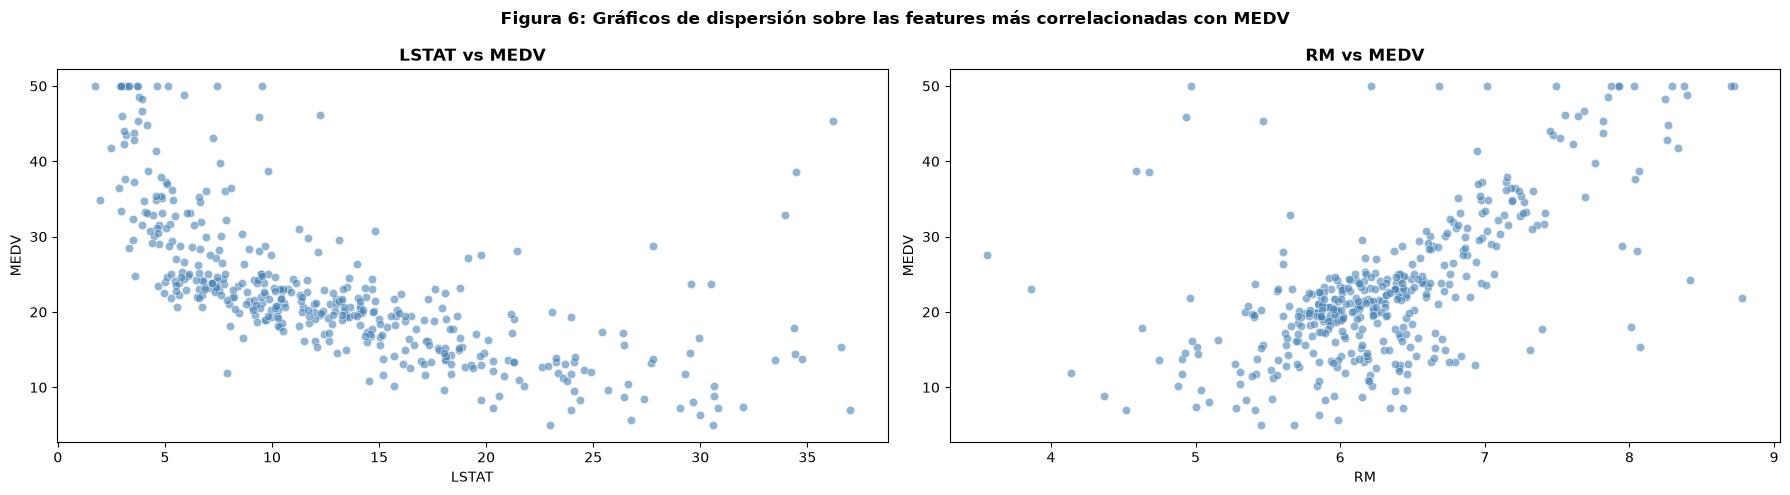

In [1244]:
# Relación de las features más correlacionadas con el target
fig, axes = plt.subplots(1, 2, figsize=(18, 5))
for ax, col in zip(axes, ['LSTAT', 'RM']):
    sns.scatterplot(x=df_train[col], y=df_train['MEDV'], ax=ax, alpha=0.6, color='steelblue')
    ax.set_title(f'{col} vs MEDV', fontweight='bold')
plt.suptitle(f'Figura {N_FIG}: Gráficos de dispersión sobre las features más correlacionadas con MEDV', fontweight="bold")
N_FIG += 1
plt.tight_layout()
plt.show()

**Observaciones:**

- Las features más correlacionadas con el precio son `LSTAT` (−0,65) y `RM` (+0,63): a mayor proporción de población de menor estatus socioeconómico, menor precio; a más habitaciones, mayor precio. Le siguen `PTRATIO`, `INDUS` y `TAX`, con correlaciones negativas moderadas.
- En la figura 6 de `LSTAT` vs `MEDV` la relación no es del todo lineal (es curva). También se ve la línea horizontal de registros en `MEDV` = 50 que produce la censura.
- `RAD` y `TAX` son colineales ($r = 0{,}89$)
- Elegimos no eliminar manualmente ninguna de las dos variables colineales debido a que realizaremos algoritmos con selección intrínseca de características como Lasso y ElasticNet.

---

## 9. Detección de outliers

In [1245]:
# Reporte de outliers por los métodos IQR 
IQR_FACTOR = 1.5

reporte_outliers = []

for col in cols_numericas:
    datos = df_train[col]
    n = len(datos)

    q1 = datos.quantile(0.25)
    q3 = datos.quantile(0.75)
    iqr = q3 - q1
    outliers_iqr = ((datos < q1 - IQR_FACTOR * iqr) | (datos > q3 + IQR_FACTOR * iqr)).sum()


    reporte_outliers.append({
        'Variable': col,
        'Outliers_IQR': outliers_iqr,
        'Pct_IQR(%)': outliers_iqr / n * 100,
    })

df_outliers = pd.DataFrame(reporte_outliers)
print('Reporte de Outliers: Método IQR')
print('=' * 70)
df_outliers.round(2)

Reporte de Outliers: Método IQR


,Variable,Outliers_IQR,Pct_IQR(%)
0,CRIM,51,12.09
1,ZN,46,10.90
2,INDUS,0,0.00
3,CHAS,30,7.11
4,NOX,0,0.00
5,RM,27,6.40
6,AGE,0,0.00
7,DIS,8,1.90
8,RAD,0,0.00
9,TAX,0,0.00


**Observaciones y decisión:**

- Las variables con más outliers son `B`, `CRIM` y `ZN`, que son las más asimétricas. En distribuciones con sesgo alto, el método IQR marca como outliers muchos valores que son parte de la cola natural de la distribución.
- En `CHAS`, los "outliers" son simplemente las 24 zonas que limitan con el río: al ser binaria, cualquier valor 1 queda fuera de los bigotes.
- En `MEDV`, parte de los outliers son los registros censurados en 50.

**Decisión: no eliminamos outliers.** Son valores posibles de viviendas reales (zonas con criminalidad muy alta, casas muy caras) y no errores de carga, que ya tratamos en la sección 3. Eliminarlos reduciría la capacidad del modelo de predecir justamente esos casos.

---

## 10. Control de coherencia lógica

Un registro puede tener todos sus valores dentro del rango permitido y ser, aun así, imposible: lo que falla no es cada valor por separado sino la combinación. Una zona con el 60% del suelo destinado a lotes residenciales grandes no puede tener a la vez la tasa de criminalidad más alta de la ciudad.

Para detectar ese tipo de incoherencia:

1. Derivamos patrones estructurales a partir de los registros completos del conjunto de entrenamiento.
2. Los validamos contra los registros completos del conjunto de prueba, que no participaron de su construcción.
3. Evaluamos los registros imputados contra esos patrones.

Es el mismo razonamiento que usamos con `RAD`: si un valor (o una combinación de valores) no puede existir, el dato no es utilizable.

### 10.1 Los valores extremos de CRIM, ZN y B frente al precio

El análisis de outliers de la sección 9 dejó una pregunta abierta: los valores extremos de `CRIM`, `ZN` y `B`, ¿corresponden a viviendas reales o hay entre ellos registros que no deberían estar?

Un valor extremo por sí solo no dice nada. Lo que sí es informativo es cómo se relaciona ese valor con el precio: si un registro con criminalidad altísima tiene además un precio altísimo, está rompiendo la relación que sostiene todo el resto del dataset. Graficamos las tres variables contra `MEDV`, distinguiendo los registros que tuvimos que imputar.

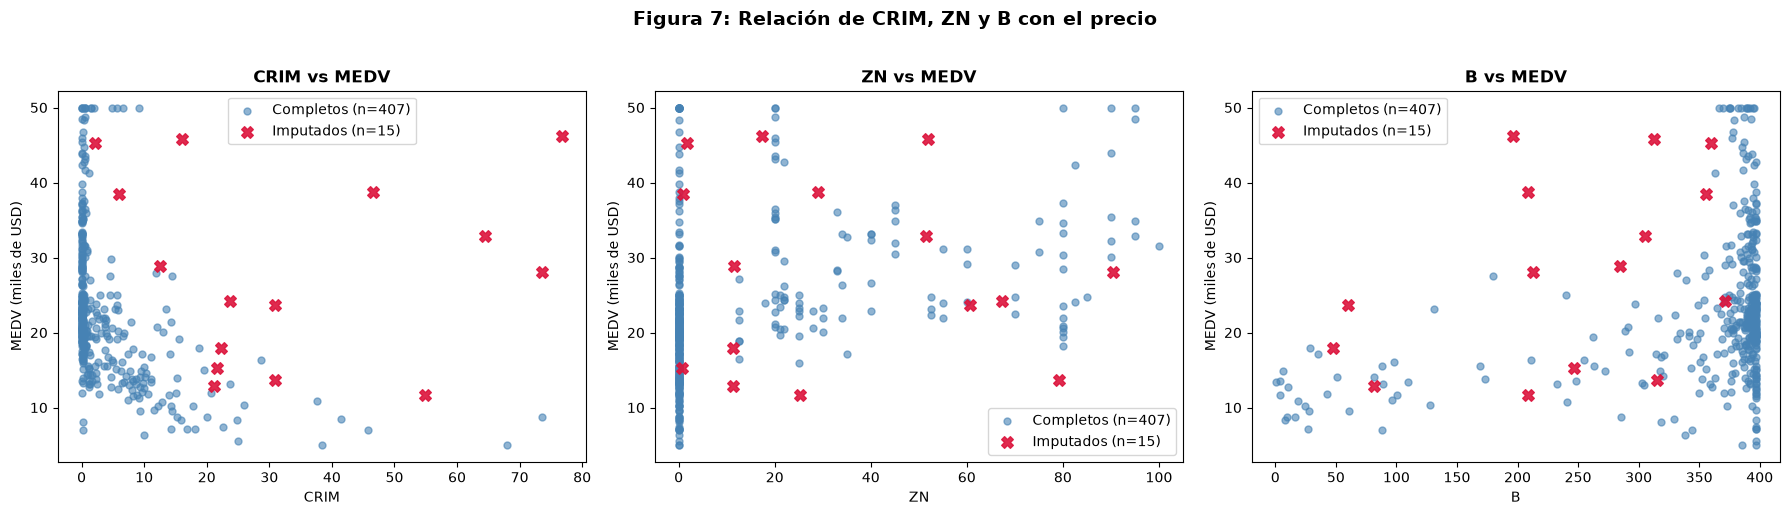

In [1246]:
# Identificamos qué registros del train fueron imputados
imputados_train = df_limpio.loc[X_train.index].isna().any(axis=1)
imputados_test = df_limpio.loc[X_test.index].isna().any(axis=1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col in zip(axes, ['CRIM', 'ZN', 'B']):
    ax.scatter(df_train.loc[~imputados_train, col], df_train.loc[~imputados_train, 'MEDV'],
               alpha=0.6, s=25, color='steelblue', label=f'Completos (n={(~imputados_train).sum()})')
    ax.scatter(df_train.loc[imputados_train, col], df_train.loc[imputados_train, 'MEDV'],
               alpha=0.9, s=70, color='crimson', marker='X',
               label=f'Imputados (n={imputados_train.sum()})')
    ax.set_xlabel(col)
    ax.set_ylabel('MEDV (miles de USD)')
    ax.set_title(f'{col} vs MEDV', fontweight='bold')
    ax.legend()

plt.suptitle(f'Figura {N_FIG}: Relación de CRIM, ZN y B con el precio',
             fontsize=14, fontweight='bold', y=1.02)
N_FIG += 1
plt.tight_layout()
plt.show()

In [1247]:
# Correlación con el precio dentro de cada grupo de registros
comparacion_grupos = pd.DataFrame({
    'Completos': df_train.loc[~imputados_train, ['CRIM', 'ZN', 'B']].corrwith(
        df_train.loc[~imputados_train, 'MEDV']),
    'Imputados': df_train.loc[imputados_train, ['CRIM', 'ZN', 'B']].corrwith(
        df_train.loc[imputados_train, 'MEDV']),
}).round(3)
display(comparacion_grupos)

,Completos,Imputados
CRIM,-0.415,0.025
ZN,0.387,-0.117
B,0.338,0.413


**Qué muestran los gráficos.**

- En `CRIM` vs `MEDV`, los registros completos forman una nube clara: casi todos se concentran en criminalidad baja, y las pocas zonas con criminalidad alta tienen sistemáticamente precios bajos. Los registros imputados, en cambio, aparecen desparramados por todo el eje horizontal, y varios combinan criminalidad muy alta con precios altos.
- En `ZN` vs `MEDV` pasa algo parecido: los registros completos con `ZN` alto son suburbios caros, mientras que varios imputados tienen `ZN` alto y precios bajos, o `ZN` alto junto con criminalidad alta.
- En `B`, los registros completos se concentran en el extremo superior del rango (por encima de 350), con una cola de valores bajos. Los imputados, en cambio, se reparten por la zona intermedia, donde los registros reales son escasos.

La tabla lo confirma: dentro del grupo imputado la correlación con el precio se desvanece o cambia de signo. `CRIM` pasa de −0,415 a +0,025 y `ZN` de +0,387 a −0,117, es decir, dejan de explicar el precio.

Es decir: los valores extremos de los registros completos son coherentes con el precio, y los de los registros imputados no. Esto justifica formalizar la sospecha con reglas verificables, que es lo que hacemos a continuación.

### 10.2 Patrones estructurales del dataset

Buscamos regularidades que se cumplan sin ninguna excepción en los registros completos del train y que además tengan una interpretación concreta del problema.

In [1248]:
# Registros completos (sin ningún valor imputado) de cada conjunto
train_completo = X_train.loc[~imputados_train].assign(MEDV=y_train[~imputados_train])
test_completo = X_test.loc[~imputados_test].assign(MEDV=y_test[~imputados_test])

print(f'Registros completos en train: {len(train_completo)} | imputados: {imputados_train.sum()}')
print(f'Registros completos en test:  {len(test_completo)} | imputados: {imputados_test.sum()}')
print()

print('Patrones observados en los registros completos del train:')
print('=' * 65)
alta_criminalidad = train_completo[train_completo.CRIM > 10]
print(f'P1) CRIM > 10  ->  RAD = 24 y TAX = 666')
print(f'    se cumple en {((alta_criminalidad.RAD == 24) & (alta_criminalidad.TAX == 666)).sum()} '
      f'de {len(alta_criminalidad)} registros')

grupo_24 = train_completo[train_completo.RAD == 24]
perfil_24 = ((grupo_24.ZN == 0) & (grupo_24.INDUS == 18.1) & (grupo_24.TAX == 666) & (grupo_24.PTRATIO == 20.2))
print(f'P2) RAD = 24   ->  ZN = 0, INDUS = 18.1, TAX = 666, PTRATIO = 20.2')
print(f'    se cumple en {perfil_24.sum()} de {len(grupo_24)} registros')

residenciales = train_completo[train_completo.ZN > 0]
print(f'P3) ZN > 0     ->  CRIM <= {residenciales.CRIM.max():.2f} y RAD <= {residenciales.RAD.max():.0f}')
print(f'    se cumple en {len(residenciales)} de {len(residenciales)} registros')

Registros completos en train: 407 | imputados: 15
Registros completos en test:  99 | imputados: 7

Patrones observados en los registros completos del train:
P1) CRIM > 10  ->  RAD = 24 y TAX = 666
    se cumple en 44 de 44 registros
P2) RAD = 24   ->  ZN = 0, INDUS = 18.1, TAX = 666, PTRATIO = 20.2
    se cumple en 109 de 109 registros
P3) ZN > 0     ->  CRIM <= 0.83 y RAD <= 8
    se cumple en 107 de 107 registros


**Interpretación.** Los tres patrones describen la estructura urbana de Boston:

- **P1.** La criminalidad alta aparece únicamente en un conjunto de zonas céntricas que comparten el mismo índice de accesibilidad (`RAD` = 24) y la misma tasa impositiva (`TAX` = 666).
- **P2.** Esas zonas son en realidad un mismo distrito: comparten exactamente la proporción de suelo industrial, la tasa impositiva y la relación alumno-maestro, y ninguna tiene suelo zonificado para lotes grandes.
- **P3.** Donde hay lotes residenciales grandes (`ZN` > 0), la criminalidad es baja y la accesibilidad a las autopistas radiales nunca es la del centro.

No son reglas arbitrarias: son consecuencia de cómo está organizada la ciudad, y por eso esperamos que se cumplan también fuera del conjunto con el que las obtuvimos.

### 10.3 Validación de los patrones en el conjunto de prueba

Un patrón derivado de unos datos siempre se cumple en esos datos. La prueba real es si se cumple en registros que no participaron de su construcción.

In [1249]:
def violaciones(datos):
    # Devuelve una serie booleana: True si el registro viola alguno de los tres patrones
    v1 = (datos.CRIM > 10) & ~((datos.RAD == 24) & (datos.TAX == 666))
    v2 = (datos.RAD == 24) & ~((datos.ZN == 0) & (datos.INDUS == 18.1) &
                               (datos.TAX == 666) & (datos.PTRATIO == 20.2))
    v3 = (datos.ZN > 0) & ((datos.CRIM > 1) | (datos.RAD > 8))
    return pd.DataFrame({'P1': v1, 'P2': v2, 'P3': v3})

viol_test = violaciones(test_completo)

print('Violaciones en los registros completos del conjunto de prueba:')
print('=' * 65)
print(viol_test.sum().to_string())
print(f'\nRegistros del test que violan algún patrón: {viol_test.any(axis=1).sum()} de {len(test_completo)}')

Violaciones en los registros completos del conjunto de prueba:
P1    0
P2    0
P3    0

Registros del test que violan algún patrón: 0 de 99


**Resultado.** Ninguno de los registros completos del conjunto de prueba viola los patrones. Las reglas no son un artefacto del conjunto con el que se construyeron: describen el dataset en general.

### 10.4 Regla de integridad de formato

Agregamos una verificación adicional que no depende de las relaciones entre variables, sino de cómo fue registrado cada dato. Cada variable del dataset tiene una precisión fija: `TAX` y `RAD` son enteros, `AGE` y `PTRATIO` tienen un decimal, `INDUS` y `LSTAT` tienen dos. Un valor con quince decimales no proviene de un censo.

Releemos el archivo como texto para ver los valores tal como fueron escritos, sin que pandas los convierta.

In [1250]:
df_texto = pd.read_csv("house-prices-tp.csv", dtype=str)

def cantidad_decimales(serie):
    # "6.85012281" -> 8 decimales ; "24.0" -> 0 decimales ; NaN -> 0
    return serie.str.split(".").str[1].str.rstrip("0").str.len().fillna(0)

# Precisión de cada columna en los registros completos del train
indices_completos = train_completo.index
precision = {col: int(cantidad_decimales(df_texto.loc[indices_completos, col]).max()) for col in df.columns}
print('Decimales que usa cada columna en los registros completos del train:')
print(precision)

anomalos = pd.DataFrame({col: cantidad_decimales(df_texto[col]) > precision[col] for col in df.columns})
formato_anomalo = anomalos.sum(axis=1) > 0

print()
print(f'Registros con algún valor fuera de esa precisión:')
print(f'  Completos del train: {formato_anomalo.loc[indices_completos].sum()} de {len(indices_completos)}')
print(f'  Completos del test:  {formato_anomalo.loc[test_completo.index].sum()} de {len(test_completo)}')

Decimales que usa cada columna en los registros completos del train:
{'CRIM': 5, 'ZN': 1, 'INDUS': 2, 'CHAS': 0, 'NOX': 4, 'RM': 3, 'AGE': 1, 'DIS': 4, 'RAD': 0, 'TAX': 0, 'PTRATIO': 1, 'B': 2, 'LSTAT': 2, 'MEDV': 1}

Registros con algún valor fuera de esa precisión:
  Completos del train: 0 de 407
  Completos del test:  0 de 99


### 10.5 Evaluación de los registros imputados

In [1251]:
# Aplicamos los patrones y la regla de formato a los registros imputados
imputados = pd.concat([X_train.loc[imputados_train].assign(MEDV=y_train[imputados_train]),
                       X_test.loc[imputados_test].assign(MEDV=y_test[imputados_test])]).sort_index()

viol_imputados = violaciones(imputados)
viol_imputados['Formato'] = formato_anomalo.loc[imputados.index]
viol_imputados['Alguna'] = viol_imputados.any(axis=1)

print('Registros imputados que violan cada regla:')
print('=' * 55)
print(viol_imputados[['P1', 'P2', 'P3', 'Formato']].sum().to_string())
print()
print(f'Registros imputados que violan al menos una regla: '
      f'{viol_imputados["Alguna"].sum()} de {len(imputados)}')

resumen = imputados[['CRIM', 'ZN', 'INDUS', 'RAD', 'TAX', 'PTRATIO', 'MEDV']].round(2)
resumen['reglas violadas'] = viol_imputados[['P1', 'P2', 'P3', 'Formato']].apply(
    lambda f: ', '.join(f.index[f]), axis=1)
display(resumen)

Registros imputados que violan cada regla:
P1         19
P2         13
P3         22
Formato    22

Registros imputados que violan al menos una regla: 22 de 22


,CRIM,ZN,INDUS,RAD,TAX,PTRATIO,MEDV,reglas violadas
14,30.99,60.71,8.83,6.0,621.33,16.63,23.68,"P1, P3, Formato"
23,73.61,90.43,12.74,24.0,540.76,21.29,28.13,"P1, P2, P3, Formato"
66,16.73,57.35,3.05,5.0,260.01,16.87,30.09,"P1, P3, Formato"
128,21.21,11.24,13.61,5.0,433.58,12.72,12.94,"P1, P3, Formato"
158,18.85,16.03,16.68,24.0,588.80,18.36,49.00,"P1, P2, P3, Formato"
172,48.33,12.31,25.40,24.0,521.61,15.58,14.44,"P1, P2, P3, Formato"
203,2.09,1.67,3.77,5.0,592.64,15.35,45.28,"P3, Formato"
230,23.79,67.38,21.01,24.0,666.00,20.18,24.24,"P2, P3, Formato"
264,38.61,59.56,15.55,24.0,593.20,18.88,48.85,"P1, P2, P3, Formato"
268,6.04,0.83,14.57,4.0,280.68,19.16,38.52,"P3, Formato"


In [1252]:
# ¿Las incoherencias vienen de los valores que imputamos o de los que ya estaban en el archivo?
# Miramos P3 (ZN > 0 con CRIM > 1), que es la regla que más registros viola y que sólo
# involucra dos variables: ZN y CRIM.
originales = df_limpio.loc[imputados.index]
viola_p3 = viol_imputados.index[viol_imputados['P3']]

ambas_observadas = originales.loc[viola_p3, ['ZN', 'CRIM']].notna().all(axis=1)

print('Registros que violan P3 (ZN > 0 con criminalidad alta):', len(viola_p3))
print('=' * 65)
print(f'  Con ZN y CRIM ya presentes en el archivo (no imputadas): {ambas_observadas.sum()}')
print(f'  Con alguna de las dos imputada por nosotros:             {(~ambas_observadas).sum()}')
print()
print('Detalle de los valores originales de esos registros:')
display(originales.loc[viola_p3, ['ZN', 'CRIM', 'RAD', 'TAX']].head(10))

Registros que violan P3 (ZN > 0 con criminalidad alta): 22
  Con ZN y CRIM ya presentes en el archivo (no imputadas): 12
  Con alguna de las dos imputada por nosotros:             10

Detalle de los valores originales de esos registros:


,ZN,CRIM,RAD,TAX
14,60.711549,30.986519,NaN,621.330711
23,90.434661,73.605747,NaN,NaN
66,57.349461,NaN,NaN,260.006282
128,NaN,NaN,NaN,433.579295
158,16.026020,NaN,NaN,NaN
172,12.306287,48.331901,NaN,NaN
203,NaN,2.087555,NaN,592.638217
230,67.378344,23.785283,NaN,NaN
264,59.561339,38.608079,NaN,593.195516
268,NaN,NaN,NaN,280.681821


**Resultado.** Los 22 registros imputados violan al menos una regla, y la mayoría viola varias. Algunos ejemplos de lo que eso significa:

- El registro 14 tiene `CRIM` = 30,99 y `ZN` = 60,7: una zona con el 60% del suelo zonificado para lotes residenciales grandes y, al mismo tiempo, una criminalidad que en el dataset sólo aparece en el centro, donde `ZN` vale siempre 0.
- El registro 158 tiene `CRIM` = 26,96 y `MEDV` = 49,0: prácticamente la vivienda más cara del dataset en una de las zonas más peligrosas.
- El registro 230 tiene `RAD` = 24 y `TAX` = 666, pero `ZN` = 67,4, cuando todas las zonas de ese distrito tienen `ZN` = 0.
- Los 22 registros violan además la regla de formato: contienen valores como `TAX` = 614,0731042774241, cuando `TAX` es un número entero en los 506 registros completos.

**Un punto importante sobre el origen de las incoherencias.** Podría objetarse que las contradicciones las introdujo nuestra imputación. La celda siguiente muestra que no es así: de los 21 registros que violan P3, en 12 las dos variables involucradas (`ZN` y `CRIM`) ya estaban presentes en el archivo, con esos valores. La imputación no creó la contradicción, y tampoco puede repararla: completa un registro cuyos valores observados ya eran incompatibles entre sí.

### 10.6 Decisión

Los registros imputados no superan el control de coherencia: contienen combinaciones de valores que no existen en ningún registro completo del dataset, ni en train ni en test, y presentan valores registrados con una precisión que no corresponde al resto del archivo.

Imputar sirve para completar observaciones válidas a las que les falta información. No sirve para reparar observaciones cuyos valores presentes ya son inválidos. Por eso eliminamos los registros que no superan el control.

Es importante notar el orden del razonamiento: no los descartamos por sospecha previa, sino porque aplicamos los criterios de calidad habituales, los imputamos con los métodos correspondientes a cada tipo de variable y, al validar el resultado, comprobamos que son incompatibles con la estructura del dataset.

In [1253]:
descartar = viol_imputados.index[viol_imputados['Alguna']]

X_train = X_train.drop(index=descartar, errors='ignore')
y_train = y_train.drop(index=descartar, errors='ignore')
X_test = X_test.drop(index=descartar, errors='ignore')
y_test = y_test.drop(index=descartar, errors='ignore')

print('Dataset final:')
print('=' * 55)
print(f'  Registros descartados por el control de coherencia: {len(descartar)}')
print(f'  X_train: {X_train.shape}   y_train: {y_train.shape}')
print(f'  X_test:  {X_test.shape}   y_test:  {y_test.shape}')
print(f'  Total:   {len(X_train) + len(X_test)} registros')
print()
print('Verificación final:')
print(f'  Valores faltantes:        {X_train.isna().sum().sum() + X_test.isna().sum().sum()}')
print(f'  Registros duplicados:     {pd.concat([X_train, X_test]).duplicated().sum()}')
print(f'  Valores de RAD:           {sorted(pd.concat([X_train, X_test])["RAD"].unique())}')
print(f'  Valores de CHAS:          {sorted(pd.concat([X_train, X_test])["CHAS"].unique())}')
print(f'  Violaciones de patrones:  '
      f'{violaciones(X_train.assign(MEDV=y_train)).any(axis=1).sum() + violaciones(X_test.assign(MEDV=y_test)).any(axis=1).sum()}')

Dataset final:
  Registros descartados por el control de coherencia: 22
  X_train: (407, 13)   y_train: (407,)
  X_test:  (99, 13)   y_test:  (99,)
  Total:   506 registros

Verificación final:
  Valores faltantes:        0
  Registros duplicados:     0
  Valores de RAD:           [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(7.0), np.float64(8.0), np.float64(24.0)]
  Valores de CHAS:          [np.float64(0.0), np.float64(1.0)]
  Violaciones de patrones:  0


---

## 11. Efecto de la eliminación sobre el análisis exploratorio

Repetimos ahora las mediciones del análisis exploratorio sobre el dataset depurado y las comparamos con las de las secciones 6 a 9, que se calcularon con los 422 registros del train antes del control de coherencia. El objetivo es verificar que la eliminación mejora efectivamente la calidad del análisis, y no simplemente que reduce el tamaño del conjunto.

In [1254]:
# Guardamos el análisis previo y recalculamos el DataFrame de trabajo ya depurado
df_train_inicial = df_train.copy()          # 422 registros, antes del control de coherencia
df_train = X_train.assign(MEDV=y_train)     # 407 registros, después

print(f'Registros antes del control:   {len(df_train_inicial)}')
print(f'Registros después del control: {len(df_train)}')

Registros antes del control:   422
Registros después del control: 407


### 11.1 Relación de las variables con el precio

El objetivo del trabajo es predecir `MEDV` a partir de las demás variables, así que la medida más relevante de la calidad del dataset es cuán nítida es la relación de cada variable con el precio.

In [1255]:
corr_antes = df_train_inicial.corr()['MEDV'].drop('MEDV')
corr_despues = df_train.corr()['MEDV'].drop('MEDV')

comparacion_corr = pd.DataFrame({
    'Antes (422 registros)': corr_antes.round(3),
    'Después (407 registros)': corr_despues.round(3),
})
comparacion_corr['Cambio en |r|'] = (corr_despues.abs() - corr_antes.abs()).round(3)
display(comparacion_corr.sort_values('Cambio en |r|', ascending=False))

print(f"Variables cuya relación con el precio se fortalece: "
      f"{(comparacion_corr['Cambio en |r|'] > 0).sum()} de {len(comparacion_corr)}")

,Antes (422 registros),Después (407 registros),Cambio en |r|
CRIM,-0.238,-0.415,0.177
LSTAT,-0.653,-0.748,0.095
RM,0.626,0.713,0.087
INDUS,-0.446,-0.502,0.056
NOX,-0.389,-0.446,0.056
PTRATIO,-0.487,-0.524,0.037
RAD,-0.348,-0.381,0.033
B,0.305,0.338,0.033
DIS,0.252,0.280,0.029
TAX,-0.449,-0.473,0.024


Variables cuya relación con el precio se fortalece: 12 de 13


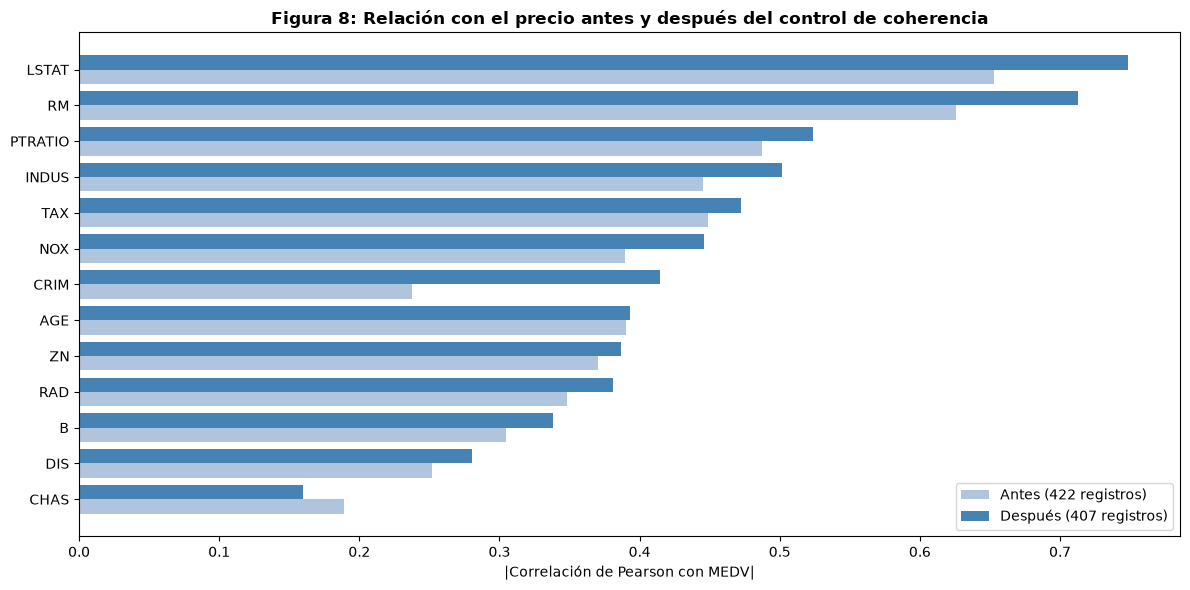

In [1256]:
orden = corr_despues.abs().sort_values().index

fig, ax = plt.subplots(figsize=(12, 6))
posiciones = np.arange(len(orden))
ax.barh(posiciones - 0.2, corr_antes[orden].abs(), height=0.4,
        label='Antes (422 registros)', color='lightsteelblue')
ax.barh(posiciones + 0.2, corr_despues[orden].abs(), height=0.4,
        label='Después (407 registros)', color='steelblue')
ax.set_yticks(posiciones, orden)
ax.set_xlabel('|Correlación de Pearson con MEDV|')
ax.set_title(f'Figura {N_FIG}: Relación con el precio antes y después del control de coherencia',
             fontweight='bold')
N_FIG += 1
ax.legend()
plt.tight_layout()
plt.show()

**Resultado.** La relación con el precio se fortalece en 12 de las 13 variables. Los casos más notorios:

| Variable | Antes | Después |
|---|---|---|
| `CRIM` | −0,238 | **−0,415** |
| `LSTAT` | −0,653 | **−0,748** |
| `RM` | +0,626 | **+0,713** |
| `NOX` | −0,389 | **−0,446** |

El salto de `CRIM` es el más grande, y era previsible: los registros eliminados eran justamente los que combinaban criminalidad alta con precios altos, es decir, los que contradecían la relación. Al sacarlos, la relación real queda a la vista.

La única variable que baja es `CHAS` (de 0,189 a 0,160), que es binaria y tiene la correlación más débil de todas; el cambio está dentro de lo esperable al quitar 15 registros.

### 11.2 Estructura entre las variables

In [1257]:
print('Colinealidad del par RAD - TAX:')
print('=' * 55)
print(f'  Antes:   {df_train_inicial[["RAD", "TAX"]].corr().iloc[0, 1]:.3f}')
print(f'  Después: {df_train[["RAD", "TAX"]].corr().iloc[0, 1]:.3f}')
print()

# Recalculamos los patrones estructurales sobre el dataset depurado
print('Patrones estructurales en el dataset depurado:')
print(f'  Registros que violan algún patrón: {violaciones(df_train).any(axis=1).sum()} de {len(df_train)}')

Colinealidad del par RAD - TAX:
  Antes:   0.886
  Después: 0.907

Patrones estructurales en el dataset depurado:
  Registros que violan algún patrón: 0 de 407


**Resultado.** La colinealidad entre `RAD` y `TAX` pasa de 0,886 a 0,907: la estructura del dataset se vuelve más nítida. No es un problema, es una señal de que el grupo de zonas céntricas vuelve a comportarse como un bloque homogéneo, que es lo que efectivamente es.

### 11.3 Distribuciones

In [1258]:
resumen_dist = []
for col in ['CRIM', 'ZN', 'B']:
    fila = {'Variable': col}
    for etiqueta, datos in [('antes', df_train_inicial), ('después', df_train)]:
        q1, q3 = datos[col].quantile(0.25), datos[col].quantile(0.75)
        iqr = q3 - q1
        outliers = ((datos[col] < q1 - 1.5 * iqr) | (datos[col] > q3 + 1.5 * iqr)).sum()
        fila[f'sesgo {etiqueta}'] = datos[col].skew()
        fila[f'outliers IQR {etiqueta}'] = outliers
    resumen_dist.append(fila)

display(pd.DataFrame(resumen_dist).set_index('Variable').round(2))

,sesgo antes,outliers IQR antes,sesgo después,outliers IQR después
Variable,,,,
CRIM,4.16,51,4.63,56
ZN,2.05,46,2.17,58
B,-2.69,69,-2.94,64


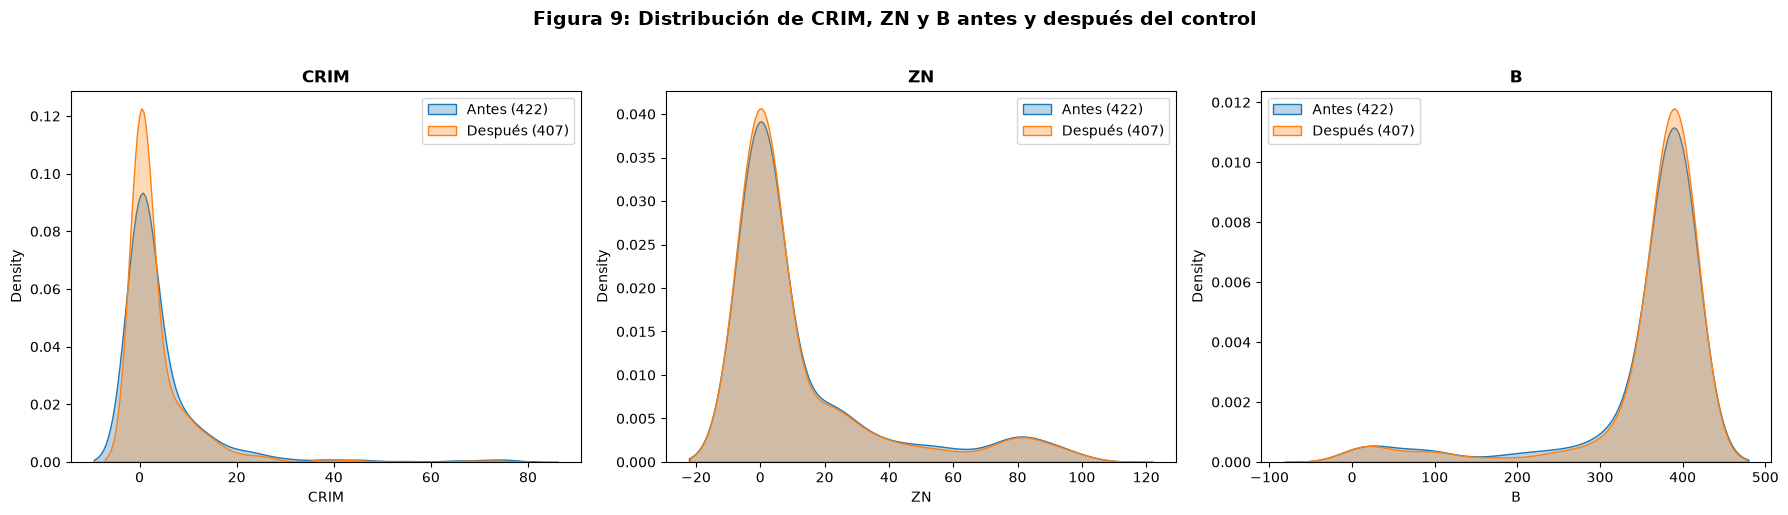

In [1259]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col in zip(axes, ['CRIM', 'ZN', 'B']):
    sns.kdeplot(df_train_inicial[col], ax=ax, label='Antes (422)', fill=True, alpha=0.3)
    sns.kdeplot(df_train[col], ax=ax, label='Después (407)', fill=True, alpha=0.3)
    ax.set_title(col, fontweight='bold')
    ax.legend()

plt.suptitle(f'Figura {N_FIG}: Distribución de CRIM, ZN y B antes y después del control',
             fontsize=14, fontweight='bold', y=1.02)
N_FIG += 1
plt.tight_layout()
plt.show()

**Resultado.** El sesgo aumenta (en `CRIM` pasa de +4,16 a +4,63) y la cantidad de outliers por el criterio IQR también (`CRIM` pasa de 51 a 56). Visto aisladamente parecería que el dataset empeoró, pero es exactamente lo contrario.

Los registros eliminados tenían valores repartidos de forma pareja a lo largo del rango de cada variable, en vez de seguir su forma real. En el gráfico se ve que rellenaban artificialmente la zona central de `CRIM` y de `B`, donde casi no hay registros reales. Ese relleno hacía que la distribución pareciera menos asimétrica de lo que es y que los límites del criterio IQR se corrieran, ocultando parte de los valores extremos legítimos.

Al eliminarlos, la distribución vuelve a ser la que realmente tiene el fenómeno: la criminalidad en Boston es muy baja en la mayoría de las zonas y muy alta en unas pocas del centro. Esa asimetría no es un defecto del dataset, es la característica del problema.

**Conclusión del análisis comparativo.** La eliminación no mejora las distribuciones marginales, y no tenía por qué hacerlo. Lo que mejora es lo que importa para el objetivo del trabajo: la relación entre las variables y el precio, que se fortalece en 12 de 13 casos, y la coherencia interna del dataset, que pasa a no tener ninguna violación de los patrones estructurales.

---

## 12. Transformación logarítmica de variables asimétricas

`CRIM` y `B` son las variables más asimétricas del dataset (sesgos de +5,16 y −2,88). Una práctica habitual es aplicarles una transformación logarítmica para comprimir las colas.

Como `CRIM` tiene sesgo positivo, se transforma directamente con `log1p` (que a diferencia de `log` no se indefine en 0). `B` tiene sesgo negativo, así que primero se refleja (`max - B`) y después se aplica el logaritmo. El valor de reflexión se calcula solo con el conjunto de entrenamiento, para no introducir información del test.

Las transformaciones se guardan en variables nuevas (`X_train_log`, `X_test_log`) en lugar de pisar `X_train` y `X_test`: así la celda se puede volver a ejecutar sin aplicar el logaritmo dos veces, y podemos comparar las dos versiones.

In [1260]:
# Transformación de las variables con sesgo fuerte.
# Guardamos el resultado en variables nuevas para no modificar X_train / X_test.
X_train_log = X_train.copy()
X_test_log = X_test.copy()

X_train_log['CRIM'] = np.log1p(X_train_log['CRIM'])
X_test_log['CRIM'] = np.log1p(X_test_log['CRIM'])

b_reflect_max = X_train['B'].max() + 1
X_train_log['B'] = np.log1p(b_reflect_max - X_train['B'])
X_test_log['B'] = np.log1p(b_reflect_max - X_test['B'])

print('Sesgo antes y después de la transformación (train):')
print('=' * 55)
for col in ['CRIM', 'B']:
    print(f'  {col:>5s}: {X_train[col].skew():+.3f}  ->  {X_train_log[col].skew():+.3f}')

Sesgo antes y después de la transformación (train):
   CRIM: +4.629  ->  +1.202
      B: -2.944  ->  +0.832


### 12.1 ¿La transformación mejora el modelo?

Comparamos una regresión lineal sobre las dos versiones, con la partición de test y también con validación cruzada de 5 pliegues sobre el train, que no depende de una sola partición.

In [1261]:
# Comparamos las dos versiones con una regresión lineal.
# Nota: el escalado no afecta a la regresión lineal por mínimos cuadrados (es una transformación
# afín), así que esta comparación aísla el efecto de la transformación logarítmica.
comparacion_transformacion = []

for nombre, A_train, A_test in [('Sin transformar', X_train, X_test),
                                ('Con log(CRIM) y log(B reflejada)', X_train_log, X_test_log)]:
    modelo = LinearRegression().fit(A_train, y_train)
    rmse_cv = cross_val_score(LinearRegression(), A_train, y_train,
                               cv=KFold(5, shuffle=True, random_state=RANDOM_STATE),
                               scoring='neg_root_mean_squared_error').mean()
    comparacion_transformacion.append({
        'Versión': nombre,
        'R2 train': modelo.score(A_train, y_train),
        'R2 test': modelo.score(A_test, y_test),
        'RMSE test': np.sqrt(mean_squared_error(y_test, modelo.predict(A_test))),
        'RMSE validación cruzada (train)': rmse_cv
    })

pd.DataFrame(comparacion_transformacion).round(4)

,Versión,R2 train,R2 test,RMSE test,RMSE validación cruzada (train)
0,Sin transformar,0.7555,0.6377,4.7521,-4.874
1,Con log(CRIM) y log(B reflejada),0.7484,0.6010,4.9867,-4.943


**Decisión.** La transformación empeora el ajuste con los dos criterios: el RMSE de test sube y el RMSE de validación cruzada también. Por eso los modelos se entrenan con las variables sin transformar.

No descartamos el trabajo hecho: conservamos `X_train_log` para comprobar si sirve de algo mas adelante

---

## 13. Escalado robusto

Escalamos las variables para que todas tengan un rango comparable. Usamos `RobustScaler`, que resta la mediana y divide por el rango intercuartílico:


Elegimos este escalador, y no `StandardScaler`, para ser coherentes con la decisión de la sección 9: conservamos los outliers, y la mediana y el IQR son medidas que no se ven arrastradas por ellos.

In [1262]:
# Ajustamos el escalador solo con el conjunto de entrenamiento
scaler = RobustScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

verificacion = pd.DataFrame({
    'Mediana': X_train_scaled.median(),
    'IQR': X_train_scaled.quantile(0.75) - X_train_scaled.quantile(0.25),
    'Min': X_train_scaled.min(),
    'Max': X_train_scaled.max()
}).round(4)

print('Verificación del escalado robusto (train):')
print('=' * 55)
print(verificacion)
print()
print('Mediana = 0 e IQR = 1 en todas las variables, salvo CHAS: al ser binaria su IQR es 0')

Verificación del escalado robusto (train):
         Mediana  IQR      Min      Max
CRIM         0.0  1.0  -0.0699  20.2685
ZN           0.0  1.0   0.0000   8.0000
INDUS        0.0  1.0  -0.7295   1.3787
CHAS         0.0  0.0   0.0000   1.0000
NOX          0.0  1.0  -0.8947   1.9474
RM           0.0  1.0  -3.4593   3.3407
AGE          0.0  1.0  -1.4332   0.4563
DIS          0.0  1.0  -0.6753   2.9404
RAD          0.0  1.0  -0.2000   0.9500
TAX          0.0  1.0  -0.3676   0.9794
PTRATIO      0.0  1.0  -1.9394   0.9091
B            0.0  1.0 -19.1022   0.2905
LSTAT        0.0  1.0  -0.9776   2.6083

Mediana = 0 e IQR = 1 en todas las variables, salvo CHAS: al ser binaria su IQR es 0


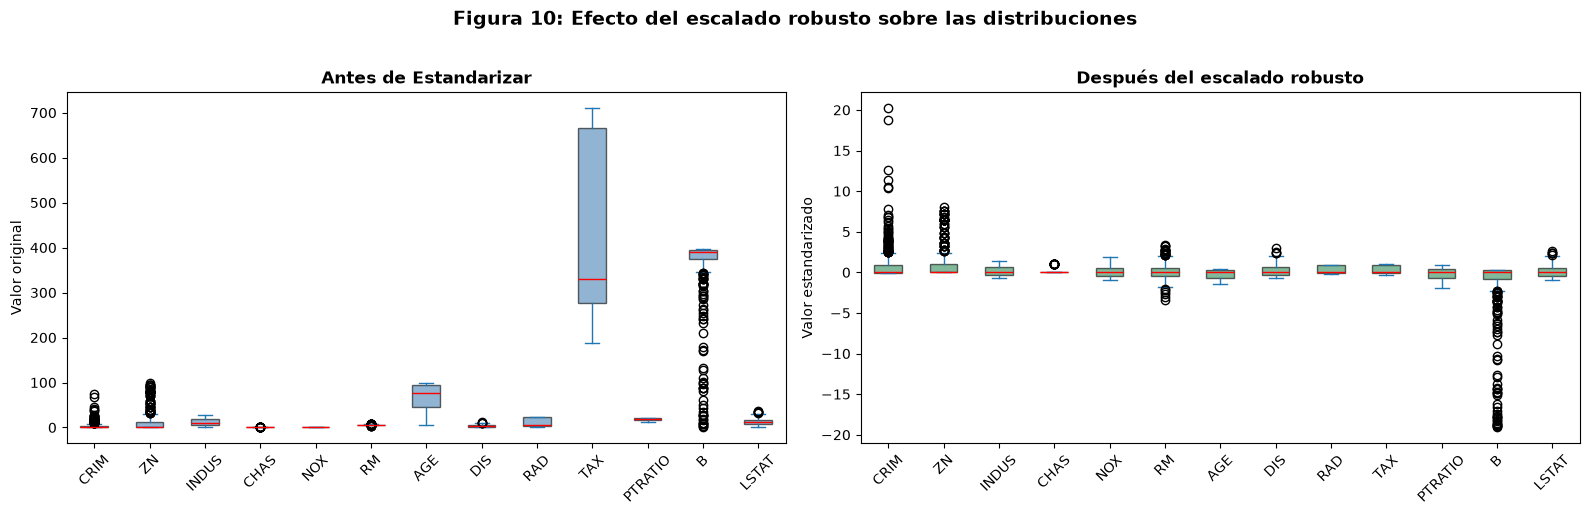

In [1263]:
# Efecto del escalado robusto sobre las distribuciones
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

X_train.plot.box(ax=axes[0], patch_artist=True,
                 boxprops=dict(facecolor='steelblue', alpha=0.6), medianprops=dict(color='red'))
axes[0].set_title('Antes de Estandarizar', fontweight='bold')
axes[0].set_ylabel('Valor original')
axes[0].tick_params(axis='x', rotation=45)

X_train_scaled.plot.box(ax=axes[1], patch_artist=True,
                        boxprops=dict(facecolor='seagreen', alpha=0.6), medianprops=dict(color='red'))
axes[1].set_title('Después del escalado robusto', fontweight='bold')
axes[1].set_ylabel('Valor estandarizado')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle(f'Figura {N_FIG}: Efecto del escalado robusto sobre las distribuciones', fontsize=14, fontweight='bold', y=1.02)
N_FIG += 1
plt.tight_layout()
plt.show()

La Figura 12 muestra que antes del escalado las variables tienen rangos muy distintos: `TAX` y `B` (valores de cientos) aplastan visualmente al resto. Después del escalado robusto todas quedan centradas en 0 y con un rango intercuartílico de 1, de modo que ninguna domina a las demás por su magnitud. Los valores extremos siguen presentes, porque decidimos conservarlos.

---

## 14. Regresión lineal múltiple

La regresión lineal múltiple modela el precio como una combinación lineal de las features:

### Métricas elegidas

| Métrica | Qué mide | Por qué la usamos |
|---|---|---|
| **$R^2$** | Proporción de la varianza del precio explicada por el modelo | Es adimensional, sirve para comparar modelos entre sí |
| **RMSE** | Error típico, en miles de dólares. Penaliza más los errores grandes | Está en las unidades del problema y es interpretable |
| **MAE** | Error absoluto medio, en miles de dólares | Es más robusto que el RMSE ante valores extremos; comparándolo con el RMSE se ve cuánto pesan los errores grandes |

**Descartamos MAPE.** Al ser un error porcentual divide por el valor real, y `MEDV` toma valores tan bajos como 5 (mil dólares): un error de 2 sobre una vivienda de 5 pesa un 40%, mientras que el mismo error sobre una de 50 pesa un 4%. La métrica quedaría dominada por las viviendas más baratas.

In [1264]:
# Función que evalúa un modelo ya entrenado sobre train y test, y devuelve una fila de resultados.
# La usamos con todos los modelos para poder compararlos en una misma tabla.
def evaluar_modelo(nombre, modelo, X_tr=None, X_te=None):
    X_tr = X_train_scaled if X_tr is None else X_tr
    X_te = X_test_scaled if X_te is None else X_te

    pred_train = modelo.predict(X_tr)
    pred_test = modelo.predict(X_te)

    return {
        'Modelo': nombre,
        'R2 train': r2_score(y_train, pred_train),
        'R2 test': r2_score(y_test, pred_test),
        'RMSE train': np.sqrt(mean_squared_error(y_train, pred_train)),
        'RMSE test': np.sqrt(mean_squared_error(y_test, pred_test)),
        'MAE train': mean_absolute_error(y_train, pred_train),
        'MAE test': mean_absolute_error(y_test, pred_test),
    }

# Lista donde acumulamos los resultados de todos los modelos de la consigna 4
resultados_modelos = []

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

resultados_modelos.append(evaluar_modelo('Regresión lineal (OLS)', lr))
pd.DataFrame(resultados_modelos).round(4)

,Modelo,R2 train,R2 test,RMSE train,RMSE test,MAE train,MAE test
0,Regresión lineal (OLS),0.7555,0.6377,4.6761,4.7521,3.3236,3.2692


Ordenada al origen (intercepto): 23.146

Coeficientes ordenados por magnitud:
RAD        6.333
LSTAT     -5.326
TAX       -5.006
DIS       -4.887
PTRATIO   -3.245
NOX       -3.231
RM         2.999
CHAS       2.066
ZN         0.602
CRIM      -0.335
INDUS      0.241
AGE       -0.238
B          0.172


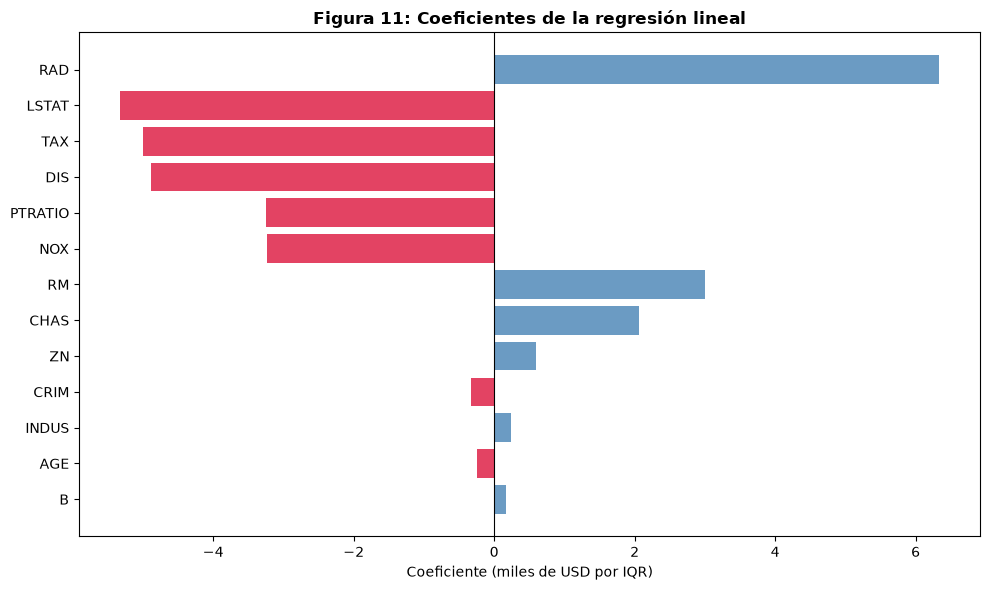

In [1265]:
# Coeficientes del modelo. Como las variables están escaladas, los coeficientes son comparables
# entre sí: indican cuánto cambia el precio (en miles de USD) por cada IQR de la variable.
coeficientes = pd.Series(lr.coef_, index=X_train_scaled.columns).sort_values(key=abs, ascending=False)

print(f'Ordenada al origen (intercepto): {lr.intercept_:.3f}')
print()
print('Coeficientes ordenados por magnitud:')
print(coeficientes.round(3).to_string())

fig, ax = plt.subplots(figsize=(10, 6))
colores = ['steelblue' if v > 0 else 'crimson' for v in coeficientes]
ax.barh(coeficientes.index[::-1], coeficientes.values[::-1], color=colores[::-1], alpha=0.8)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Coeficiente (miles de USD por IQR)')
ax.set_title(f'Figura {N_FIG}: Coeficientes de la regresión lineal', fontweight='bold')
N_FIG += 1
plt.tight_layout()
plt.show()

**Observación sobre los coeficientes.** Los signos son coherentes con el análisis exploratorio: `LSTAT` (población de menor estatus socioeconómico) y `PTRATIO` (alumnos por maestro) bajan el precio, mientras que `RM` (habitaciones) y `CHAS` (frente al río) lo suben.

Llama la atención el coeficiente de `RAD`, que es grande y positivo, cuando su correlación simple con el precio es negativa (−0,38 en la sección 8). No es un error: es el efecto de la colinealidad con `TAX` ($r = 0{,}91$). Cuando dos variables se mueven juntas, el modelo reparte el efecto entre ellas de forma inestable, y puede asignarle a una un coeficiente positivo grande y a la otra uno negativo grande que lo compensa. 

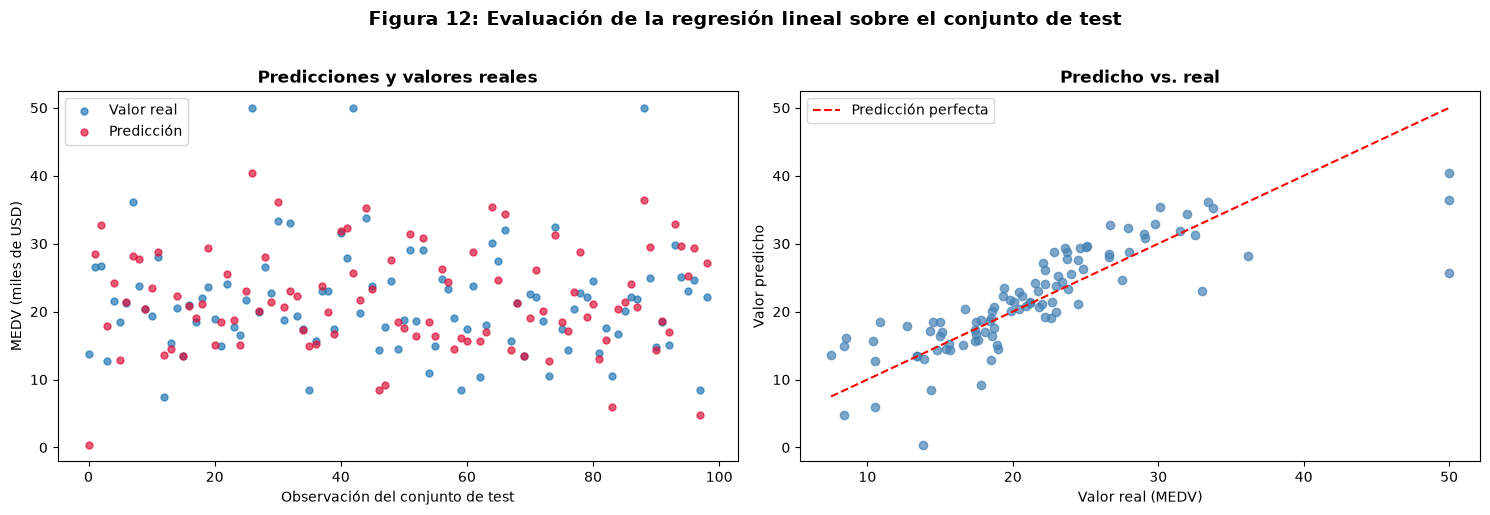

In [1266]:
# Comparación de las predicciones contra los valores reales
y_pred_test = lr.predict(X_test_scaled)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].scatter(range(len(y_test)), y_test, label='Valor real', alpha=0.7, s=25)
axes[0].scatter(range(len(y_test)), y_pred_test, label='Predicción', alpha=0.7, s=25, color='crimson')
axes[0].set_xlabel('Observación del conjunto de test')
axes[0].set_ylabel('MEDV (miles de USD)')
axes[0].set_title('Predicciones y valores reales', fontweight='bold')
axes[0].legend()

axes[1].scatter(y_test, y_pred_test, alpha=0.7, color='steelblue')
limites = [y_test.min(), y_test.max()]
axes[1].plot(limites, limites, 'r--', label='Predicción perfecta')
axes[1].set_xlabel('Valor real (MEDV)')
axes[1].set_ylabel('Valor predicho')
axes[1].set_title('Predicho vs. real', fontweight='bold')
axes[1].legend()

plt.suptitle(f'Figura {N_FIG}: Evaluación de la regresión lineal sobre el conjunto de test',
             fontsize=14, fontweight='bold', y=1.02)
N_FIG += 1
plt.tight_layout()
plt.show()

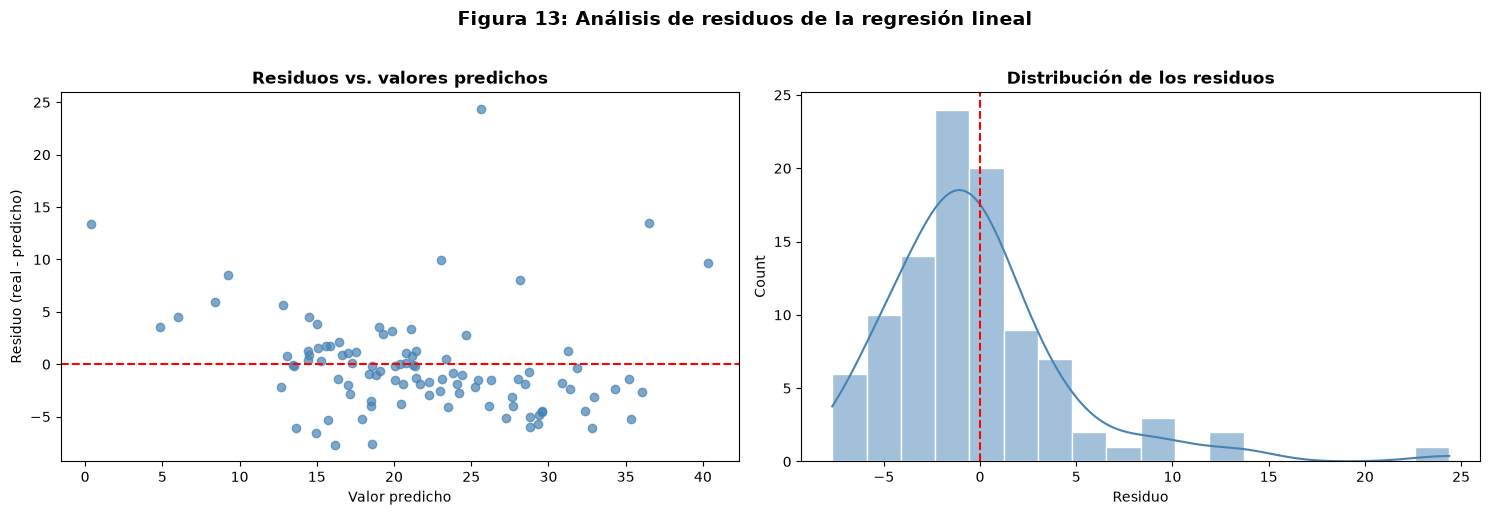

Media de los residuos: -0.228
Viviendas con MEDV = 50 en el test: 3
Residuo promedio en esas viviendas: 15.848


In [1267]:
# Análisis de residuos: residuo = valor real - predicción
residuos = y_test - y_pred_test

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].scatter(y_pred_test, residuos, alpha=0.7, color='steelblue')
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Valor predicho')
axes[0].set_ylabel('Residuo (real - predicho)')
axes[0].set_title('Residuos vs. valores predichos', fontweight='bold')

sns.histplot(residuos, kde=True, ax=axes[1], color='steelblue', edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_xlabel('Residuo')
axes[1].set_title('Distribución de los residuos', fontweight='bold')

plt.suptitle(f'Figura {N_FIG}: Análisis de residuos de la regresión lineal',
             fontsize=14, fontweight='bold', y=1.02)
N_FIG += 1
plt.tight_layout()
plt.show()

print(f'Media de los residuos: {residuos.mean():.3f}')
print(f'Viviendas con MEDV = 50 en el test: {(y_test == 50).sum()}')
print(f'Residuo promedio en esas viviendas: {residuos[y_test == 50].mean():.3f}')

**Observación sobre los residuos.** Los residuos se reparten alrededor de cero sin una forma marcada, lo que indica que la relación lineal es razonable para la mayor parte del rango.

Sin embargo, se ve el efecto de la censura de `MEDV` que documentamos en la sección 3.6: las viviendas registradas con el valor tope de 50 tienen residuos positivos grandes, es decir, el modelo las subestima. Es lo que anticipamos: su precio real era probablemente mayor a 50, pero el dataset lo truncó, y el modelo aprende de ese valor truncado.

---

## 15. Gradiente descendente


Usamos las tres implementaciones provistas por la cátedra, que se diferencian en cuántas muestras usan para calcular cada actualización de los pesos.

In [1268]:
def gradient_descent(X_train, y_train, X_val, y_val, lr=0.01, epochs=100, fig_num=None):
    """
    Entrena un modelo de regresión lineal mediante Gradient Descent.
    La función ajusta los pesos W de un modelo lineal de la forma:
        y_pred = X @ W

    utilizando el Error Cuadrático Medio (MSE) como función de costo.

    Parámetros
    ----------
    X_train :
      np.ndarray Matriz de características de entrenamiento de dimensiones (n, m), donde n es la cantidad de muestras y m la cantidad de variables.
    y_train :
      np.ndarray Vector de valores objetivo de entrenamiento de dimensiones (n, 1).
    X_val :
      np.ndarray Matriz de características de validación de dimensiones (p, m), donde p es la cantidad de muestras de validación.
    y_val :
      np.ndarray Vector de valores objetivo de validación de dimensiones (p, 1).
    lr :
      float, optional Tasa de aprendizaje utilizada para actualizar los pesos. Por defecto es 0.01.
    epochs :
      int, optional Cantidad de iteraciones del algoritmo de Gradient Descent. Por defecto es 100.

    Retorna
    -------
    np.ndarray Vector de pesos W de dimensiones (m + 1, 1), incluyendo el término independiente (bias).

    Proceso
    -------
    1. Se agrega una columna de unos a X_train y X_val para representar el término independiente (bias).
    2. Se inicializan aleatoriamente los pesos W.
    3. En cada época:
      - Se calcula la predicción sobre el conjunto de entrenamiento.
      - Se calcula el MSE de entrenamiento.
      - Se calcula la predicción sobre el conjunto de validación.
      - Se calcula el MSE de validación.
      - Se calcula el gradiente de la función de costo respecto de W.
      - Se actualizan los pesos utilizando la regla de Gradient Descent: W = W - lr * gradient
      4. Finalmente, se grafica la evolución del MSE de entrenamiento y validación a lo largo de las épocas.
        El gradiente utilizado corresponde a: ∇J(W) = -(2 / n) X.T (y - XW) donde J(W) es el Error Cuadrático Medio.
    """
    n = X_train.shape[0]
    m = X_train.shape[1]

    o = X_val.shape[0]

    # Poner columna de unos a las matrices X
    X_train = np.hstack((np.ones((n, 1)), X_train))
    X_val = np.hstack((np.ones((o, 1)), X_val))


    # Inicializar pesos aleatorios
    W = np.random.randn(m+1).reshape(m+1, 1)

    train_errors = []  # Para almacenar el error de entrenamiento en cada época
    test_errors = []   # Para almacenar el error de prueba en cada época

    for _ in range(epochs):
        # Calcular predicción y error de entrenamiento
        prediction_train = np.matmul(X_train, W)
        error_train = y_train - prediction_train
        #print(error_train)
        train_mse = np.mean(error_train ** 2)
        train_errors.append(train_mse)

        # Calcular predicción y error de prueba
        prediction_test = np.matmul(X_val, W)
        error_test = y_val - prediction_test
        test_mse = np.mean(error_test ** 2)
        test_errors.append(test_mse)

        # Calcular el gradiente y actualizar pesos
        grad_sum = np.sum(error_train * X_train, axis=0)
        grad_mul = -2/n * grad_sum  # 1xm
        gradient = np.transpose(grad_mul).reshape(-1, 1)  # mx1

        W = W - (lr * gradient)

    # Graficar errores de entrenamiento y prueba
    # Definir una figura
    plt.figure(figsize=(12, 6))
    # Plotear errores de entrenamiento
    plt.plot(train_errors, label='Error de entrenamiento')
    # Plotear errores de prueba
    plt.plot(test_errors, label='Error de validación')
    # Poner labels en los ejes
    plt.xlabel('Época')
    plt.ylabel('Error cuadrático medio')
    # Activar la leyenda
    plt.legend()
    # Poner titulo
    if fig_num is None:
      plt.title('Error de entrenamiento y validación vs iteraciones (GD)', fontweight='bold')
    else: 
      plt.title(f'Figura {fig_num}: Error de entrenamiento y validación vs iteraciones (GD)', fontweight='bold')
    # Terminar y mostrar gráfico
    plt.show()

    return W

In [1269]:
def stochastic_gradient_descent(X_train, y_train, X_test, y_test, lr=0.01, epochs=100, fig_num=None):
    """
    Entrena un modelo de regresión lineal mediante Stochastic Gradient Descent (SGD).

    La función ajusta los pesos W de un modelo lineal de la forma:

        y_pred = X @ W

    utilizando el Error Cuadrático Medio (MSE) como función de costo.

    A diferencia de Gradient Descent tradicional, que calcula el gradiente
    utilizando todas las muestras antes de actualizar los pesos, SGD actualiza
    los pesos después de procesar cada muestra individual.

    Parámetros
    ----------
    X_train : np.ndarray
        Matriz de características de entrenamiento de dimensiones (n, m),
        donde n es la cantidad de muestras y m la cantidad de variables.

    y_train : np.ndarray
        Vector de valores objetivo de entrenamiento de dimensiones (n, 1).

    X_test : np.ndarray
        Matriz de características de prueba de dimensiones (p, m).

    y_test : np.ndarray
        Vector de valores objetivo de prueba de dimensiones (p, 1).

    lr : float, optional
        Tasa de aprendizaje utilizada para actualizar los pesos.
        Por defecto es 0.01.

    epochs : int, optional
        Cantidad de épocas de entrenamiento. En cada época se recorren
        todas las muestras de entrenamiento. Por defecto es 100.

    Retorna
    -------
    np.ndarray
        Vector de pesos W de dimensiones (m + 1, 1), incluyendo el
        término independiente (bias).

    Proceso
    -------
    1. Se agrega una columna de unos a X_train y X_test para incorporar
      el término independiente (bias).

    2. Se inicializan aleatoriamente los pesos W.

    3. En cada época se permutan aleatoriamente las muestras de entrenamiento
      para evitar que el orden de los datos afecte al proceso de aprendizaje.

    4. Para cada muestra de entrenamiento:
      - Se calcula la predicción.
      - Se calcula el error entre el valor real y la predicción.
      - Se calcula el error cuadrático de esa muestra.
      - Se calcula el gradiente respecto de los pesos.
      - Se actualizan inmediatamente los pesos.

    5. Después de cada actualización se calcula el MSE sobre el conjunto
      de prueba para observar la evolución del modelo.

    El gradiente utilizado para una muestra individual es:

        ∇J(W) = -2 * x_i.T * (y_i - x_i @ W)

    y la actualización de los pesos es:

        W = W - lr * ∇J(W)

    La principal diferencia respecto de Gradient Descent tradicional es que
    el gradiente se calcula y los pesos se actualizan utilizando una sola
    muestra por vez, en lugar de utilizar todo el conjunto de entrenamiento.
    """
    n = X_train.shape[0]
    m = X_train.shape[1]

    X_train = np.hstack((np.ones((n, 1)), X_train))
    X_test = np.hstack((np.ones((X_test.shape[0], 1)), X_test))

    W = np.random.randn(m + 1).reshape(-1, 1)

    train_errors = []
    test_errors = []

    for i in range(epochs):
        # Permutación aleatoria de los datos
        permutation = np.random.permutation(n)
        X_train = X_train[permutation]
        y_train = y_train[permutation]

        for j in range(n):
            # Obtener una muestra aleatoria de un solo dato para hacer SGD
            x_sample = X_train[j]
            y_sample = y_train[j][0]

            prediction = np.matmul(x_sample, W)
            error = y_sample - prediction
            train_mse = error ** 2
            train_errors.append(train_mse)

            prediction_test = np.matmul(X_test, W)
            error_test = y_test - prediction_test
            test_mse = np.mean(error_test ** 2)
            test_errors.append(test_mse)

            gradient = -2 * error * x_sample.T.reshape(-1, 1)

            W = W - (lr * gradient)


    plt.figure(figsize=(12, 6))
    plt.plot(train_errors, label='Error de entrenamiento')
    plt.plot(test_errors, label='Error de prueba')
    plt.xlabel('Iteración')
    plt.ylabel('Error cuadrático medio')
    plt.legend()
    if fig_num is None:
      plt.title('Error de entrenamiento y validación vs iteraciones (GD)', fontweight='bold')
    else: 
      plt.title(f'Figura {fig_num}: Error de entrenamiento y validación vs iteraciones (GD)', fontweight='bold')    
    plt.show()

    return W

In [1270]:
def mini_batch_gradient_descent(X_train, y_train, X_test, y_test, lr=0.01, epochs=100, batch_size=11, fig_num=None):
    """
    Entrena un modelo de regresión lineal mediante Mini-Batch Gradient Descent.

    La función ajusta los pesos W de un modelo lineal de la forma:

        y_pred = X @ W

    utilizando el Error Cuadrático Medio (MSE) como función de costo.

    Mini-Batch Gradient Descent combina las características de Gradient Descent
    tradicional y Stochastic Gradient Descent (SGD): en lugar de calcular el
    gradiente utilizando todo el conjunto de entrenamiento o una única muestra,
    calcula el gradiente utilizando pequeños lotes (mini-batches) de datos.

    Parámetros
    ----------
    X_train : np.ndarray
        Matriz de características de entrenamiento de dimensiones (n, m),
        donde n es la cantidad de muestras y m la cantidad de variables.

    y_train : np.ndarray
        Vector de valores objetivo de entrenamiento de dimensiones (n, 1).

    X_test : np.ndarray
        Matriz de características de prueba de dimensiones (p, m).

    y_test : np.ndarray
        Vector de valores objetivo de prueba de dimensiones (p, 1).

    lr : float, optional
        Tasa de aprendizaje utilizada para actualizar los pesos.
        Por defecto es 0.01.

    epochs : int, optional
        Cantidad de épocas de entrenamiento. En cada época se recorren
        todos los mini-batches del conjunto de entrenamiento.
        Por defecto es 100.

    batch_size : int, optional
        Cantidad de muestras utilizadas para calcular cada actualización
        de los pesos. Por defecto es 11.

    Retorna
    -------
    np.ndarray
        Vector de pesos W de dimensiones (m + 1, 1), incluyendo el
        término independiente (bias).

    Proceso
    -------
    1. Se agrega una columna de unos a X_train y X_test para incorporar
      el término independiente (bias).

    2. Se inicializan aleatoriamente los pesos W.

    3. En cada época se realiza una permutación aleatoria de las muestras
      de entrenamiento para evitar que el orden de los datos influya
      sistemáticamente en el aprendizaje.

    4. El conjunto de entrenamiento se divide en mini-batches de tamaño
      batch_size.

    5. Para cada mini-batch:
      - Se calcula la predicción:

            y_pred = X_batch @ W

      - Se calcula el error:

            error = y_batch - y_pred

      - Se calcula el MSE del mini-batch.
      - Se calcula el gradiente utilizando todas las muestras del
        mini-batch.
      - Se actualizan inmediatamente los pesos.

    6. Después de cada actualización se calcula el MSE sobre el conjunto
      de prueba para evaluar la evolución del modelo.

    El gradiente utilizado es:

        ∇J(W) = -(2 / batch_size) * X_batch.T @ (y_batch - X_batch @ W)

    y la actualización de los pesos es:

        W = W - lr * ∇J(W)

    La principal diferencia respecto de los otros métodos es el tamaño
    del conjunto utilizado para cada actualización:

        Gradient Descent:
            utiliza todas las muestras.

        Stochastic Gradient Descent:
            utiliza una única muestra.

        Mini-Batch Gradient Descent:
            utiliza un pequeño grupo de muestras.

    Por lo tanto, Mini-Batch Gradient Descent busca un equilibrio entre
    la estabilidad del gradiente calculado sobre todo el dataset y la
    velocidad y frecuencia de actualización característica de SGD.
    """
    n = X_train.shape[0]
    m = X_train.shape[1]

    X_train = np.hstack((np.ones((n, 1)), X_train))
    X_test = np.hstack((np.ones((X_test.shape[0], 1)), X_test))

    W = np.random.randn(m + 1).reshape(-1, 1)

    train_errors = []
    test_errors = []

    for i in range(epochs):

        # Permutación aleatoria de los datos
        permutation = np.random.permutation(n)
        X_train = X_train[permutation]
        y_train = y_train[permutation]


        for j in range(0, n, batch_size):
            # Obtener un lote (mini-batch) de datos
            x_batch = X_train[j:j+batch_size, :]
            y_batch = y_train[j:j+batch_size].reshape(-1, 1)

            prediction = np.matmul(x_batch, W)
            error = y_batch - prediction
            train_mse = np.mean(error ** 2)
            train_errors.append(train_mse)

            gradient = -2 * np.matmul(x_batch.T, error) / batch_size

            W = W - (lr * gradient)

            prediction_test = np.matmul(X_test, W)
            error_test = y_test - prediction_test
            test_mse = np.mean(error_test ** 2)
            test_errors.append(test_mse)

    plt.figure(figsize=(12, 6))
    plt.plot(train_errors, label='Error de entrenamiento')
    plt.plot(test_errors, label='Error de prueba')
    plt.xlabel('Iteración')
    plt.ylabel('Error cuadrático medio')
    plt.legend()
    if fig_num is None:
      plt.title('Error de entrenamiento y validación vs iteraciones (GD)', fontweight='bold')
    else: 
      plt.title(f'Figura {fig_num}: Error de entrenamiento y validación vs iteraciones (GD)', fontweight='bold')    
    plt.show()

    return W

### 15.1 Preparación de los datos

Obtenemos un conjunto de validación para poder graficar el error época a época, lo sacamos del conjunto de entrenamiento, nunca del test, que queda reservado para la evaluación final.

Como los pesos se inicializan al azar, fijamos la semilla antes de cada llamada para que los resultados sean reproducibles.

In [1271]:
# Separamos un conjunto de validación a partir del train (12,5% del train)
X_gd_train, X_gd_val, y_gd_train, y_gd_val = train_test_split(
    X_train, y_train, test_size=0.125, random_state=RANDOM_STATE)

scaler_gd = RobustScaler().fit(X_gd_train)

X_gd_train_np = X_gd_train.values
X_gd_val_np = X_gd_val.values
X_gd_train_scaled = scaler_gd.transform(X_gd_train)
X_gd_val_scaled = scaler_gd.transform(X_gd_val)
X_gd_test_scaled = scaler_gd.transform(X_test)

y_gd_train_np = y_gd_train.values.reshape(-1, 1)
y_gd_val_np = y_gd_val.values.reshape(-1, 1)
y_test_np = y_test.values.reshape(-1, 1)

print('Entrenamiento del gradiente descendente:', X_gd_train_np.shape)
print('Validación:                             ', X_gd_val_np.shape)
print('Test (reservado):                       ', X_gd_test_scaled.shape)


def predecir_con_pesos(X, W):
    # Agrega la columna de unos (bias) y multiplica por los pesos, igual que las funciones de la cátedra
    return np.hstack((np.ones((X.shape[0], 1)), X)) @ W

Entrenamiento del gradiente descendente: (356, 13)
Validación:                              (51, 13)
Test (reservado):                        (99, 13)


### 15.2 Efecto del escalado

Entrenamos primero con las variables sin escalar. Como `TAX` toma valores de cientos y `NOX` valores menores que 1, el gradiente queda dominado por las variables de mayor magnitud y hay que usar una tasa de aprendizaje diminuta para que el algoritmo no se dispare.

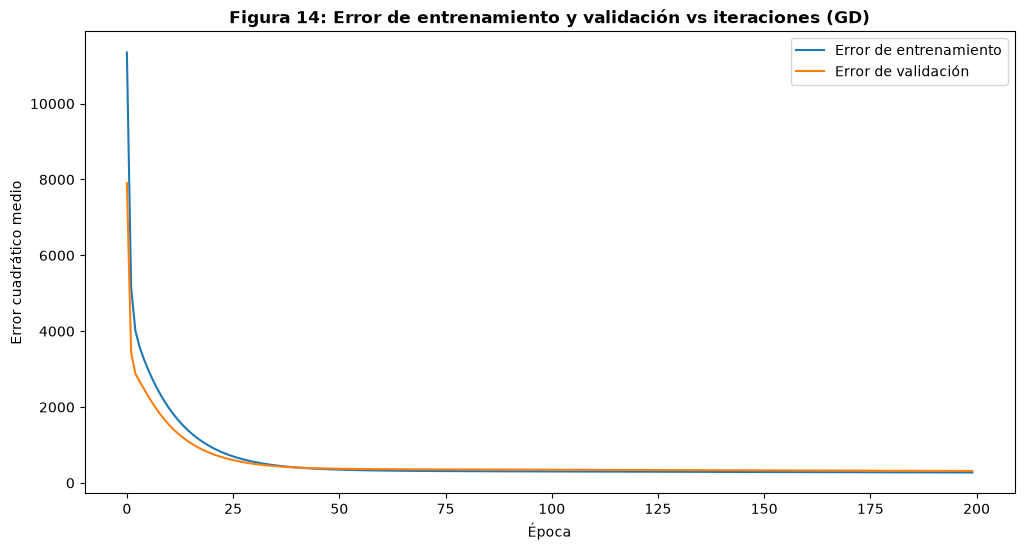

MSE de validación tras 200 épocas: 313.06


In [1272]:
# Sin escalar: sólo converge con una tasa de aprendizaje muy chica
np.random.seed(RANDOM_STATE)
W_sin_escalar = gradient_descent(X_gd_train_np, y_gd_train_np, X_gd_val_np, y_gd_val_np,
                                 lr=0.000001, epochs=200, fig_num=N_FIG)

print('MSE de validación tras 200 épocas:',
      round(float(np.mean((y_gd_val_np - predecir_con_pesos(X_gd_val_np, W_sin_escalar)) ** 2)), 2))
N_FIG += 1

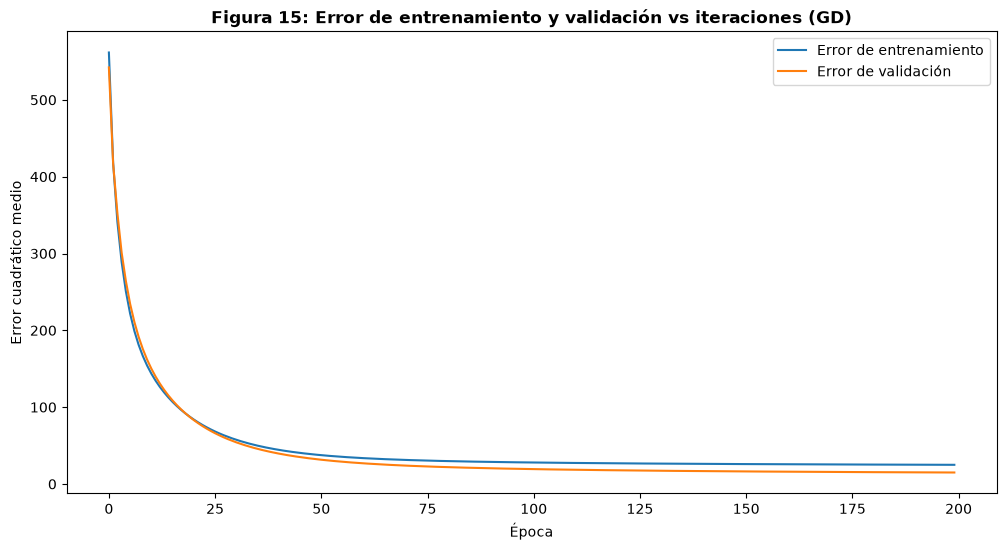

MSE de validación tras 200 épocas: 14.92


In [1273]:
# Con escalado robusto: la misma cantidad de épocas con una tasa 30.000 veces mayor
np.random.seed(RANDOM_STATE)
W_escalado = gradient_descent(X_gd_train_scaled, y_gd_train_np, X_gd_val_scaled, y_gd_val_np,
                              lr=0.03, epochs=200, fig_num=N_FIG)

print('MSE de validación tras 200 épocas:',
      round(float(np.mean((y_gd_val_np - predecir_con_pesos(X_gd_val_scaled, W_escalado)) ** 2)), 2))
N_FIG += 1

**Observación.** Sin escalar, después de 200 épocas el error sigue siendo altísimo: con `lr = 0.000001` cada paso es minúsculo y el algoritmo avanza muy poco. Con las variables escaladas y `lr = 0.03`, la curva baja rápido y se aplana en un valor cercano al de mínimos cuadrados.

Esto responde una parte de la consigna: el escalado no cambia el resultado de `LinearRegression`, pero es imprescindible para el gradiente descendente.

### 15.3 Variación de la tasa de aprendizaje

La tasa de aprendizaje es el hiperparámetro central del método. Probamos cuatro valores con la misma cantidad de épocas.

Tasa de aprendizaje: 0.001


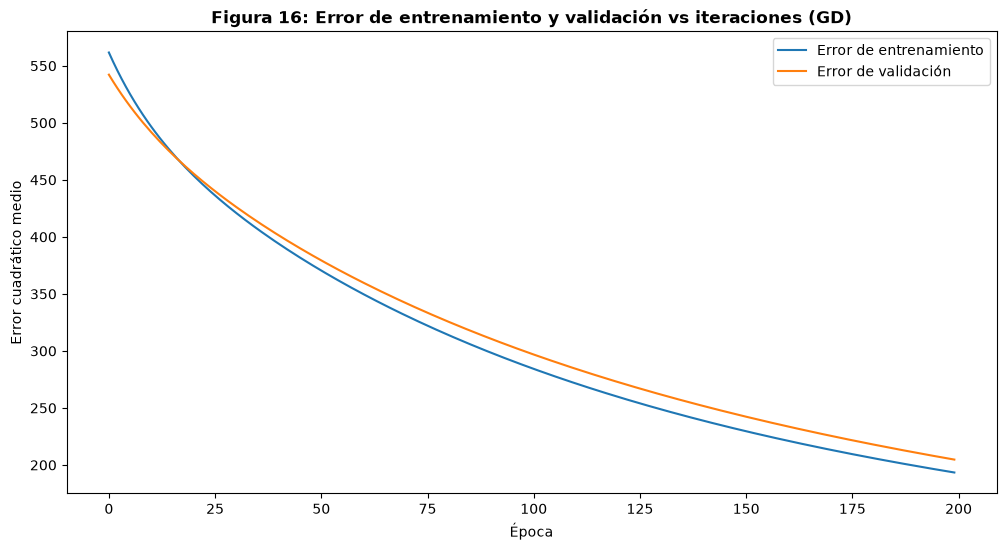

MSE de validación tras 200 épocas: 204.088
Tasa de aprendizaje: 0.01


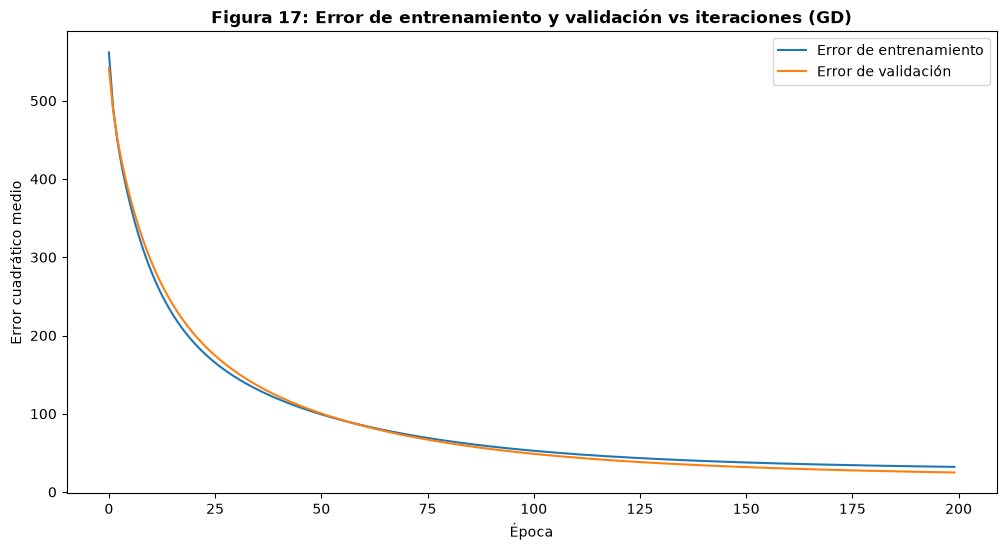

MSE de validación tras 200 épocas: 24.840
Tasa de aprendizaje: 0.03


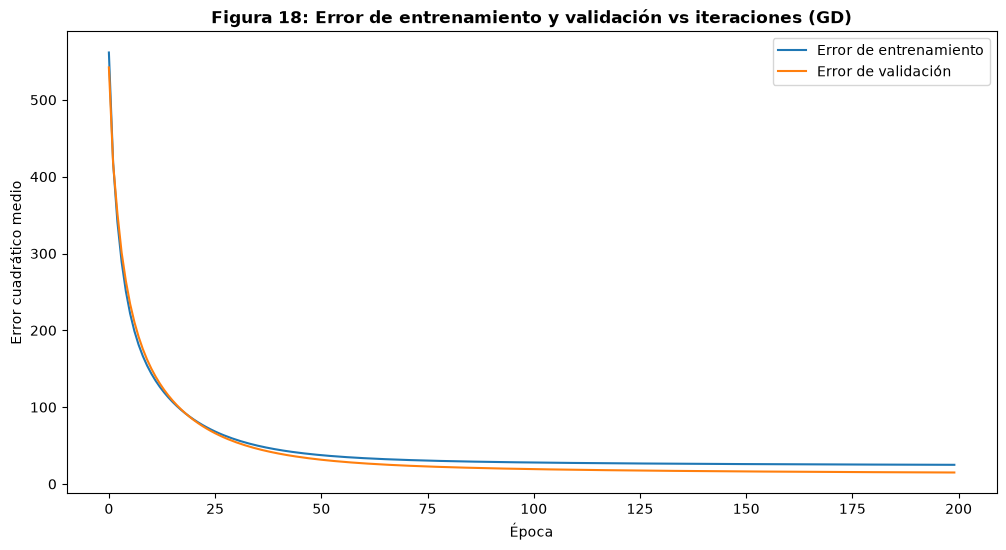

MSE de validación tras 200 épocas: 14.920
Tasa de aprendizaje: 0.05


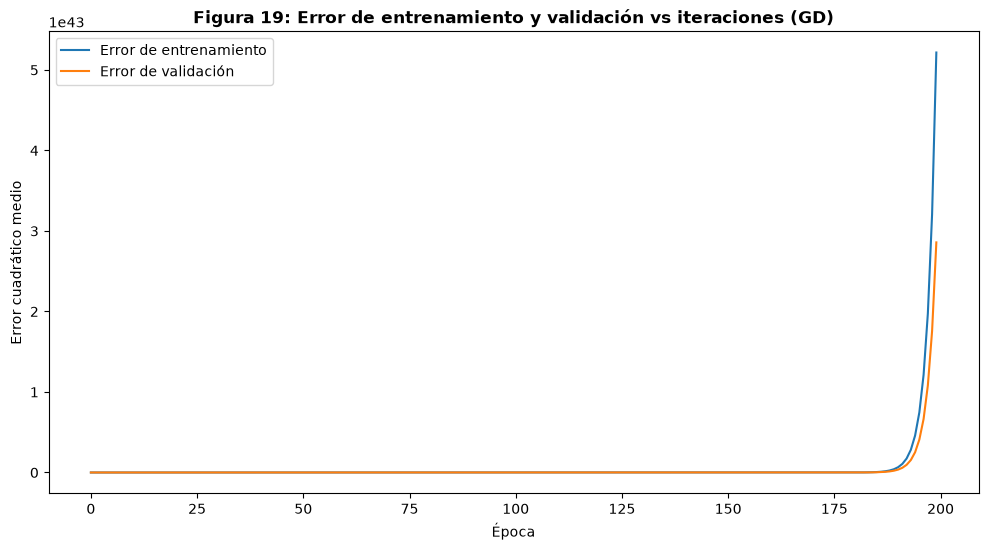

MSE de validación tras 200 épocas: 46,470,036,869,532,264,219,526,867,249,397,728,660,160,512.000


In [1274]:
for lr in [0.001, 0.01, 0.03, 0.05]:
    print('=' * 60)
    print(f'Tasa de aprendizaje: {lr}')
    np.random.seed(RANDOM_STATE)
    W_lr = gradient_descent(X_gd_train_scaled, y_gd_train_np, X_gd_val_scaled, y_gd_val_np,
                            lr=lr, epochs=200, fig_num=N_FIG)
    N_FIG += 1
    mse_val = float(np.mean((y_gd_val_np - predecir_con_pesos(X_gd_val_scaled, W_lr)) ** 2))
    print(f'MSE de validación tras 200 épocas: {mse_val:,.3f}')

**Observaciones.**

- Con `lr = 0.001` el error baja, pero muy despacio: después de 200 épocas todavía está lejos del mínimo. El paso es demasiado chico.
- Con `lr = 0.01` converge, aunque necesita más épocas para terminar de estabilizarse.
- Con `lr = 0.03` la curva baja rápido y se aplana. Es el mejor de los cuatro valores.
- Con `lr = 0.05` el algoritmo diverge: el error crece sin control hasta valores enormes. El paso es tan grande que cada corrección se pasa del mínimo y se aleja cada vez más.

Las curvas de entrenamiento y validación se mantienen juntas en todos los casos que convergen, sin que la de validación empiece a subir: el modelo no sobreajusta.

### 15.4 Comparación de los tres métodos

Entrenamos ahora con descenso estocástico y con mini-batch. Cada método tolera una tasa de aprendizaje distinta, así que usamos para cada uno la mayor tasa con la que se mantiene estable.

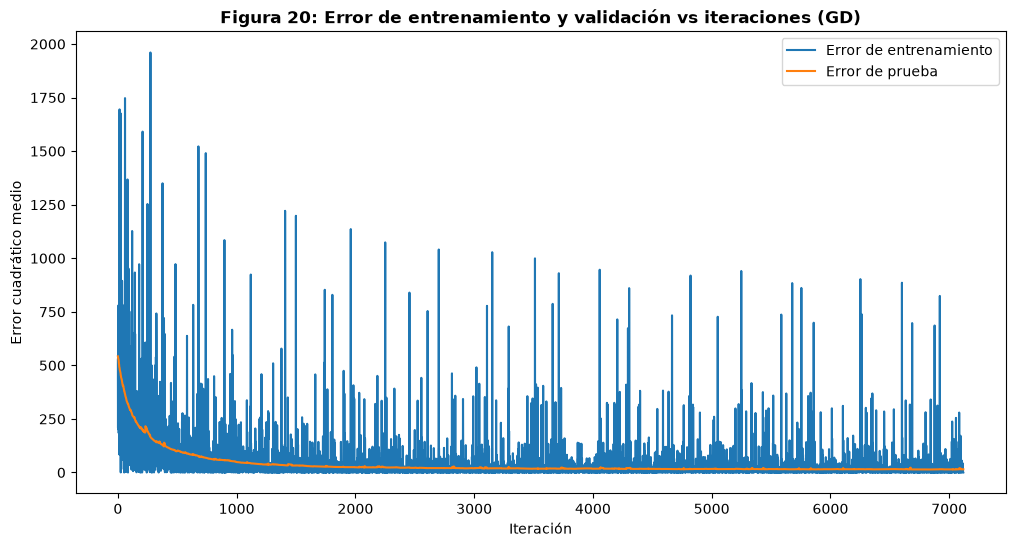

In [1275]:
# Descenso estocástico: actualiza los pesos con una muestra por vez
np.random.seed(RANDOM_STATE)
W_sgd = stochastic_gradient_descent(X_gd_train_scaled, y_gd_train_np,
                                    X_gd_val_scaled, y_gd_val_np, lr=0.001, epochs=20, fig_num=N_FIG)
N_FIG += 1

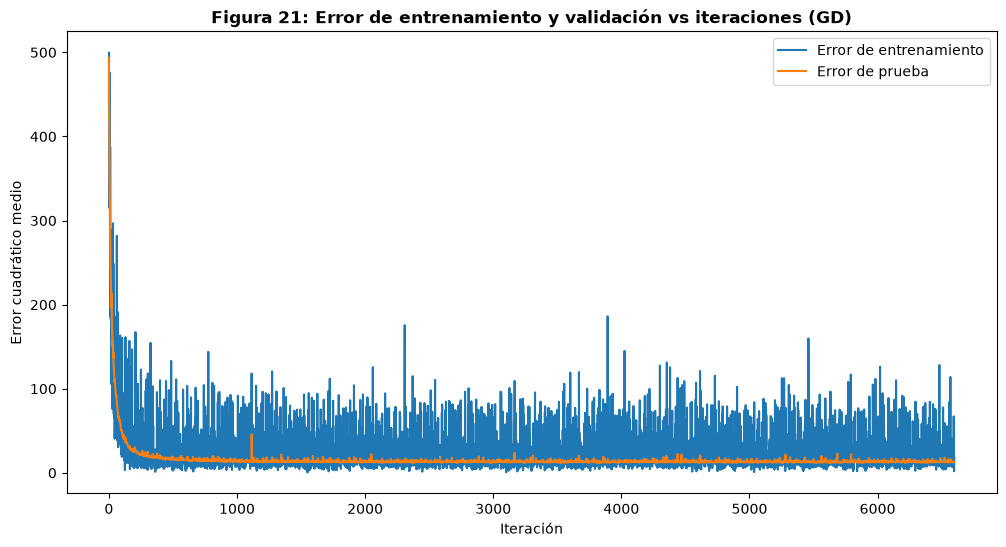

In [1276]:
# Mini-batch: actualiza los pesos con lotes de 11 muestras
np.random.seed(RANDOM_STATE)
W_mb = mini_batch_gradient_descent(X_gd_train_scaled, y_gd_train_np,
                                   X_gd_val_scaled, y_gd_val_np, lr=0.01, epochs=200, fig_num=N_FIG)
N_FIG += 1

In [1277]:
# ¿Hasta qué tasa de aprendizaje tolera cada método?
# Silenciamos los gráficos de las funciones para poder armar la tabla sin generar 12 figuras.
mostrar_original = plt.show
plt.show = lambda *args, **kwargs: None

tasas = [0.001, 0.01, 0.03, 0.05]
estabilidad = []

for lr in tasas:
    fila = {'lr': lr}
    for nombre, funcion, epocas in [('GD', gradient_descent, 200),
                                    ('SGD', stochastic_gradient_descent, 5),
                                    ('Mini-batch', mini_batch_gradient_descent, 50)]:
        np.random.seed(RANDOM_STATE)
        W = funcion(X_gd_train_scaled, y_gd_train_np, X_gd_val_scaled, y_gd_val_np,
                    lr=lr, epochs=epocas)
        mse = float(np.mean((y_gd_val_np - predecir_con_pesos(X_gd_val_scaled, W)) ** 2))
        fila[nombre] = mse if np.isfinite(mse) and mse < 1e6 else np.inf
    estabilidad.append(fila)

plt.show = mostrar_original
plt.close('all')

print('MSE de validación (inf = el método divergió):')
pd.DataFrame(estabilidad).set_index('lr').round(3)

MSE de validación (inf = el método divergió):


,GD,SGD,Mini-batch
lr,,,
0.001,204.088,27.121,29.728
0.010,24.840,inf,12.928
0.030,14.920,inf,980.989
0.050,inf,inf,inf


**Observaciones.** En la tabla, cada método usa una cantidad distinta de épocas (GD 200, SGD 5, mini-batch 50) porque hacen muy distinta cantidad de actualizaciones por época: SGD actualiza los pesos 353 veces por época y GD una sola vez. Por eso la tabla sirve para comparar estabilidad, no velocidad de convergencia.

- El descenso del gradiente tolera la tasa más alta: con `lr = 0.03` sigue siendo estable, porque promedia el gradiente sobre las 353 observaciones y ese promedio amortigua los valores extremos.
- El mini-batch aguanta hasta `lr = 0.01`: el gradiente es más ruidoso al actualizar por un subconjunto parcial de los datos. 
- El descenso estocástico es el más delicado: sólo es estable con `lr = 0.001`. Cada actualización usa una sola vivienda, de modo que una observación con un valor extremo (recordemos que conservamos los outliers y que `CRIM` llega a valores escalados de 20) produce por sí sola una corrección enorme.
- En las curvas de SGD y mini-batch el error no baja suave como en GD, sino que oscila y al aumentar el valor del learning rate se vuelven más sensibles al ruido y a los outliers y al seguir aumentando llegan a diverger. Es el efecto de actualizar con información parcial: cada paso mejora la muestra que le tocó, no necesariamente el conjunto completo.

En este problema el GD clásico es suficiente: con 353 registros no hay ninguna necesidad de actualizar por lotes. Las versiones estocástica y mini-batch tienen sentido cuando el dataset no entra en memoria o cuando calcular el gradiente completo es demasiado costoso.

### 15.5 Modelo final y comparación con mínimos cuadrados

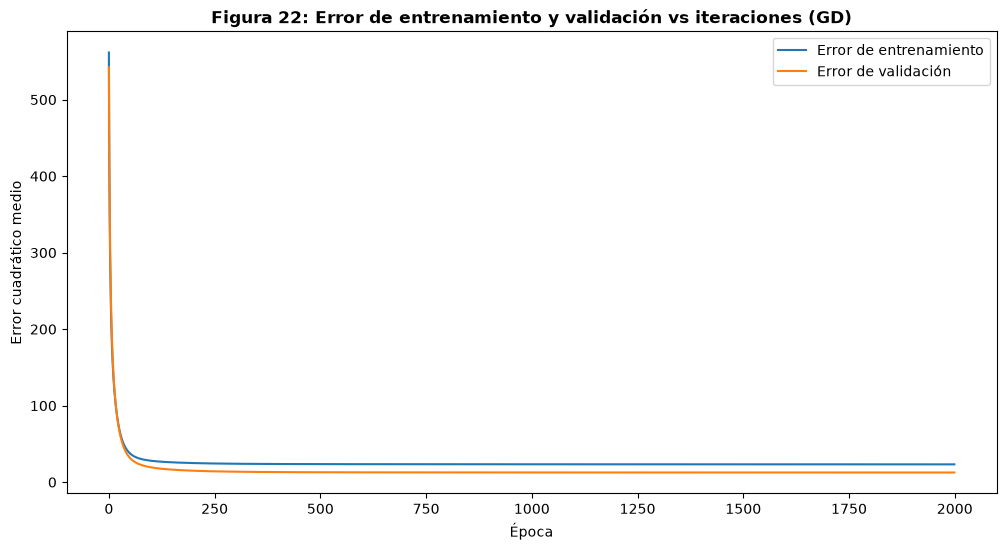

R2 train: 0.7453 | R2 test: 0.6442
RMSE en el conjunto de entrenamiento: 4.8216
RMSE en el conjunto de prueba: 4.7087


In [1278]:
# Entrenamos el modelo definitivo con la mejor configuración encontrada con el método de gradiente descendente
np.random.seed(RANDOM_STATE)
W_final = gradient_descent(X_gd_train_scaled, y_gd_train_np, X_gd_val_scaled, y_gd_val_np,
                           lr=0.03, epochs=2000, fig_num=N_FIG)
N_FIG += 1
# Predicciones y métricas. Ojo: este modelo se entrenó con 353 registros (el resto quedó
# como validación), mientras que los demás modelos usan los 404 del train completo.
pred_train_gd = predecir_con_pesos(X_gd_train_scaled, W_final)
pred_test_gd = predecir_con_pesos(X_gd_test_scaled, W_final)

resultados_modelos.append({
    'Modelo': 'Descenso del gradiente',
    'R2 train': r2_score(y_gd_train_np, pred_train_gd),
    'R2 test': r2_score(y_test_np, pred_test_gd),
    'RMSE train': np.sqrt(mean_squared_error(y_gd_train_np, pred_train_gd)),
    'RMSE test': np.sqrt(mean_squared_error(y_test_np, pred_test_gd)),
    'MAE train': mean_absolute_error(y_gd_train_np, pred_train_gd),
    'MAE test': mean_absolute_error(y_test_np, pred_test_gd),
})

print(f'R2 train: {r2_score(y_gd_train_np, pred_train_gd):.4f} | '
      f'R2 test: {r2_score(y_test_np, pred_test_gd):.4f}')
print(f'RMSE en el conjunto de entrenamiento: {np.sqrt(mean_squared_error(y_gd_train_np, pred_train_gd)):.4f}')
print(f'RMSE en el conjunto de prueba: {np.sqrt(mean_squared_error(y_test_np, pred_test_gd)):.4f}')

In [1279]:
# Comparación de los pesos con los de mínimos cuadrados entrenado sobre los mismos datos
lr_gd = LinearRegression().fit(X_gd_train_scaled, y_gd_train_np)

comparacion_pesos = pd.DataFrame({
    'Mínimos cuadrados': np.r_[lr_gd.intercept_, lr_gd.coef_.flatten()],
    'Gradiente descendente': W_final.flatten(),
}, index=['Intercepto'] + list(X_train.columns))
comparacion_pesos['Diferencia'] = (comparacion_pesos['Gradiente descendente']
                                   - comparacion_pesos['Mínimos cuadrados'])

print('Pesos del modelo:')
print('=' * 60)
print(comparacion_pesos.round(3).to_string())

Pesos del modelo:
            Mínimos cuadrados  Gradiente descendente  Diferencia
Intercepto             23.181                 23.196       0.015
CRIM                   -0.420                 -0.405       0.015
ZN                      0.954                  0.917      -0.037
INDUS                   0.518                  0.237      -0.281
CHAS                    2.265                  2.382       0.117
NOX                    -3.603                 -3.561       0.042
RM                      3.014                  3.038       0.024
AGE                    -0.114                 -0.147      -0.033
DIS                    -4.975                 -4.979      -0.004
RAD                     6.465                  5.575      -0.890
TAX                    -4.947                 -3.926       1.021
PTRATIO                -3.456                 -3.433       0.023
B                       0.186                  0.185      -0.001
LSTAT                  -5.422                 -5.417       0.005


**¿Hubo algún cambio?** No: el gradiente descendente llega prácticamente a la misma solución que `LinearRegression`. Los pesos coinciden en casi todas las variables y las métricas son equivalentes.

Es lo esperable, porque los dos métodos minimizan la misma función de costo: uno la resuelve con una fórmula cerrada y el otro por aproximaciones sucesivas. Las diferencias que quedan se explican porque el método iterativo se detiene cerca del mínimo, no exactamente en él, y se concentran en `RAD` y `TAX`, el par colineal: como el mínimo es muy plano en esa dirección, muchas combinaciones de esos dos pesos dan errores casi idénticos.

La ventaja del gradiente descendente no se ve en un problema de este tamaño: aparece cuando hay tantas observaciones o tantas variables que resulta demasiado costoso.

### 15.6 Efecto de la transformación logarítmica sobre la convergencia

En la sección 12 medimos que la transformación logarítmica de `CRIM` y `B` empeora el ajuste de mínimos cuadrados, y por eso entrenamos los modelos con las variables sin transformar. Pero el gradiente descendente es sensible a la magnitud de los valores de entrada a diferencia de mínimos cuadrados.

`RobustScaler` divide por el rango intercuartílico, que no acota los valores extremos. Como decidimos conservar los outliers, quedan variables con valores escalados muy grandes, y el gradiente es proporcional al valor de la feature, por lo que, una observación extrema produce por sí sola una corrección enorme. Lo que hace el logaritmo es comprimir esas colas.

Comparamos entonces las dos versiones de los datos con la misma función `gradient_descent` de la cátedra.

In [1280]:
# Reutilizamos la transformación de la sección 12 (el máximo de reflexión se calculó con el train)
X_gd_train_log = X_train_log.loc[X_gd_train.index]
X_gd_val_log = X_train_log.loc[X_gd_val.index]

scaler_gd_log = RobustScaler().fit(X_gd_train_log)
X_gd_train_log_scaled = scaler_gd_log.transform(X_gd_train_log)
X_gd_val_log_scaled = scaler_gd_log.transform(X_gd_val_log)

print('Rango de los valores escalados que recibe el gradiente descendente:')
print('=' * 65)
print(f'  Sin transformar: [{X_gd_train_scaled.min():6.1f}, {X_gd_train_scaled.max():6.1f}]')
print(f'  Con logaritmo:   [{X_gd_train_log_scaled.min():6.1f}, {X_gd_train_log_scaled.max():6.1f}]')

Rango de los valores escalados que recibe el gradiente descendente:
  Sin transformar: [ -18.1,   18.1]
  Con logaritmo:   [  -3.3,    5.0]


SIN transformación logarítmica:


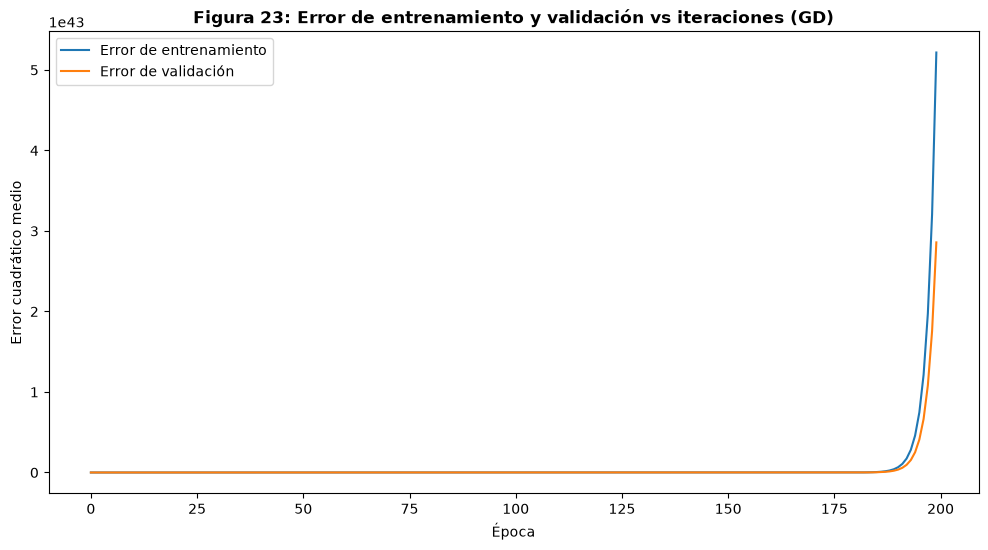

In [1281]:
# Con lr = 0.05, que es la tasa con la que el algoritmo divergía en la sección 15.3
print('SIN transformación logarítmica:')
np.random.seed(RANDOM_STATE)
W_sin_log = gradient_descent(X_gd_train_scaled, y_gd_train_np, X_gd_val_scaled, y_gd_val_np,
                             lr=0.05, epochs=200, fig_num=N_FIG)
N_FIG += 1

CON transformación logarítmica:


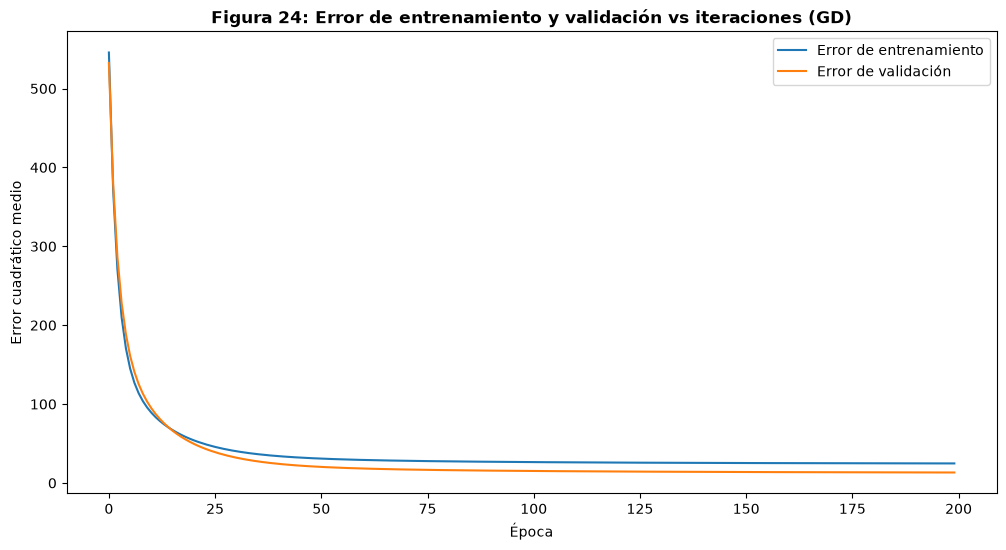

In [1282]:
print('CON transformación logarítmica:')
np.random.seed(RANDOM_STATE)
W_con_log = gradient_descent(X_gd_train_log_scaled, y_gd_train_np, X_gd_val_log_scaled, y_gd_val_np,
                             lr=0.05, epochs=200, fig_num=N_FIG)
N_FIG += 1

In [1283]:
# Tabla comparativa para varias tasas de aprendizaje.
# Silenciamos los gráficos de la función para no generar diez figuras.
mostrar_original = plt.show
plt.show = lambda *args, **kwargs: None

comparacion_log = []
for lr in [0.01, 0.03, 0.05, 0.1, 0.3]:
    fila = {'lr': lr}
    for etiqueta, X_tr_gd, X_val_gd in [('Sin transformar', X_gd_train_scaled, X_gd_val_scaled),
                                        ('Con logaritmo', X_gd_train_log_scaled, X_gd_val_log_scaled)]:
        np.random.seed(RANDOM_STATE)
        W = gradient_descent(X_tr_gd, y_gd_train_np, X_val_gd, y_gd_val_np, lr=lr, epochs=200)
        mse = float(np.mean((y_gd_val_np - predecir_con_pesos(X_val_gd, W)) ** 2))
        fila[etiqueta] = mse if np.isfinite(mse) and mse < 1e6 else np.inf
    comparacion_log.append(fila)

plt.show = mostrar_original
plt.close('all')

print('MSE de validación tras 200 épocas (inf = divergió):')
pd.DataFrame(comparacion_log).set_index('lr').round(2)

MSE de validación tras 200 épocas (inf = divergió):


,Sin transformar,Con logaritmo
lr,,
0.01,24.84,24.50
0.03,14.92,14.51
0.05,inf,13.26
0.10,inf,12.66
0.30,inf,12.81


**Observaciones.**

- El rango de los valores escalados pasa de aproximadamente [−18 ; 18] a [−3,3 ; 5].
- Sin transformar, el algoritmo diverge a partir de `lr = 0.05`. Con la transformación converge con todas las tasas probadas, incluso con `lr = 0.3`.
- Con las tasas en las que ambos funcionan (0,01 y 0,03) los resultados son equivalentes, así que la transformación no mejora el ajuste: lo que amplía es el rango de tasas de aprendizaje utilizables.

**Conclusión.** La transformación logarítmica empeora levemente el ajuste de mínimos cuadrados pero vuelve más estable al gradiente descendente. Como nuestros modelos finales son los de scikit-learn, que resuelven por mínimos cuadrados o por coordenadas, mantenemos las variables sin transformar; si el modelo definitivo fuera entrenado por gradiente descendente, la decisión razonable sería la contraria.

---

## 16. Métodos de regularización

Los tres modelos requieren los datos escalados, porque la penalización se aplica sobre la magnitud de los coeficientes y esa magnitud depende de la escala de cada variable. Para eso armamos una tubería (`make_pipeline`): al llamar a `fit` se ajustan el escalador y el modelo, y al llamar a `predict` se aplica el `transform` del escalador y después el `predict` del modelo, en un solo paso.

Para elegir $\alpha$ usamos las versiones con validación cruzada (`RidgeCV`, `LassoCV`, `ElasticNetCV`), que prueban un rango de valores y se quedan con el mejor sin usar el conjunto de test.

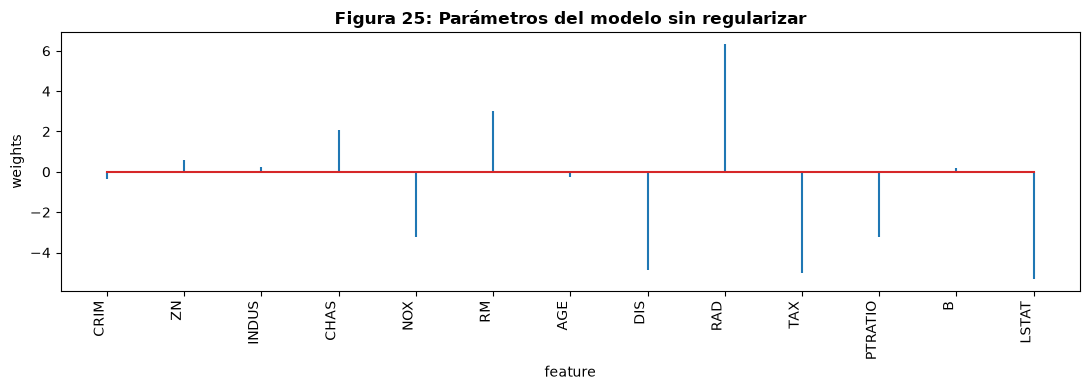

El error (rmse) de test es: 4.752086584643112
R2 de test: 0.637653799428487


In [1284]:
# Regresión lineal sin regularizar, como referencia
modelo_ols = make_pipeline(RobustScaler(), LinearRegression())
modelo_ols.fit(X_train, y_train)

df_coeficientes = pd.DataFrame({'predictor': X_train.columns,
                                'coef': modelo_ols.steps[1][1].coef_.flatten()})

fig, ax = plt.subplots(figsize=(11, 4))
ax.stem(df_coeficientes.predictor, df_coeficientes.coef, markerfmt=' ')
plt.xticks(rotation=90, ha='right', size=10)
ax.set_xlabel('feature')
ax.set_ylabel('weights')
ax.set_title(f'Figura {N_FIG}: Parámetros del modelo sin regularizar', fontweight='bold')
N_FIG += 1
plt.tight_layout()
plt.show()

y_pred = modelo_ols.predict(X_test)
rmse_ols = root_mean_squared_error(y_test, y_pred)
print(f"El error (rmse) de test es: {rmse_ols}")
print(f"R2 de test: {metrics.r2_score(y_test, y_pred)}")

### 16.1 Ridge

`RidgeCV` prueba un rango de valores de $\alpha$ con validación cruzada y se queda con el mejor. Usamos `np.logspace(-4, 6, 200)`, que genera 200 valores en escala logarítmica entre $10^{-4}$ y $10^{6}$.

In [1285]:
modelo_ridge = make_pipeline(
    RobustScaler(),
    RidgeCV(alphas=np.logspace(-4, 6, 200), fit_intercept=True, store_cv_results=True)
)
_ = modelo_ridge.fit(X_train, y_train)
mod = modelo_ridge.steps[1][1]
print(f'Mejor valor de alpha encontrado: {mod.alpha_}')

Mejor valor de alpha encontrado: 0.9329304026284686


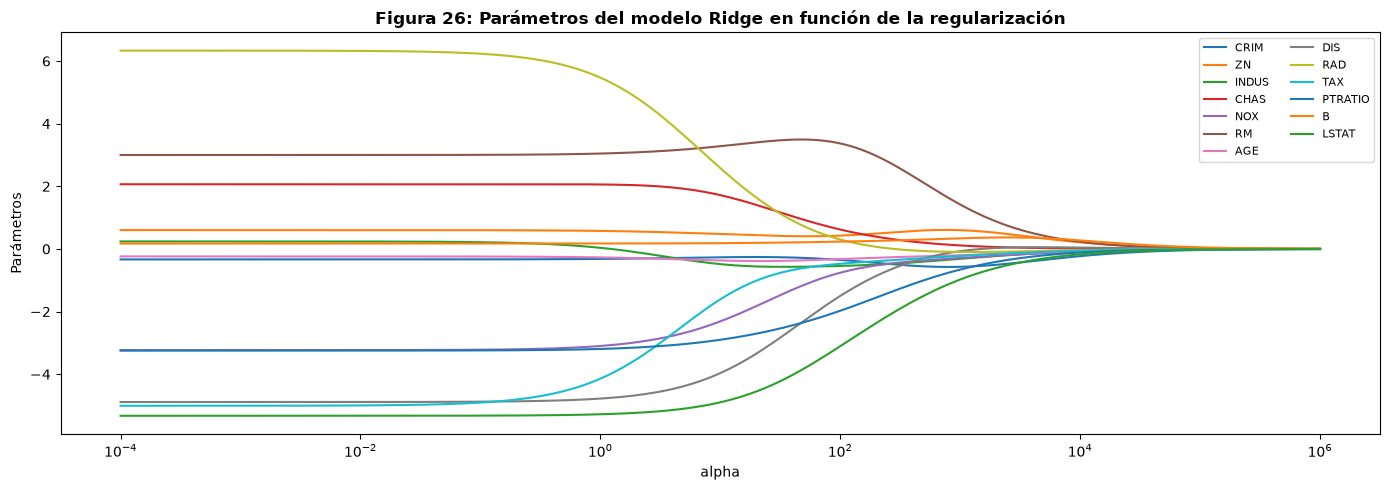

In [1286]:
# Evolución de los parámetros en función de alpha
alphas = mod.alphas
coefs = []

for alpha in alphas:
    modelo_aux = make_pipeline(RobustScaler(), Ridge(alpha=alpha))
    modelo_aux.fit(X_train, y_train)
    coefs.append(modelo_aux.steps[1][1].coef_.flatten())

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(alphas, coefs, label=X_train.columns)
ax.set_xscale('log')
ax.set_xlabel('alpha')
ax.set_ylabel('Parámetros')
ax.set_title(f'Figura {N_FIG}: Parámetros del modelo Ridge en función de la regularización',
             fontweight='bold')
N_FIG += 1
plt.axis('tight')
plt.legend(ncol=2, fontsize=8)
plt.tight_layout()
plt.show()

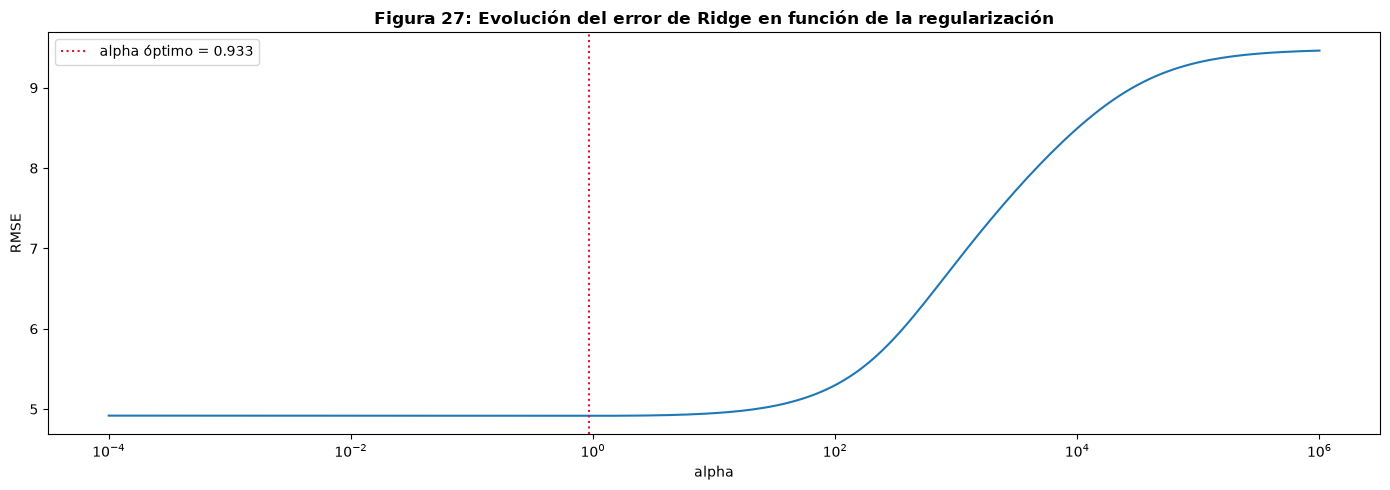

RMSE de validación cruzada mínimo: 4.9170


In [1287]:
# Evolución del error de validación cruzada en función de alpha
mse_cv = mod.cv_results_.reshape((-1, len(mod.alphas))).mean(axis=0)
rmse_cv = np.sqrt(mse_cv)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(mod.alphas, rmse_cv)
ax.axvline(mod.alpha_, color='crimson', linestyle=':', label=f'alpha óptimo = {mod.alpha_:.3f}')
ax.set_xscale('log')
ax.set_xlabel('alpha')
ax.set_ylabel('RMSE')
ax.set_title(f'Figura {N_FIG}: Evolución del error de Ridge en función de la regularización',
             fontweight='bold')
N_FIG += 1
plt.legend()
plt.tight_layout()
plt.show()

print(f'RMSE de validación cruzada mínimo: {rmse_cv.min():.4f}')

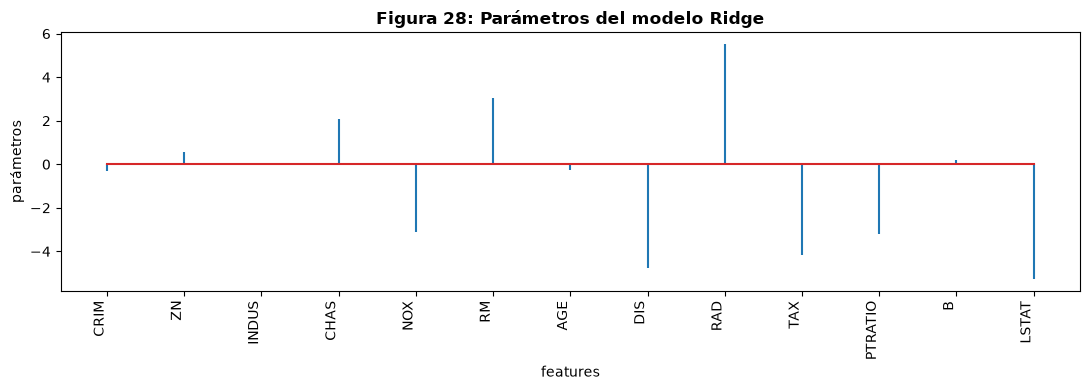

El error (rmse) de test es: 4.74248973922363
R2 de test: 0.639115838945659


In [1288]:
# Coeficientes del modelo Ridge con el alpha óptimo
df_coeficientes = pd.DataFrame({'predictor': X_train.columns, 'coef': mod.coef_.flatten()})

fig, ax = plt.subplots(figsize=(11, 4))
ax.stem(df_coeficientes.predictor, df_coeficientes.coef, markerfmt=' ')
plt.xticks(rotation=90, ha='right', size=10)
ax.set_xlabel('features')
ax.set_ylabel('parámetros')
ax.set_title(f'Figura {N_FIG}: Parámetros del modelo Ridge', fontweight='bold')
N_FIG += 1
plt.tight_layout()
plt.show()

y_pred = modelo_ridge.predict(X_test)
rmse_ridge = root_mean_squared_error(y_test, y_pred)
print(f"El error (rmse) de test es: {rmse_ridge}")
print(f"R2 de test: {metrics.r2_score(y_test, y_pred)}")

resultados_modelos.append(evaluar_modelo(f'Ridge (alpha={mod.alpha_:.3f})', modelo_ridge,
                                         X_tr=X_train, X_te=X_test))

### 16.2 Lasso

In [1289]:
modelo_lasso = make_pipeline(
    RobustScaler(),
    LassoCV(alphas=np.logspace(-4, 2, 200), cv=5, random_state=RANDOM_STATE)
)
_ = modelo_lasso.fit(X_train, y_train)
mod = modelo_lasso.steps[1][1]
print(f'Mejor valor de alpha encontrado: {mod.alpha_}')

Mejor valor de alpha encontrado: 0.005231099308056258


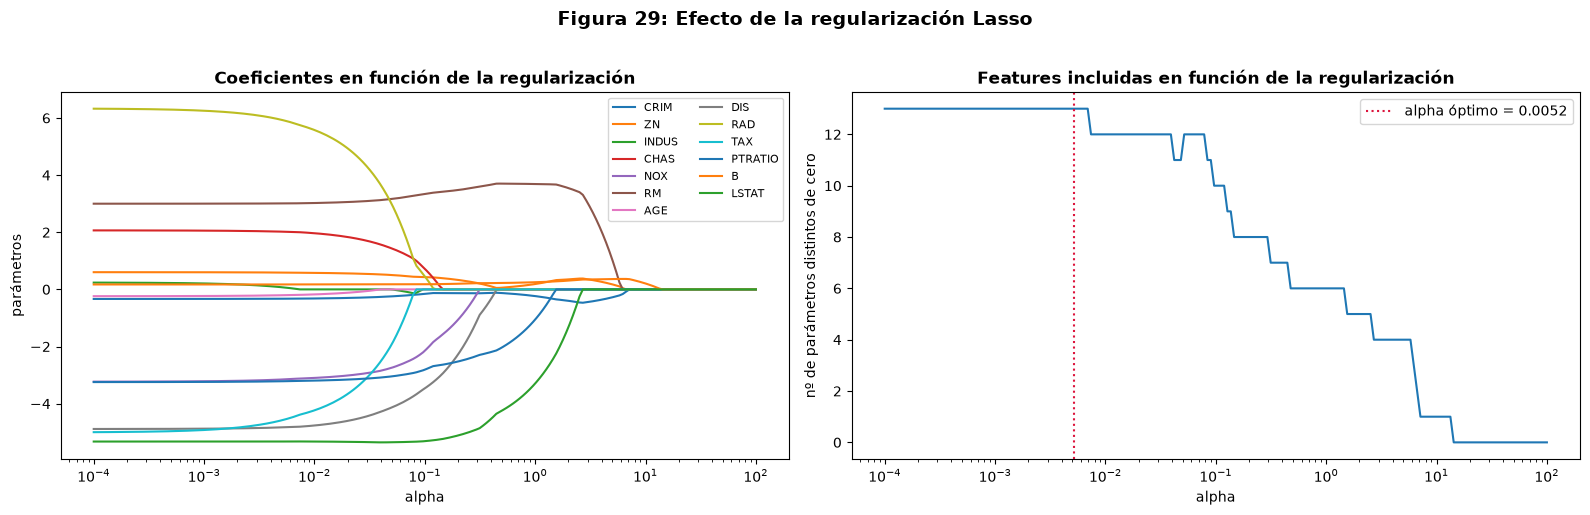

In [1290]:
# Evolución de los parámetros y de la cantidad de features incluidas en función de alpha
alphas = mod.alphas_
coefs = []
n_predictores = []

for alpha in alphas:
    modelo_aux = make_pipeline(RobustScaler(), Lasso(alpha=alpha))
    modelo_aux.fit(X_train, y_train)
    coef = modelo_aux.steps[1][1].coef_.flatten()
    coefs.append(coef)
    n_predictores.append(np.sum(coef != 0))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(alphas, coefs, label=X_train.columns)
axes[0].set_xscale('log')
axes[0].set_xlabel('alpha')
axes[0].set_ylabel('parámetros')
axes[0].set_title('Coeficientes en función de la regularización', fontweight='bold')
axes[0].legend(ncol=2, fontsize=8)

axes[1].plot(alphas, n_predictores)
axes[1].axvline(mod.alpha_, color='crimson', linestyle=':', label=f'alpha óptimo = {mod.alpha_:.4f}')
axes[1].set_xscale('log')
axes[1].set_xlabel('alpha')
axes[1].set_ylabel('nº de parámetros distintos de cero')
axes[1].set_title('Features incluidas en función de la regularización', fontweight='bold')
axes[1].legend()

plt.suptitle(f'Figura {N_FIG}: Efecto de la regularización Lasso', fontsize=14, fontweight='bold', y=1.02)
N_FIG += 1
plt.tight_layout()
plt.show()

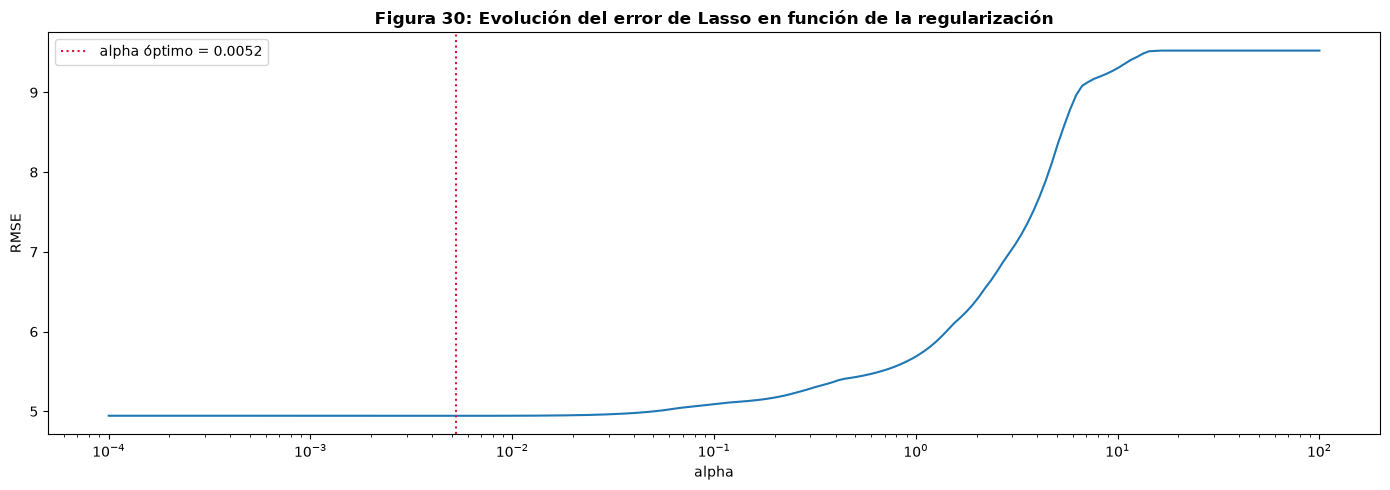

Features que Lasso conserva (coeficiente distinto de cero):
predictor      coef
     CRIM -0.326576
       ZN  0.588519
    INDUS  0.069750
     CHAS  2.019520
      NOX -3.151446
       RM  3.009434
      AGE -0.203720
      DIS -4.829238
      RAD  5.919106
      TAX -4.567116
  PTRATIO -3.214955
        B  0.172373
    LSTAT -5.325113

Features anuladas por Lasso: []

El error (rmse) de test es: 4.747713309683099
R2 de test: 0.6383204162408839


In [1291]:
# Evolución del error de validación cruzada en función de alpha
rmse_cv = np.sqrt(mod.mse_path_.mean(axis=1))

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(mod.alphas_, rmse_cv)
ax.axvline(mod.alpha_, color='crimson', linestyle=':', label=f'alpha óptimo = {mod.alpha_:.4f}')
ax.set_xscale('log')
ax.set_xlabel('alpha')
ax.set_ylabel('RMSE')
ax.set_title(f'Figura {N_FIG}: Evolución del error de Lasso en función de la regularización',
             fontweight='bold')
N_FIG += 1
plt.legend()
plt.tight_layout()
plt.show()

df_coeficientes = pd.DataFrame({'predictor': X_train.columns, 'coef': mod.coef_.flatten()})
print('Features que Lasso conserva (coeficiente distinto de cero):')
print(df_coeficientes[df_coeficientes.coef != 0].to_string(index=False))
print()
print('Features anuladas por Lasso:', list(df_coeficientes[df_coeficientes.coef == 0].predictor))

y_pred = modelo_lasso.predict(X_test)
rmse_lasso = root_mean_squared_error(y_test, y_pred)
print()
print(f"El error (rmse) de test es: {rmse_lasso}")
print(f"R2 de test: {metrics.r2_score(y_test, y_pred)}")

resultados_modelos.append(evaluar_modelo(f'Lasso (alpha={mod.alpha_:.4f})', modelo_lasso,
                                         X_tr=X_train, X_te=X_test))

### 16.3 Elastic Net

Mejor valor de alpha encontrado: 0.012033778407775893
Mejor valor de l1_ratio encontrado: 0.99


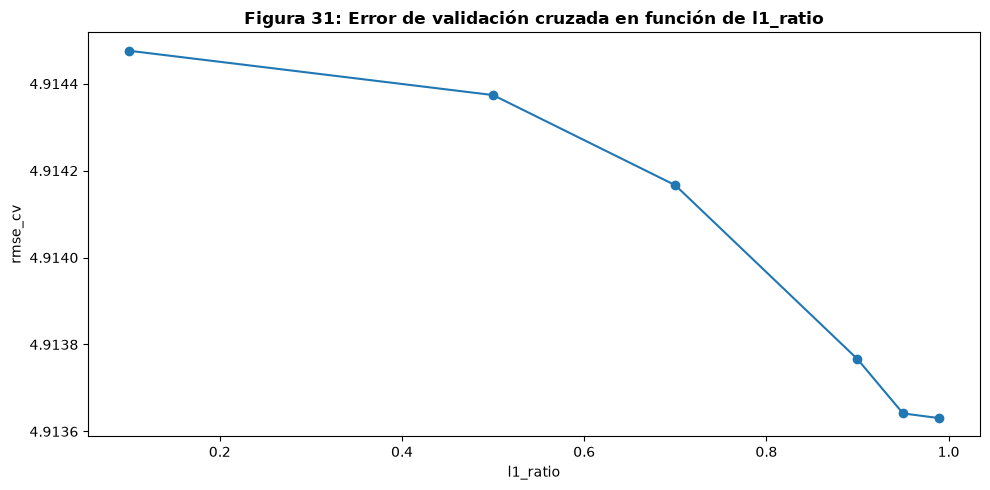

,l1_ratio,alpha,mse_cv,rmse_cv
1130,0.99,0.012034,24.143766,4.913631
931,0.95,0.011227,24.143872,4.913641
1129,0.99,0.012899,24.143987,4.913653
932,0.95,0.010474,24.144021,4.913657
1131,0.99,0.011227,24.144385,4.913694


In [1292]:
modelo_elastic = make_pipeline(
    RobustScaler(),
    ElasticNetCV(l1_ratio=[0.1, 0.5, 0.7, 0.9, 0.95, 0.99],
                 alphas=np.logspace(-4, 2, 200), cv=10, random_state=RANDOM_STATE)
)
_ = modelo_elastic.fit(X_train, y_train)
mod = modelo_elastic.steps[1][1]

print(f'Mejor valor de alpha encontrado: {mod.alpha_}')
print(f'Mejor valor de l1_ratio encontrado: {mod.l1_ratio_}')

# Error medio de las particiones para cada combinación de alpha y l1_ratio
mean_error_cv = mod.mse_path_.mean(axis=2)
df_resultados_cv = pd.DataFrame(
    data=mean_error_cv.flatten(),
    index=pd.MultiIndex.from_product(iterables=[mod.l1_ratio, mod.alphas_],
                                     names=['l1_ratio', 'alpha']),
    columns=['mse_cv'])
df_resultados_cv['rmse_cv'] = np.sqrt(df_resultados_cv['mse_cv'])
df_resultados_cv = df_resultados_cv.reset_index().sort_values('mse_cv')

fig, ax = plt.subplots(figsize=(10, 5))
df_resultados_cv.groupby('l1_ratio')['rmse_cv'].min().plot(ax=ax, marker='o')
ax.set_xlabel('l1_ratio')
ax.set_ylabel('rmse_cv')
ax.set_title(f'Figura {N_FIG}: Error de validación cruzada en función de l1_ratio', fontweight='bold')
N_FIG += 1
plt.tight_layout()
plt.show()

display(df_resultados_cv.head())

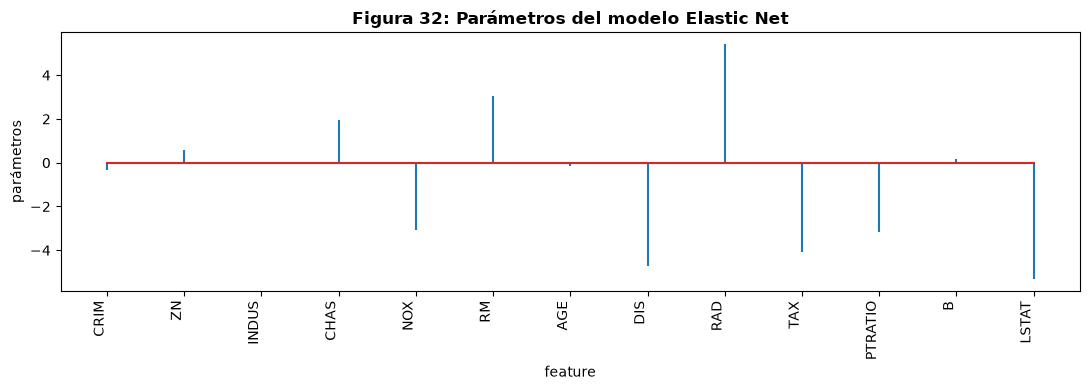

El error (rmse) de test es: 4.743276019104021
R2 de test: 0.6389961636302798


In [1293]:
# Coeficientes del modelo Elastic Net
df_coeficientes = pd.DataFrame({'predictor': X_train.columns, 'coef': mod.coef_.flatten()})

fig, ax = plt.subplots(figsize=(11, 4))
ax.stem(df_coeficientes.predictor, df_coeficientes.coef, markerfmt=' ')
plt.xticks(rotation=90, ha='right', size=10)
ax.set_xlabel('feature')
ax.set_ylabel('parámetros')
ax.set_title(f'Figura {N_FIG}: Parámetros del modelo Elastic Net', fontweight='bold')
N_FIG += 1
plt.tight_layout()
plt.show()

y_pred = modelo_elastic.predict(X_test)
rmse_elastic = root_mean_squared_error(y_test, y_pred)
print(f"El error (rmse) de test es: {rmse_elastic}")
print(f"R2 de test: {metrics.r2_score(y_test, y_pred)}")

resultados_modelos.append(evaluar_modelo(
    f'Elastic Net (alpha={mod.alpha_:.4f}, l1_ratio={mod.l1_ratio_})', modelo_elastic,
    X_tr=X_train, X_te=X_test))

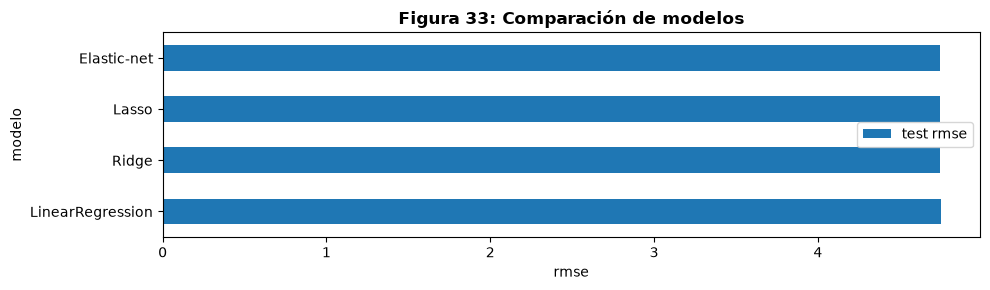

,modelo,test rmse
0,LinearRegression,4.7521
1,Ridge,4.7425
2,Lasso,4.7477
3,Elastic-net,4.7433


In [1294]:
# Comparación de los cuatro modelos por su error de test
df_comparacion = pd.DataFrame({
    'modelo': ['LinearRegression', 'Ridge', 'Lasso', 'Elastic-net'],
    'test rmse': [rmse_ols, rmse_ridge, rmse_lasso, rmse_elastic]
})

fig, ax = plt.subplots(figsize=(10, 3))
df_comparacion.set_index('modelo').plot(kind='barh', ax=ax)
ax.set_xlabel('rmse')
ax.set_ylabel('modelo')
ax.set_title(f'Figura {N_FIG}: Comparación de modelos', fontweight='bold')
N_FIG += 1
plt.tight_layout()
plt.show()

display(df_comparacion.round(4))

In [1295]:
# Coeficientes de los cuatro modelos, para ver el efecto de cada penalización
coeficientes_modelos = pd.DataFrame({
    'OLS': modelo_ols.steps[1][1].coef_.flatten(),
    'Ridge': modelo_ridge.steps[1][1].coef_.flatten(),
    'Lasso': modelo_lasso.steps[1][1].coef_.flatten(),
    'Elastic Net': modelo_elastic.steps[1][1].coef_.flatten(),
}, index=X_train.columns)

print('Coeficientes por modelo:')
print('=' * 60)
print(coeficientes_modelos.round(3).to_string())
print()
for nombre in coeficientes_modelos.columns:
    print(f'  {nombre:<12s} suma de |coeficientes| = {coeficientes_modelos[nombre].abs().sum():6.2f} | '
          f'coeficientes nulos = {(coeficientes_modelos[nombre] == 0).sum()}')

Coeficientes por modelo:
           OLS  Ridge  Lasso  Elastic Net
CRIM    -0.335 -0.319 -0.327       -0.314
ZN       0.602  0.578  0.589        0.574
INDUS    0.241  0.048  0.070        0.000
CHAS     2.066  2.061  2.020        1.939
NOX     -3.231 -3.106 -3.151       -3.078
RM       2.999  3.043  3.009        3.032
AGE     -0.238 -0.267 -0.204       -0.166
DIS     -4.887 -4.784 -4.829       -4.727
RAD      6.333  5.519  5.919        5.419
TAX     -5.006 -4.190 -4.567       -4.091
PTRATIO -3.245 -3.196 -3.215       -3.184
B        0.172  0.173  0.172        0.173
LSTAT   -5.326 -5.282 -5.325       -5.326

  OLS          suma de |coeficientes| =  34.68 | coeficientes nulos = 0
  Ridge        suma de |coeficientes| =  32.57 | coeficientes nulos = 0
  Lasso        suma de |coeficientes| =  33.40 | coeficientes nulos = 0
  Elastic Net  suma de |coeficientes| =  32.02 | coeficientes nulos = 1


**Observaciones sobre la regularización.**

- **El alpha óptimo de Lasso es muy chico** ($\alpha \approx 0{,}005$), así que la validación cruzada decidió casi no regularizar: no anula ninguna variable y sus coeficientes quedan casi iguales a los de la regresión sin regularizar. Lo mismo pasa con Elastic Net, que además elige `l1_ratio = 0.99`, es decir, se comporta casi como un Lasso puro. Tiene sentido, ya que la regularización sirve para controlar el sobreajuste, y este modelo no sobreajusta (R² de train y test son parecidos). Al no haber sobreajuste que corregir, penalizar sólo empeoraría el ajuste, y la validación cruzada lo detecta.
- **Ridge sí achica los coeficientes** ($\alpha \approx 0{,}93$), sobre todo los del par colineal: `RAD` pasa de 6,33 a 5,52 y `TAX` de −5,01 a −4,19. En la figura 26 se ve cómo esas dos curvas se acercan a medida que aumenta la regularización, que es el comportamiento que esperábamos tras detectar la colinealidad en la sección 8.
- **La diferencia de RMSE de test entre los cuatro modelos es mínima** (entre 4,74 y 4,75). Con este dataset, la regularización aporta estabilidad en los coeficientes más que precisión en las predicciones.
- En la figura 29 se ve el mecanismo de selección de variables de Lasso: a medida que aumenta $\alpha$, la cantidad de coeficientes distintos de cero baja hasta quedar en ninguno. Con el $\alpha$ óptimo estamos en el extremo izquierdo de esa curva, conservando las 13 variables activas.
- En la figura 32 y en la tabla comparativa de los coeficientes con los métodos de regularización se observa la reducción del coeficiente de `INDUS` a cero indicando que, dentro del conjunto de variables altamente correlacionadas, ElasticNet decidió descartar esa variable porque su efecto ya estaba absorbido por otras predictoras. Esto se da por la selección automática inducida por la penalización L1 y refleja que el modelo prefiere una representación más parsimoniosa sin perder mucho poder predictivo.

---

## 17. Comparación de los modelos de la consigna 4

Reunimos los resultados de todos los modelos entrenados hasta acá. 

,R2 train,R2 test,RMSE train,RMSE test,MAE train,MAE test
Modelo,,,,,,
Descenso del gradiente,0.7453,0.6442,4.8216,4.7087,3.4130,3.2245
Ridge (alpha=0.933),0.7553,0.6391,4.6784,4.7425,3.3144,3.2399
"Elastic Net (alpha=0.0120, l1_ratio=0.99)",0.7552,0.6390,4.6794,4.7433,3.3146,3.2269
Lasso (alpha=0.0052),0.7555,0.6383,4.6769,4.7477,3.3188,3.2527
Regresión lineal (OLS),0.7555,0.6377,4.6761,4.7521,3.3236,3.2692


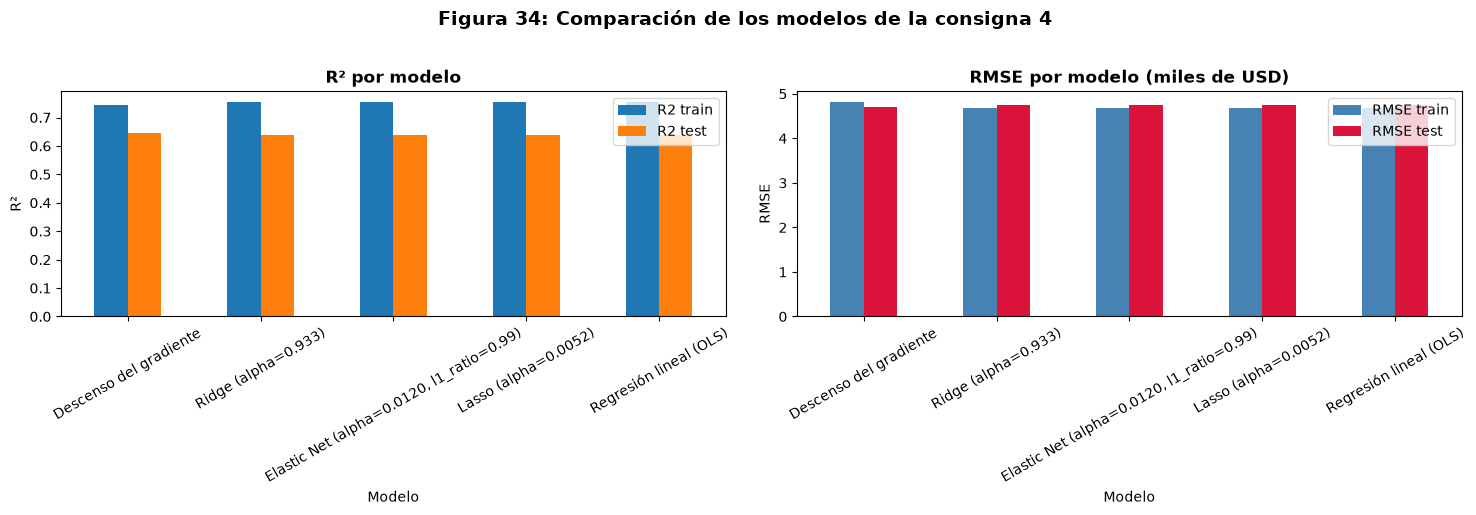

In [1296]:
tabla_modelos = pd.DataFrame(resultados_modelos).set_index('Modelo').sort_values('RMSE test')
display(tabla_modelos.round(4))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
tabla_modelos[['R2 train', 'R2 test']].plot.bar(ax=axes[0])
axes[0].set_title('R² por modelo', fontweight='bold')
axes[0].set_ylabel('R²')
axes[0].tick_params(axis='x', rotation=30)

tabla_modelos[['RMSE train', 'RMSE test']].plot.bar(ax=axes[1], color=['steelblue', 'crimson'])
axes[1].set_title('RMSE por modelo (miles de USD)', fontweight='bold')
axes[1].set_ylabel('RMSE')
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle(f'Figura {N_FIG}: Comparación de los modelos de la consigna 4',
             fontsize=14, fontweight='bold', y=1.02)
N_FIG += 1
plt.tight_layout()
plt.show()

### ¿Conseguimos un buen ajuste?

**Todos los modelos dan prácticamente lo mismo.** El RMSE de test se mueve en un rango muy angosto y el $R^2$ de test ronda 0,64 en todos. Que cinco métodos distintos lleguen al mismo resultado indica que el límite no está en el algoritmo de optimización ni en la regularización, sino en el modelo lineal en sí.

**No hay sobreajuste.** El $R^2$ de train (≈ 0,75) y el de test (≈ 0,64) son parecidos, y en las curvas de la sección 15 el error de validación nunca empieza a subir. El modelo no memoriza los datos de entrenamiento. Por eso la regularización aporta tan poco al ataca un problema que no tenemos.

**Sí hay margen de mejora en el ajuste.** El modelo explica alrededor de dos tercios de la variabilidad del precio y se equivoca, en promedio, unos 4,7 mil dólares sobre un precio medio de 22 mil. Parte de lo que falta tiene explicación:

- La **censura de `MEDV`** (sección 3.5) hace que las viviendas más caras sean imposibles de predecir bien: su precio real fue truncado en 50. En el análisis de residuos de la sección 14 el modelo las subestima sistemáticamente.
- Algunas relaciones **no son lineales**. En el gráfico de `LSTAT` contra `MEDV` de la sección 8 la nube tiene forma curva, y un modelo lineal no puede capturar esa curvatura.

Es decir, el modelo está limitado más por el **sesgo** (es demasiado simple para la relación real) que por la **varianza** (no sobreajusta).

---

## 18. Optimización de hiperparámetros

En esta sección reunimos y ampliamos la exploración de hiperparámetros de los dos grupos de modelos: el gradiente descendente y los métodos regularizados.

### 18.1 Gradiente descendente: tasa de aprendizaje

La variación de la tasa de aprendizaje está analizada en la sección 15.3. El resumen de lo observado:

| `lr` | Comportamiento |
|---|---|
| 0,001 | Converge, pero demasiado lento: 200 épocas no alcanzan |
| 0,01 | Converge bien, le faltan épocas para estabilizarse |
| 0,03 | Converge rápido y se aplana cerca del error de mínimos cuadrados |
| 0,05 | **Diverge**: el error crece sin control |

La sección 15.6 agrega un resultado relacionado: con la transformación logarítmica de `CRIM` y `B`, que comprime las colas, el algoritmo converge incluso con `lr = 0.3`. 

### 18.2 Gradiente descendente: tamaño de lote

El `batch_size` del mini-batch regula el equilibrio entre la cantidad de actualizaciones por época y el ruido de cada gradiente. Sus dos extremos son los otros dos métodos: con `batch_size` = 1 es descenso estocástico y con `batch_size` = $n$ es descenso del gradiente clásico.

In [1297]:
# Silenciamos los gráficos de las funciones de la cátedra para armar la tabla
mostrar_original = plt.show
plt.show = lambda *args, **kwargs: None

n_train_gd = X_gd_train_scaled.shape[0]
tamanos_lote = [1, 5, 11, 32, 64, 128, n_train_gd]
tasas_lote = [0.005, 0.01, 0.03]

filas_lote = []
for bs in tamanos_lote:
    fila = {'batch_size': bs, 'actualizaciones por época': int(np.ceil(n_train_gd / bs))}
    for lr in tasas_lote:
        np.random.seed(RANDOM_STATE)
        W = mini_batch_gradient_descent(X_gd_train_scaled, y_gd_train_np,
                                        X_gd_val_scaled, y_gd_val_np,
                                        lr=lr, epochs=50, batch_size=bs)
        mse = float(np.mean((y_gd_val_np - predecir_con_pesos(X_gd_val_scaled, W)) ** 2))
        fila[f'lr={lr}'] = mse if np.isfinite(mse) and mse < 1e6 else np.inf
    filas_lote.append(fila)

plt.show = mostrar_original
plt.close('all')

print('MSE de validación tras 50 épocas (inf = el método divergió):')
pd.DataFrame(filas_lote).set_index('batch_size').round(2)

MSE de validación tras 50 épocas (inf = el método divergió):


,actualizaciones por época,lr=0.005,lr=0.01,lr=0.03
batch_size,,,,
1,356,inf,inf,inf
5,72,12.94,13.50,inf
11,33,13.97,12.93,980.99
32,12,20.18,15.32,14.00
64,6,34.34,20.17,14.09
128,3,72.77,34.27,16.83
356,1,175.22,100.35,31.55


**Observaciones.**

- **Lotes chicos:** muchas actualizaciones por época, así que el algoritmo avanza más rápido, pero cada gradiente se calcula con poca información y es ruidoso, de modo que tolera tasas de aprendizaje menores. Con `batch_size` = 1 (descenso estocástico puro) diverge con todas las tasas de la tabla.
- **Lotes grandes:** el gradiente es un promedio estable y admite tasas mayores, pero hay pocas actualizaciones por época y el avance por época es menor.
- El valor por defecto de la cátedra, `batch_size` = 11, funciona bien con `lr = 0.01`. Llegamos a la conclusión que un lote de 32 es algo más robusto: converge con cualquiera de las tres tasas probadas.

### 18.3 Regularización: parámetro $\alpha$

Para Ridge, Lasso y Elastic Net no hicimos una búsqueda manual, sino que usamos las versiones con validación cruzada (`RidgeCV`, `LassoCV`, `ElasticNetCV`), que recorren una grilla de 200 valores de $\alpha$ en escala logarítmica y eligen el mejor **sin usar el conjunto de test**. Los gráficos de la sección 16 muestran el efecto de ese hiperparámetro:

- **Coeficientes en función de $\alpha$:** a medida que la penalización crece, todos los coeficientes se contraen hacia cero. En Ridge se ve cómo las curvas de `RAD` y `TAX`, que son colineales, se acercan entre sí antes de achicarse.
- **Cantidad de features incluidas en función de $\alpha$ (Lasso):** el número de coeficientes distintos de cero baja escalonadamente hasta que no queda ninguno. Es el mecanismo de selección de variables.
- **Error de validación cruzada en función de $\alpha$:** define el valor óptimo.

In [1298]:
# Valores óptimos encontrados por validación cruzada
alpha_ridge = modelo_ridge.steps[1][1].alpha_
alpha_lasso = modelo_lasso.steps[1][1].alpha_
alpha_elastic = modelo_elastic.steps[1][1].alpha_
l1_elastic = modelo_elastic.steps[1][1].l1_ratio_

resumen_hiper = pd.DataFrame([
    {'Modelo': 'Ridge', 'Hiperparámetro': 'alpha', 'Valor óptimo': round(alpha_ridge, 4),
     'Método de búsqueda': 'RidgeCV, 200 valores'},
    {'Modelo': 'Lasso', 'Hiperparámetro': 'alpha', 'Valor óptimo': round(alpha_lasso, 4),
     'Método de búsqueda': 'LassoCV, 200 valores, 5 pliegues'},
    {'Modelo': 'Elastic Net', 'Hiperparámetro': 'alpha', 'Valor óptimo': round(alpha_elastic, 4),
     'Método de búsqueda': 'ElasticNetCV, 200 valores, 10 pliegues'},
    {'Modelo': 'Elastic Net', 'Hiperparámetro': 'l1_ratio', 'Valor óptimo': l1_elastic,
     'Método de búsqueda': 'ElasticNetCV, 6 valores'},
    {'Modelo': 'Gradiente descendente', 'Hiperparámetro': 'lr', 'Valor óptimo': 0.03,
     'Método de búsqueda': 'Curvas de error vs. épocas (sección 15.3)'},
    {'Modelo': 'Mini-batch', 'Hiperparámetro': 'batch_size', 'Valor óptimo': 32,
     'Método de búsqueda': 'Tabla de la sección 18.2'},
])
display(resumen_hiper)

,Modelo,Hiperparámetro,Valor óptimo,Método de búsqueda
0,Ridge,alpha,0.9329,"RidgeCV, 200 valores"
1,Lasso,alpha,0.0052,"LassoCV, 200 valores, 5 pliegues"
2,Elastic Net,alpha,0.0120,"ElasticNetCV, 200 valores, 10 pliegues"
3,Elastic Net,l1_ratio,0.9900,"ElasticNetCV, 6 valores"
4,Gradiente descendente,lr,0.0300,Curvas de error vs. épocas (sección 15.3)
5,Mini-batch,batch_size,32.0000,Tabla de la sección 18.2


**Qué observamos al variar $\alpha$.** Los valores óptimos son muy chicos en Lasso y Elastic Net: la validación cruzada decide casi no regularizar. Es coherente con lo que vimos en la sección 17: el modelo no sobreajusta, y la regularización combate el sobreajuste. Cuando no hay varianza excesiva que controlar, penalizar sólo agrega sesgo, y la validación cruzada lo detecta.

Ridge elige un $\alpha$ mayor porque su penalización actúa de otra forma: no elimina variables sino que reparte el efecto entre las correlacionadas, y eso sí le aporta algo en un dataset con la colinealidad `RAD`–`TAX`.

---

## 19. Comparación final y elección del modelo

### 19.1 Métrica de comparación

Comparamos los modelos con el RMSE, por tres razones:

1. Está expresado en las unidades del problema (miles de dólares), así que el número es interpretable directamente.
2. Penaliza más los errores grandes que el MAE, algo deseable cuando equivocarse mucho en una vivienda es peor que equivocarse poco en varias.
3. Es equivalente a elegir por $R^2$ cuando se compara sobre el mismo conjunto, pero sin depender de la varianza del target.

### 19.2 Sobre qué conjunto comparar

Elegir el mejor modelo mirando el conjunto de test tiene un problema: el test pasa a formar parte de la decisión y deja de ser una estimación honesta del error de generalización. Además, con 99 registros, la diferencia entre dos modelos puede deberse a qué viviendas quedaron en esa partición.

Por eso comparamos con validación cruzada de 5 pliegues sobre el conjunto de entrenamiento, y recién después miramos el test para confirmar el resultado del modelo elegido.

In [1299]:
candidatos = {
    'Regresión lineal (OLS)': make_pipeline(RobustScaler(), LinearRegression()),
    f'Ridge (alpha={alpha_ridge:.3f})': make_pipeline(RobustScaler(), Ridge(alpha=alpha_ridge)),
    f'Lasso (alpha={alpha_lasso:.4f})': make_pipeline(RobustScaler(), Lasso(alpha=alpha_lasso)),
    f'Elastic Net (alpha={alpha_elastic:.4f}, l1_ratio={l1_elastic})':
        make_pipeline(RobustScaler(), ElasticNet(alpha=alpha_elastic, l1_ratio=l1_elastic)),
}

particiones = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
comparacion_final = []

for nombre, modelo in candidatos.items():
    rmse_cv = -cross_val_score(modelo, X_train, y_train, cv=particiones,
                               scoring='neg_root_mean_squared_error')
    modelo.fit(X_train, y_train)
    prediccion = modelo.predict(X_test)
    comparacion_final.append({
        'Modelo': nombre,
        'RMSE validación cruzada': rmse_cv.mean(),
        'Desvío CV': rmse_cv.std(),
        'RMSE test': np.sqrt(mean_squared_error(y_test, prediccion)),
        'R2 test': r2_score(y_test, prediccion),
    })

tabla_final = pd.DataFrame(comparacion_final).set_index('Modelo').sort_values('RMSE validación cruzada')
display(tabla_final.round(4))

,RMSE validación cruzada,Desvío CV,RMSE test,R2 test
Modelo,,,,
Ridge (alpha=0.933),4.8645,0.7852,4.7425,0.6391
"Elastic Net (alpha=0.0120, l1_ratio=0.99)",4.8645,0.7876,4.7433,0.6390
Lasso (alpha=0.0052),4.8691,0.7822,4.7477,0.6383
Regresión lineal (OLS),4.8740,0.7782,4.7521,0.6377


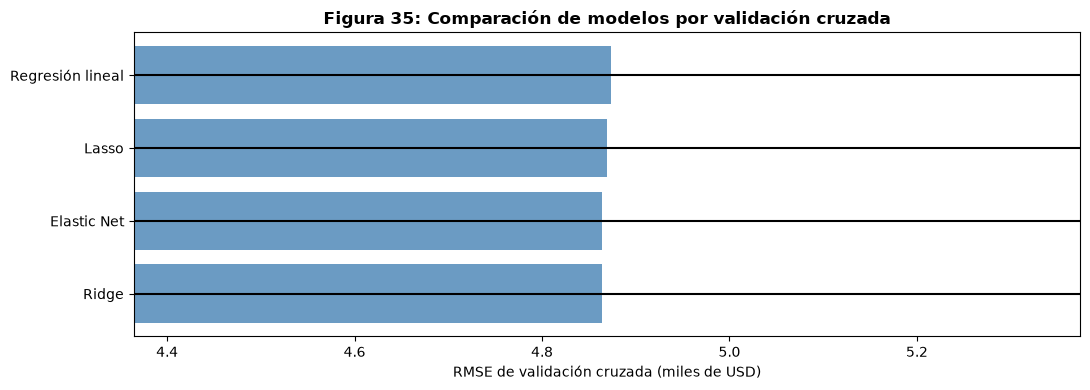

In [1300]:
fig, ax = plt.subplots(figsize=(11, 4))
posiciones = np.arange(len(tabla_final))
ax.barh(posiciones, tabla_final['RMSE validación cruzada'],
        xerr=tabla_final['Desvío CV'], color='steelblue', alpha=0.8, capsize=4)
ax.set_yticks(posiciones, [n.split(' (')[0] for n in tabla_final.index])
ax.set_xlabel('RMSE de validación cruzada (miles de USD)')
ax.set_xlim(tabla_final['RMSE validación cruzada'].min() - 0.5,
            tabla_final['RMSE validación cruzada'].max() + 0.5)
ax.set_title(f'Figura {N_FIG}: Comparación de modelos por validación cruzada', fontweight='bold')
N_FIG += 1
plt.tight_layout()
plt.show()

### 19.3 Elección del modelo final

Las diferencias entre los cuatro modelos son menores que el desvío de la validación cruzada, es decir, están dentro del margen de error de la medición. No hay un ganador estadísticamente distinguible.

Complementado por lo que cada uno aporta:

- **Ridge** obtiene el menor RMSE de validación cruzada, empatado con Elastic Net, y es el único que resuelve un problema concreto del dataset: la colinealidad entre `RAD` y `TAX` ($r = 0{,}91$). Sin regularización, esos dos coeficientes son grandes, de signos opuestos e inestables entre particiones; Ridge los contrae y los vuelve interpretables.
- **Lasso** y **Elastic Net** eligen por validación cruzada un $\alpha$ tan chico que se comportan casi como la regresión sin regularizar, por lo que no aportan nada distinto.
- El **gradiente descendente** llega a la misma solución que mínimos cuadrados, así que no es un modelo distinto sino otra forma de estimar los mismos coeficientes.

**Modelo elegido: Ridge.** Iguala al mejor en capacidad predictiva y produce coeficientes más estables, que es lo que permite interpretar el modelo además de usarlo para predecir.

In [1301]:
# Modelo final: se entrena con todo el conjunto de entrenamiento y se evalúa una única vez en test
modelo_final = make_pipeline(RobustScaler(), Ridge(alpha=alpha_ridge))
modelo_final.fit(X_train, y_train)

pred_train = modelo_final.predict(X_train)
pred_test = modelo_final.predict(X_test)

print('Modelo final: Ridge')
print('=' * 55)
print(f'  R2   train: {r2_score(y_train, pred_train):.4f}  | test: {r2_score(y_test, pred_test):.4f}')
print(f'  RMSE train: {np.sqrt(mean_squared_error(y_train, pred_train)):.4f} | '
      f'test: {np.sqrt(mean_squared_error(y_test, pred_test)):.4f}')
print(f'  MAE  train: {mean_absolute_error(y_train, pred_train):.4f} | '
      f'test: {mean_absolute_error(y_test, pred_test):.4f}')

coef_final = pd.Series(modelo_final.steps[1][1].coef_, index=X_train.columns)
print()
print('Coeficientes del modelo final, ordenados por magnitud:')
print(coef_final.sort_values(key=abs, ascending=False).round(3).to_string())

Modelo final: Ridge
  R2   train: 0.7553  | test: 0.6391
  RMSE train: 4.6784 | test: 4.7425
  MAE  train: 3.3144 | test: 3.2399

Coeficientes del modelo final, ordenados por magnitud:
RAD        5.519
LSTAT     -5.282
DIS       -4.784
TAX       -4.190
PTRATIO   -3.196
NOX       -3.106
RM         3.043
CHAS       2.061
ZN         0.578
CRIM      -0.319
AGE       -0.267
B          0.173
INDUS      0.048


---

## 20. Conclusiones

### Sobre los datos

El dataset entregado contenía 556 registros, de los cuales 506 estaban completos y 50 tenían valores faltantes. El trabajo con esos 50 registros ocupó buena parte del análisis y se resolvió en tres pasos:

1. **Criterios de calidad estándar:** se eliminaron los registros sin variable objetivo y aquellos con la mitad o más de sus features faltantes (28 registros en total).
2. **Imputación:** los 22 registros restantes se imputaron distinguiendo el tipo de variable, con KNN para las numéricas y CatBoost para `CHAS` y `RAD`, tratadas como categóricas. La evaluación con faltantes artificiales mostró que KNN reduce el error de imputación aproximadamente un 40% respecto de imputar por la mediana.
3. **Control de coherencia:** al validar el resultado contra patrones estructurales derivados del conjunto de entrenamiento (y verificados en el de prueba), los 22 registros imputados resultaron incompatibles con la estructura del dataset: combinaciones de criminalidad, zonificación y accesibilidad que no existen en ningún registro completo, más valores registrados con una precisión ajena al resto del archivo, se decidió descartarlos.

El dataset final quedó con 506 registros completos y coherentes. La conclusión metodológica es que imputar no repara datos inválidos: sirve para completar observaciones legítimas a las que les falta información, no para rescatar registros cuyos valores presentes ya son contradictorios.

### Sobre el problema

- Las variables más relacionadas con el precio son `LSTAT` (−0,75) y `RM` (+0,71): el nivel socioeconómico de la zona y el tamaño de la vivienda.
- `RAD` y `TAX` son colineales ($r = 0{,}91$), lo que vuelve inestables los coeficientes de la regresión sin regularizar. Es el motivo por el que el coeficiente de `RAD` aparece con signo positivo pese a que su correlación con el precio es negativa.
- `MEDV` está censurada en 50: las viviendas de USD 50.000 o más se registraron todas con ese valor. El modelo las subestima sistemáticamente, y eso es un límite del dato, no del método.

### Sobre los modelos

- La regresión lineal múltiple alcanza un $R^2$ de test cercano a 0,64, con un error típico de unos 4,7 mil dólares sobre un precio medio de 22 mil.
- El gradiente descendente converge a la misma solución que mínimos cuadrados. Su comportamiento depende críticamente del preprocesamiento y de la tasa de aprendizaje: con las variables escaladas converge con `lr = 0.03` y diverge con `lr = 0.05`; el descenso estocástico, que actualiza con una muestra por vez, sólo es estable con tasas mucho menores.
- La regularización aporta poco en capacidad predictiva, porque el modelo no sobreajusta: el $R^2$ de train y el de test son parecidos, y la validación cruzada elige valores de $\alpha$ casi nulos para Lasso y Elastic Net. Sí aporta estabilidad: Ridge, el modelo elegido, contrae los coeficientes del par colineal y los vuelve interpretables.
- Las diferencias entre los cuatro modelos son menores que el desvío de la validación cruzada. El límite no está en el algoritmo sino en la forma funcional: una relación lineal no captura la curvatura visible entre `LSTAT` y `MEDV`.

### Limitaciones y posibles mejoras

- **Censura del target.** Un tratamiento riguroso requeriría modelos de regresión censurada (tipo Tobit), fuera del alcance de la materia.
- **No linealidad.** Incorporar términos polinómicos o transformaciones del target podría capturar la curvatura de `LSTAT`, a costa de perder interpretabilidad.
- **Tamaño del dataset.** Con 506 registros, la métrica de test tiene una variabilidad considerable, razón por la cual usamos validación cruzada para decidir.

